# Medical Question Answering on PubMedQA: Analysing Text Representations and Classifier Design

**Group title:** Group 16 — Medical Question Answering on PubMedQA  
**Module:** EMATM0067 — Introduction to AI and Text Analytics  
**University:** University of Bristol

| Group member | Email |
|---|---|
| Tanishk Nanasaheb Shinde | ac25643@bristol.ac.uk |
| Abdullah Alahmari | dl25357@bristol.ac.uk |
| Peidong Wang | hz25950@bristol.ac.uk |
| Zhengjie Xue | jw25233@bristol.ac.uk |
| Abhigyan Kashyap | wm25342@bristol.ac.uk |

## Notebook overview 

This notebook is our complete implementation for the PubMedQA group task. The task is to classify biomedical research questions into **yes**, **no**, or **maybe** by using the question, the PubMed abstract context, and, in some experiments, the long answer field. We keep the notebook aligned with the final report by using the same two main experiment axes:

**Axis 1 — Text representation.** We compare how far the model improves when we change the input and representation: question only, question plus context, question plus context plus long answer, TF-IDF, BioBERT embeddings, BioBERT fine-tuning, and PubMedBERT fine-tuning.

**Axis 2 — Classifier and training design.** We compare classical models, calibrated classifiers, SMOTE, soft voting, transformer tuning, LoRA, zero-shot BART-MNLI, focal loss, threshold tuning, ordinal loss, and a hierarchical classifier.

The key result from the notebook is that sparse TF-IDF models stay close to the same performance band, even when the input text is changed. The major improvement comes when we fine-tune biomedical transformer models, especially **PubMedBERT on Q+Ctx+Ans**, which becomes the best overall model. At the same time, the **maybe** class remains the hardest label. Focal loss improves maybe recovery, but it does not beat the best PubMedBERT model on overall macro-F1. This is why the notebook does not only report one score; it also studies per-class F1, confusion matrices, McNemar testing, shared error cases, clustering, and a quality predictor.


## Section 1 — Imports and global setup


In [ ]:
import os
import re
import json
import math
import random
import warnings
from collections import Counter, defaultdict
from functools import reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import hstack
from scipy.special import softmax as sp_softmax
from scipy.stats import chi2

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    roc_auc_score
)
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_score,
    learning_curve
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.svm import LinearSVC, SVC

try:
    import torch
    from transformers import (
        AutoTokenizer,
        AutoModel,
        AutoModelForSequenceClassification
    )
    TRANSFORMERS_AVAILABLE = True
except Exception:
    TRANSFORMERS_AVAILABLE = False

try:
    from sentence_transformers import SentenceTransformer
    SBERT_OK = True
except Exception:
    SBERT_OK = False

TRANSFORMERS_OK = TRANSFORMERS_AVAILABLE

warnings.filterwarnings("default")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

if TRANSFORMERS_AVAILABLE:
    torch.manual_seed(RANDOM_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(RANDOM_SEED)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

print("All main libraries imported successfully.")
print(f"Random seed set to {RANDOM_SEED}")
print(f"Transformers available: {TRANSFORMERS_AVAILABLE}")
print(f"SentenceTransformers available: {SBERT_OK}")

All main libraries imported successfully.
Random seed set to 42
Transformers available: True
SentenceTransformers available: True


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


This first block prepares the full environment used later in the notebook. The output confirms that the main libraries load correctly, the random seed is fixed at **42**, and both transformer-related packages are available. That matters because our notebook combines two types of experiments: classical machine-learning models that run quickly on TF-IDF features, and transformer experiments that need the HuggingFace stack and GPU support.

We also keep the seed fixed from the beginning because the later 500/500 split, 10-fold CV setup, and transformer validation fold should be reproducible. Without a consistent seed, small changes in the split could change the number of **maybe** examples in each fold, which would make the comparison less fair.


## Section 2 — Data loading


In [ ]:
from pathlib import Path

candidate_paths = [
    Path("/content/data/ori_pqal.json"),
    Path("data/ori_pqal.json"),
    Path("./data/ori_pqal.json"),
    Path("/mnt/data/ori_pqal.json")
]

DATA_PATH = next((str(p) for p in candidate_paths if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find ori_pqal.json. Checked: /content/data, ./data, and /mnt/data"
    )

print(f"Using data file: {DATA_PATH}")

with open(DATA_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

print(f"Total records: {len(data)}")

first_key = list(data.keys())[0]
print(f"\nExample PMID: {first_key}")
print(json.dumps(data[first_key], indent=2)[:800])

rows = []
for pmid, info in data.items():
    contexts = info.get("CONTEXTS", [])
    rows.append({
        "pmid": pmid,
        "question": info.get("QUESTION", ""),
        "context_list": contexts,
        "context": " ".join(contexts) if isinstance(contexts, list) else str(contexts),
        "long_answer": info.get("LONG_ANSWER", ""),
        "label": str(info.get("final_decision", "")).lower().strip()
    })

df = pd.DataFrame(rows)
print(f"\nDataFrame shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")

print("\nLabel distribution:")
print(df["label"].value_counts())

df["question_len"] = df["question"].str.split().str.len()
df["context_len"] = df["context"].str.split().str.len()
df["long_answer_len"] = df["long_answer"].str.split().str.len()
df["num_contexts"] = df["context_list"].apply(lambda x: len(x) if isinstance(x, list) else 0)

Using data file: /content/data/ori_pqal.json
Total records: 1000

Example PMID: 21645374
{
  "QUESTION": "Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?",
  "CONTEXTS": [
    "Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the center of these areoles and progresses outwards, stopping approximately five cells from the vasculature. The role of mitochondria during PCD has been recognized in animals; however, it has been less studied during PCD in plants.",
    "The following paper elucidates the role of mitochondrial dynamics during developmentally regulated PCD in vivo in A. madaga

DataFrame shape: (1000, 6)
Columns: ['pmid', 'question', 'context_list', 'context', 'long_answer', 'label']



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


The dataset loads correctly from `ori_pqal.json`, and the notebook confirms that there are **1,000 records**. The dataframe contains the expected fields: PMID, question, context list, merged context, long answer, and label. There are no missing values, so we do not need to remove or impute examples before modelling.

The label distribution already shows the main difficulty of the project: **552 yes**, **338 no**, and only **110 maybe** examples. This means the maybe class is only 11% of the dataset. From this point onward, accuracy alone would be misleading because a model can look acceptable by mostly predicting the majority label. That is why the notebook later uses macro-F1 and per-class F1 as the main evidence.


## Section 3 — Exploratory data analysis


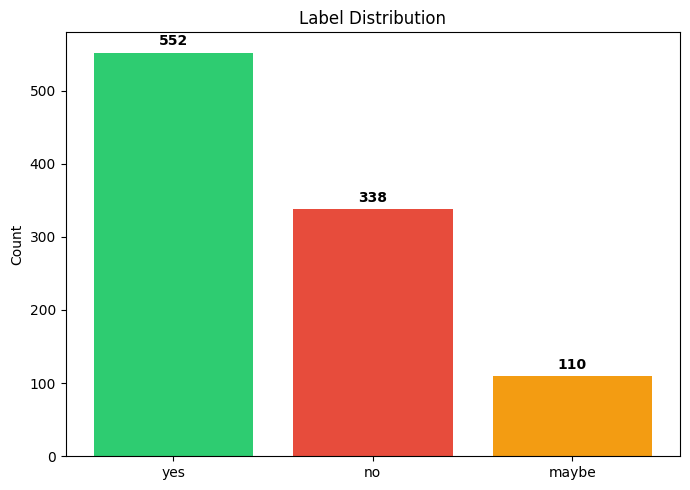

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


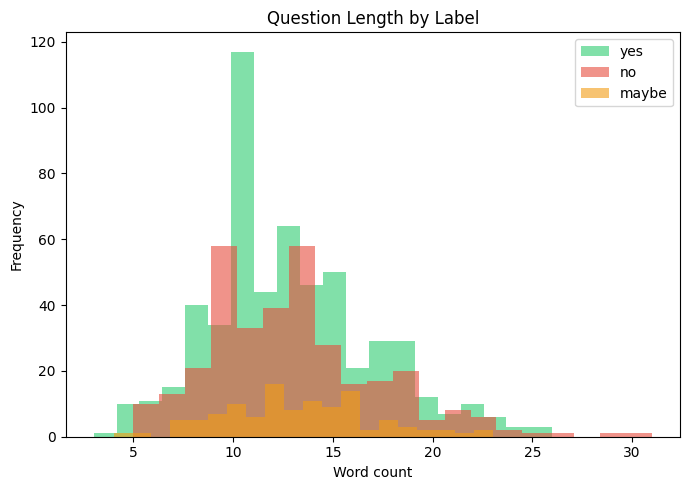

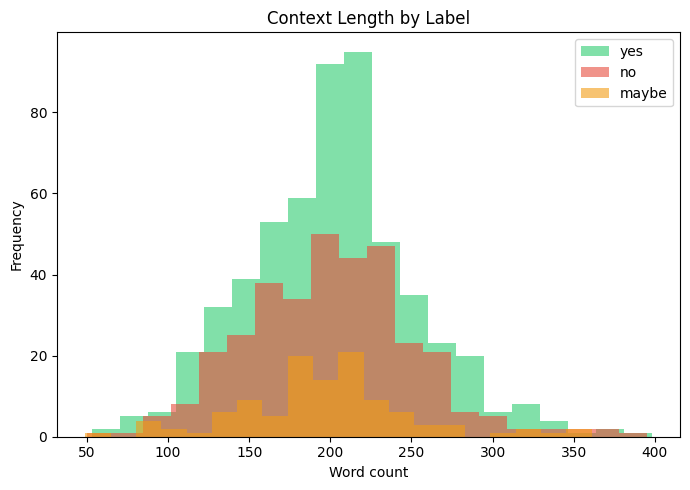

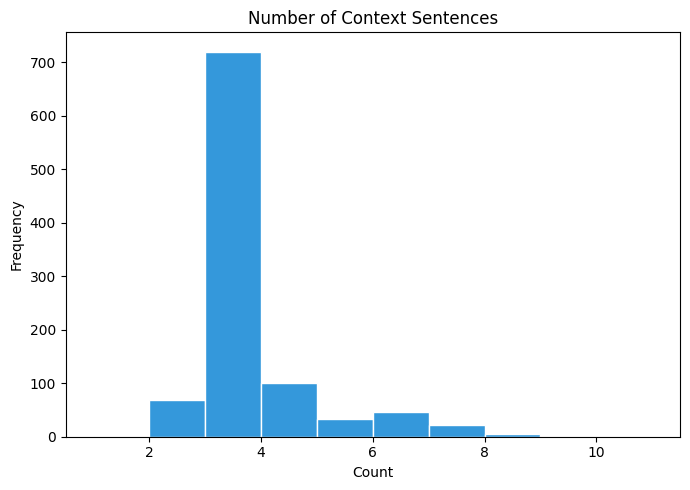

/tmp/ipykernel_8114/437076704.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:

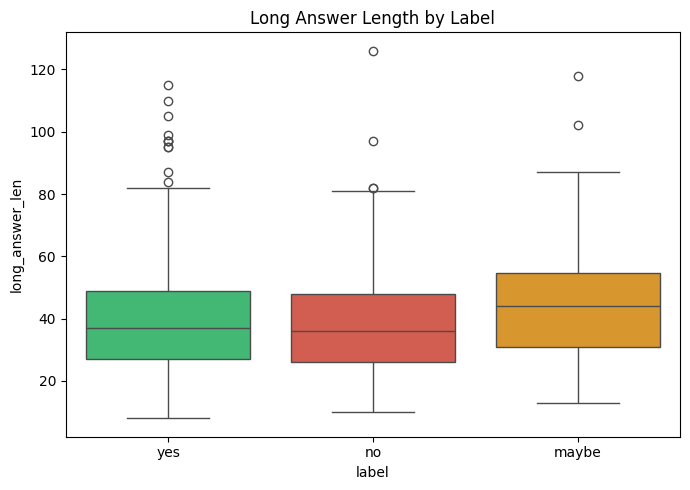

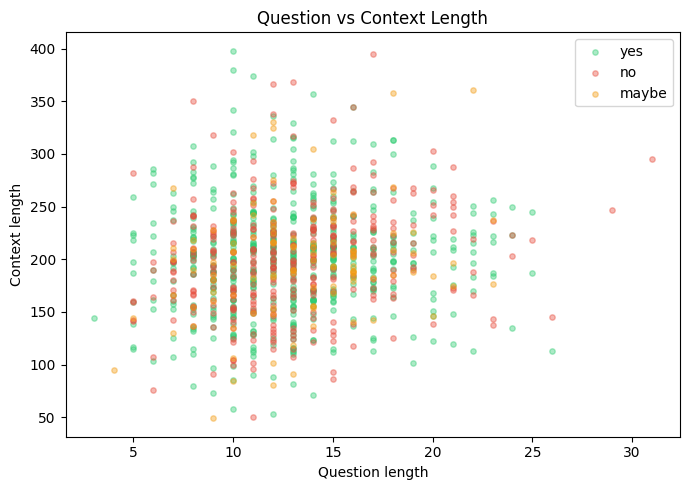


Descriptive statistics:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,question_len,context_len,long_answer_len,num_contexts
count,1000.0,1000.0,1000.0,1000.0
mean,12.9,200.2,39.7,3.4
std,4.1,51.8,17.2,1.1
min,3.0,49.0,8.0,1.0
25%,10.0,166.8,27.0,3.0
50%,13.0,200.5,37.0,3.0
75%,15.0,228.0,49.0,3.0
max,31.0,398.0,126.0,9.0


In [ ]:
save_dir = "visualizations"
os.makedirs(save_dir, exist_ok=True)

colors = {"yes": "#2ecc71", "no": "#e74c3c", "maybe": "#f39c12"}

plt.figure(figsize=(7, 5))
label_counts = df["label"].value_counts()
plt.bar(label_counts.index, label_counts.values,
        color=[colors.get(lab, "#3498db") for lab in label_counts.index])
plt.title("Label Distribution")
plt.ylabel("Count")
for i, (lab, cnt) in enumerate(zip(label_counts.index, label_counts.values)):
    plt.text(i, cnt + 10, str(cnt), ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_1_label_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5))
for lab in ["yes", "no", "maybe"]:
    subset = df[df["label"] == lab]["question_len"]
    plt.hist(subset, bins=20, alpha=0.6, label=lab, color=colors[lab])
plt.title("Question Length by Label")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_2_question_length_by_label.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5))
for lab in ["yes", "no", "maybe"]:
    subset = df[df["label"] == lab]["context_len"]
    plt.hist(subset, bins=20, alpha=0.6, label=lab, color=colors[lab])
plt.title("Context Length by Label")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_3_context_length_by_label.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5))
plt.hist(df["num_contexts"], bins=range(1, 12), color="#3498db", edgecolor="white")
plt.title("Number of Context Sentences")
plt.xlabel("Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_4_num_context_sentences.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df,
    x="label",
    y="long_answer_len",
    order=["yes", "no", "maybe"],
    palette=[colors["yes"], colors["no"], colors["maybe"]]
)
plt.title("Long Answer Length by Label")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_5_long_answer_length_by_label.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5))
for lab in ["yes", "no", "maybe"]:
    subset = df[df["label"] == lab]
    plt.scatter(
        subset["question_len"], subset["context_len"],
        alpha=0.4, label=lab, color=colors[lab], s=15
    )
plt.title("Question vs Context Length")
plt.xlabel("Question length")
plt.ylabel("Context length")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_6_question_vs_context_length.png"), dpi=300, bbox_inches="tight")
plt.show()

print("\nDescriptive statistics:")
display(df[["question_len", "context_len", "long_answer_len", "num_contexts"]].describe().round(1))



The exploratory plots and descriptive statistics give the first picture of why PubMedQA is not a simple text-classification task. The average question is short, around **12.9 words**, while the average context is much longer, around **200.2 words**. The long answer is shorter than the context, with a mean length of about **39.7 words**.

This imbalance between short questions and long biomedical contexts helps explain why sparse bag-of-words models struggle later. Important answer cues can be buried inside long technical paragraphs, and the minority maybe label does not separate cleanly from yes/no using simple length patterns. The EDA therefore supports the report argument that surface features alone are weak and that evidence sufficiency is the real bottleneck.


## Section 4 — Text preprocessing and feature engineering


In [ ]:
df_model = df.copy()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^\w\s\-\?\.,:;/%()]", " ", text)
    return text.strip()

df_model["question_clean"] = df_model["question"].apply(clean_text)
df_model["context_clean"] = df_model["context"].apply(clean_text)
df_model["long_answer_clean"] = df_model["long_answer"].apply(clean_text)

print(f"Text cleaning complete. Columns: {[c for c in df_model.columns if 'clean' in c]}")

df_model["text_q_only"] = "question: " + df_model["question_clean"]
df_model["text_q_ctx"] = (
    "question: " + df_model["question_clean"]
    + " context: " + df_model["context_clean"]
)
df_model["text_q_ctx_ans"] = (
    "question: " + df_model["question_clean"]
    + " context: " + df_model["context_clean"]
    + " answer: " + df_model["long_answer_clean"]
)

label2id = {"no": 0, "maybe": 1, "yes": 2}
id2label = {0: "no", 1: "maybe", 2: "yes"}
df_model["label_id"] = df_model["label"].map(label2id)
df_model["question_len"] = df_model["question_clean"].apply(lambda x: len(x.split()))
df_model["context_len"] = df_model["context_clean"].apply(lambda x: len(x.split()))
df_model["long_answer_len"] = df_model["long_answer_clean"].apply(lambda x: len(x.split()))
df_model["num_contexts"] = df_model["context_list"].apply(lambda x: len(x) if isinstance(x, list) else 0)

assert df_model["label_id"].isna().sum() == 0, "Unmapped labels found!"

print(f"Input variants created. Shape: {df_model.shape}")
print(f"Label distribution: {df_model['label_id'].value_counts().sort_index().to_dict()}")

df_model["has_negation"] = df_model["question_clean"].apply(
    lambda x: int(any(w in x.split() for w in ["no", "not", "without", "lack", "absence"]))
)
df_model["has_causal"] = df_model["question_clean"].apply(
    lambda x: int(any(w in x for w in ["cause", "effect", "impact", "influence", "affect", "lead to"]))
)
df_model["has_comparison"] = df_model["question_clean"].apply(
    lambda x: int(any(w in x for w in ["compar", "differ", "versus", "vs", "better", "worse"]))
)
df_model["has_association"] = df_model["question_clean"].apply(
    lambda x: int(any(w in x for w in ["associat", "correlat", "relat", "link"]))
)
df_model["has_risk"] = df_model["question_clean"].apply(
    lambda x: int("risk" in x)
)
df_model["context_evidence_strength"] = df_model["context_clean"].apply(
    lambda x: int(any(w in x for w in ["significant", "strongly", "clearly", "demonstrated"]))
)
df_model["context_hedging"] = df_model["context_clean"].apply(
    lambda x: int(any(w in x for w in ["may", "might", "suggest", "possibly", "further study", "inconclusive"]))
)

print("Preprocessing complete")
print(f"Shape: {df_model.shape}")
print(f"Label distribution:\n{df_model['label_id'].value_counts().sort_index()}")
print(f"\nSample cleaned text (first row):")
print(df_model["text_q_ctx"].iloc[0][:200])



Text cleaning complete. Columns: ['question_clean', 'context_clean', 'long_answer_clean']
Input variants created. Shape: (1000, 17)
Label distribution: {0: 338, 1: 110, 2: 552}
Preprocessing complete
Shape: (1000, 24)
Label distribution:
label_id
0    338
1    110
2    552
Name: count, dtype: int64

Sample cleaned text (first row):
question: do mitochondria play a role in remodelling lace plant leaves during programmed cell death? context: programmed cell death (pcd) is the regulated death of cells within an organism. the lace p


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Here we create the cleaned text columns and the three input forms used throughout the notebook: **Q**, **Q+Ctx**, and **Q+Ctx+Ans**. The output confirms that the cleaned columns are created successfully and that the label encoding is consistent: **no = 0**, **maybe = 1**, and **yes = 2**.

The extra handcrafted features, such as text length, hedging, evidence strength, negation, causal wording, and risk indicators, are useful for later analysis. We do not treat them as the main solution. Instead, they help us test whether simple surface signals can explain why the baseline is correct or wrong. This keeps the feature-engineering part connected to the later quality-predictor section.


## Section 5 — Data splits


In [ ]:
from sklearn.model_selection import StratifiedKFold

random.seed(RANDOM_SEED)

def split_dataset(dataset_pmids, labels, fold):
    add = lambda x: reduce(lambda a, b: a + b, x)

    label2pmids = defaultdict(list)
    for pmid, lab in zip(dataset_pmids, labels):
        label2pmids[lab].append(pmid)

    label2splits = {}
    for lab, pmids in label2pmids.items():
        pmids = pmids.copy()
        random.shuffle(pmids)
        num_all = len(pmids)
        num_split = math.ceil(num_all / fold)
        splits = []
        for i in range(fold):
            if i == fold - 1:
                splits.append(pmids[i * num_split:])
            else:
                splits.append(pmids[i * num_split: (i + 1) * num_split])
        label2splits[lab] = splits

    output = []
    for i in range(fold):
        fold_pmids = add([label2splits[lab][i] for lab in sorted(label2splits.keys())])
        output.append(fold_pmids)

    if len(output[-1]) != len(output[0]):
        for i in range(fold - 1):
            while len(output[i]) > len(output[-1]):
                picked = random.choice(output[i])
                output[-1].append(picked)
                output[i].remove(picked)

    return output


# STEP 1 — 500 / 500 split

all_pmids = df_model["pmid"].tolist()
all_labels = df_model["label"].tolist()

two_halves = split_dataset(all_pmids, all_labels, 2)
cv_pmids = set(two_halves[0])
test_pmids = set(two_halves[1])

print(f"CV set:   {len(cv_pmids)} samples")
print(f"Test set: {len(test_pmids)} samples")

cv_df = df_model[df_model["pmid"].isin(cv_pmids)].copy()
test_df = df_model[df_model["pmid"].isin(test_pmids)].copy()

print(f"\nCV label distribution:")
print(cv_df["label"].value_counts())
print(f"\nTest label distribution:")
print(test_df["label"].value_counts())

assert len(cv_df) == 500, f"CV set should be 500, got {len(cv_df)}"
assert len(test_df) == 500, f"Test set should be 500, got {len(test_df)}"
assert cv_df["pmid"].nunique() == 500, "CV PMIDs not unique"
assert test_df["pmid"].nunique() == 500, "Test PMIDs not unique"
assert set(cv_df["pmid"]).isdisjoint(set(test_df["pmid"])), "CV/Test overlap detected!"

print("500 CV / 500 test split verified correctly.")

# STEP 2 — Proper 10-fold stratified CV on the 500-sample CV set

cv_df = cv_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)

cv_df["fold"] = -1
for fold_idx, (_, val_idx) in enumerate(skf.split(cv_df, cv_df["label"])):
    cv_df.loc[val_idx, "fold"] = fold_idx

print("\n10-Fold CV split sizes:")
for i in range(10):
    fold_df = cv_df[cv_df["fold"] == i]
    dist = fold_df["label"].value_counts().to_dict()
    print(f"  Fold {i}: {len(fold_df)} samples — {dist}")

assert (cv_df["fold"] >= 0).all(), "Some CV rows do not have fold assignments!"
assert cv_df["fold"].nunique() == 10, "Expected 10 unique folds!"
assert cv_df["fold"].isna().sum() == 0, "Missing fold assignments!"

print(f"\nTotal CV samples with fold assignment: {cv_df['fold'].notna().sum()}")

# STEP 3 — Build text fields for downstream experiments

q_col = "question_clean" if "question_clean" in df_model.columns else "question"
c_col = "context_clean" if "context_clean" in df_model.columns else "context"
a_col = "long_answer_clean" if "long_answer_clean" in df_model.columns else "long_answer"

for frame in [cv_df, test_df]:
    frame["q_only"] = frame[q_col].fillna("")
    frame["q_ctx"] = (
        frame[q_col].fillna("") + " [SEP] " +
        frame[c_col].fillna("")
    )
    frame["q_ctx_ans"] = (
        frame[q_col].fillna("") + " [SEP] " +
        frame[c_col].fillna("") + " [SEP] " +
        frame[a_col].fillna("")
    )

# STEP 4 — Extract arrays for later sections

y_test = test_df["label_id"].values
pmid_test = test_df["pmid"].values

X_test_qonly = test_df["q_only"].tolist()
X_test_qctx = test_df["q_ctx"].tolist()
X_test_qctxans = test_df["q_ctx_ans"].tolist()

y_cv = cv_df["label_id"].values
X_cv_qonly = cv_df["q_only"].tolist()
X_cv_qctx = cv_df["q_ctx"].tolist()
X_cv_qctxans = cv_df["q_ctx_ans"].tolist()

print("\nTest set arrays extracted:")
print(f"  y_test shape: {y_test.shape}")
print(f"  Test label dist: {pd.Series(y_test).map(id2label).value_counts().to_dict()}")

print(f"\nCV set arrays extracted:")
print(f"  y_cv shape: {y_cv.shape}")
print(f"  CV label dist: {pd.Series(y_cv).map(id2label).value_counts().to_dict()}")

CV set:   500 samples
Test set: 500 samples

CV label distribution:
label
yes      276
no       169
maybe     55
Name: count, dtype: int64

Test label distribution:
label
yes      276
no       169
maybe     55
Name: count, dtype: int64
500 CV / 500 test split verified correctly.

10-Fold CV split sizes:
  Fold 0: 50 samples — {'yes': 28, 'no': 17, 'maybe': 5}
  Fold 1: 50 samples — {'yes': 28, 'no': 17, 'maybe': 5}
  Fold 2: 50 samples — {'yes': 28, 'no': 17, 'maybe': 5}
  Fold 3: 50 samples — {'yes': 28, 'no': 17, 'maybe': 5}
  Fold 4: 50 samples — {'yes': 28, 'no': 17, 'maybe': 5}
  Fold 5: 50 samples — {'yes': 28, 'no': 16, 'maybe': 6}
  Fold 6: 50 samples — {'yes': 27, 'no': 17, 'maybe': 6}
  Fold 7: 50 samples — {'yes': 27, 'no': 17, 'maybe': 6}
  Fold 8: 50 samples — {'yes': 27, 'no': 17, 'maybe': 6}
  Fold 9: 50 samples — {'yes': 27, 'no': 17, 'maybe': 6}

Total CV samples with fold assignment: 500

Test set arrays extracted:
  y_test shape: (500,)
  Test label dist: {'yes': 276

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


The split is correctly built as **500 CV samples** and **500 test samples**. Both halves preserve the same label distribution: **276 yes**, **169 no**, and **55 maybe**. This is important because it keeps the held-out test set directly comparable with the CV half and avoids a situation where one split has a much easier or harder label distribution.

The 10-fold CV setup also looks balanced. Each fold has around 50 samples, with roughly 27–28 yes examples, 16–17 no examples, and only 5–6 maybe examples. This makes the limitation very clear: every validation fold contains very few maybe cases, so threshold tuning and minority-class decisions are naturally unstable. This is one reason we interpret maybe-F1 carefully throughout the notebook.


## Section 6 — Evaluation helpers


In [ ]:
def evaluate_10fold_cv(make_pipeline_fn, cv_df, text_col, test_texts, y_test,
                       n_folds=10, return_fold_preds=False):
    fold_accs = []
    fold_f1s = []
    fold_preds_all = {}

    for fold_idx in range(n_folds):
        val_mask = cv_df["fold"] == fold_idx
        train_mask = ~val_mask

        X_tr = cv_df.loc[train_mask, text_col].tolist()
        y_tr = cv_df.loc[train_mask, "label_id"].values
        X_val = cv_df.loc[val_mask, text_col].tolist()
        y_val = cv_df.loc[val_mask, "label_id"].values

        pipe = make_pipeline_fn()
        pipe.fit(X_tr, y_tr)
        val_preds = pipe.predict(X_val)

        fold_accs.append(accuracy_score(y_val, val_preds))
        fold_f1s.append(f1_score(y_val, val_preds, average="macro"))

        if return_fold_preds:
            fold_preds_all[fold_idx] = (y_val, val_preds)

    final_pipe = make_pipeline_fn()
    X_cv_all = cv_df[text_col].tolist()
    y_cv_all = cv_df["label_id"].values
    final_pipe.fit(X_cv_all, y_cv_all)
    test_preds = final_pipe.predict(test_texts)

    test_acc = accuracy_score(y_test, test_preds)
    test_f1 = f1_score(y_test, test_preds, average="macro")

    result = {
        "cv_acc_mean": np.mean(fold_accs),
        "cv_acc_std": np.std(fold_accs),
        "cv_f1_mean": np.mean(fold_f1s),
        "cv_f1_std": np.std(fold_f1s),
        "test_acc": test_acc,
        "test_f1": test_f1,
        "preds": test_preds,
        "final_pipeline": final_pipe,
    }
    if return_fold_preds:
        result["fold_preds"] = fold_preds_all
    return result

print("10-fold CV evaluation helper defined.")
print("Key design: TF-IDF is fitted INSIDE each fold to prevent data leakage.")

def build_word_char_features(train_texts, other_texts, max_word=40000, max_char=30000):
    word_vec = TfidfVectorizer(
        lowercase=True, stop_words="english",
        ngram_range=(1, 2), min_df=2,
        sublinear_tf=True, max_features=max_word
    )
    char_vec = TfidfVectorizer(
        lowercase=True, analyzer="char_wb",
        ngram_range=(3, 5), min_df=2,
        sublinear_tf=True, max_features=max_char
    )
    X_train_word = word_vec.fit_transform(train_texts)
    X_train_char = char_vec.fit_transform(train_texts)
    X_train = hstack([X_train_word, X_train_char]).tocsr()

    outputs = []
    for texts in other_texts:
        X_word = word_vec.transform(texts)
        X_char = char_vec.transform(texts)
        outputs.append(hstack([X_word, X_char]).tocsr())

    return X_train, outputs, word_vec, char_vec

def maybe_threshold_predict(probs, maybe_threshold=0.40, maybe_class_id=1):
    non_maybe_best = np.where(probs[:, 0] >= probs[:, 2], 0, 2)
    preds = np.where(probs[:, maybe_class_id] >= maybe_threshold, maybe_class_id, non_maybe_best)
    return preds

def tune_maybe_threshold(val_logits, y_val, thresholds=np.arange(0.05, 0.55, 0.05)):
    val_probs = sp_softmax(val_logits, axis=1)
    best = {"threshold": 0.5, "macro_f1": -1, "maybe_f1": -1}
    for thr in thresholds:
        preds = maybe_threshold_predict(val_probs, maybe_threshold=thr, maybe_class_id=1)
        per_class = f1_score(y_val, preds, average=None, labels=[0, 1, 2], zero_division=0)
        macro = f1_score(y_val, preds, average="macro", zero_division=0)
        if macro > best["macro_f1"]:
            best = {"threshold": thr, "macro_f1": macro, "maybe_f1": per_class[1]}
    return best

print("Feature builder, threshold prediction, and threshold tuning functions defined.")



10-fold CV evaluation helper defined.
Key design: TF-IDF is fitted INSIDE each fold to prevent data leakage.
Feature builder, threshold prediction, and threshold tuning functions defined.


This section defines the shared evaluation functions used by the later experiments. The most important design choice is that TF-IDF is fitted **inside each CV fold**, not before cross-validation. That prevents leakage from the validation fold into the training representation.

The helper functions also standardise macro-F1, threshold prediction, and feature construction. This matters because the notebook compares many models; if every model used a slightly different evaluation routine, the final table would be harder to trust. By centralising the evaluation logic here, the later comparisons are cleaner and easier to check against the report.


## Section 7 — Baseline TF-IDF + Logistic Regression


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future ver

BASELINE: TF-IDF (1,2)-grams + Logistic Regression
10-Fold CV Accuracy : 0.5160 ± 0.0488
10-Fold CV Macro-F1 : 0.3432 ± 0.0525
Test Accuracy       : 0.5060
Test Macro-F1       : 0.3482

              precision    recall  f1-score   support

          no       0.40      0.33      0.36       169
       maybe       0.13      0.04      0.06        55
         yes       0.56      0.71      0.63       276

    accuracy                           0.51       500
   macro avg       0.37      0.36      0.35       500
weighted avg       0.46      0.51      0.47       500



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


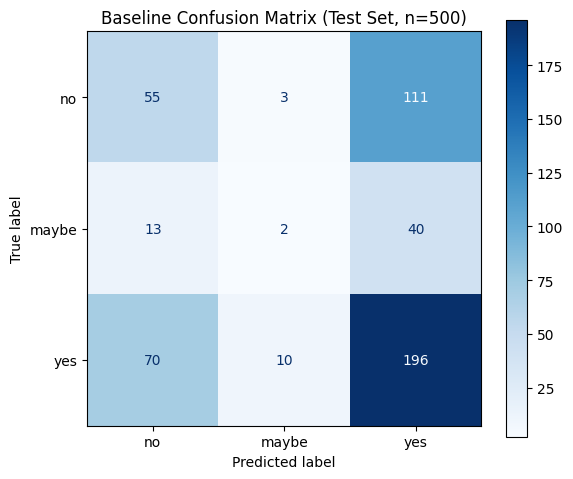

In [ ]:
def make_baseline_pipe():
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=True, stop_words="english",
            ngram_range=(1, 2), max_features=30000
        )),
        ("clf", LogisticRegression(
            max_iter=2000, class_weight="balanced",
            random_state=RANDOM_SEED, C=1.0
        ))
    ])

baseline_res = evaluate_10fold_cv(
    make_baseline_pipe, cv_df, "q_ctx", X_test_qctx, y_test
)

print("=" * 60)
print("BASELINE: TF-IDF (1,2)-grams + Logistic Regression")
print("=" * 60)
print(f"10-Fold CV Accuracy : {baseline_res['cv_acc_mean']:.4f} ± {baseline_res['cv_acc_std']:.4f}")
print(f"10-Fold CV Macro-F1 : {baseline_res['cv_f1_mean']:.4f} ± {baseline_res['cv_f1_std']:.4f}")
print(f"Test Accuracy       : {baseline_res['test_acc']:.4f}")
print(f"Test Macro-F1       : {baseline_res['test_f1']:.4f}")
print(f"\n{classification_report(y_test, baseline_res['preds'], target_names=['no','maybe','yes'], zero_division=0)}")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, baseline_res["preds"],
    display_labels=["no", "maybe", "yes"], ax=ax, cmap="Blues"
)
ax.set_title("Baseline Confusion Matrix (Test Set, n=500)")
plt.tight_layout()
plt.savefig(os.path.join("visualizations", "Baseline_Confusion_Matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

all_results = {}
all_preds = {}

all_results["Baseline: TF-IDF+LR"] = {
    "CV Macro-F1": f"{baseline_res['cv_f1_mean']:.4f} ± {baseline_res['cv_f1_std']:.4f}",
    "Test Acc": baseline_res["test_acc"],
    "Test Macro-F1": baseline_res["test_f1"]
}
all_preds["Baseline"] = baseline_res["preds"]



The baseline result is weak but very informative. The TF-IDF + Logistic Regression model gives a **10-fold CV macro-F1 of 0.3432 ± 0.0525** and a **test macro-F1 of 0.3482**. Test accuracy is **0.5060**, which is below the simple yes-majority accuracy level, so accuracy is not a reliable indicator here.

The baseline mainly shows the limitation of sparse lexical features. It can identify some yes/no patterns, but it struggles badly with maybe. This gives us a clear reference point for the rest of the notebook: any later improvement should be judged not only by overall macro-F1, but also by whether the model recovers the minority class more convincingly.


## Section 8 — Axis 1 classical representation experiments


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future ver

A1a — Question Only + TF-IDF + LR
  10-Fold CV Macro-F1 : 0.3537 ± 0.0524
  Test Acc            : 0.4980
  Test Macro-F1       : 0.3602
              precision    recall  f1-score   support

          no       0.38      0.33      0.36       169
       maybe       0.17      0.07      0.10        55
         yes       0.57      0.68      0.62       276

    accuracy                           0.50       500
   macro avg       0.37      0.36      0.36       500
weighted avg       0.46      0.50      0.48       500


A1b — Question + Context + TF-IDF + LR (= Baseline)
  10-Fold CV Macro-F1 : 0.3432 ± 0.0525
  Test Acc            : 0.5060
  Test Macro-F1       : 0.3482


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datet


A1c — Question + Context + Long Answer + TF-IDF + LR
  10-Fold CV Macro-F1 : 0.3432 ± 0.0310
  Test Acc            : 0.5180
  Test Macro-F1       : 0.3663
              precision    recall  f1-score   support

          no       0.42      0.34      0.38       169
       maybe       0.18      0.05      0.08        55
         yes       0.57      0.72      0.64       276

    accuracy                           0.52       500
   macro avg       0.39      0.37      0.37       500
weighted avg       0.48      0.52      0.49       500


Loading BioBERT embedding model...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


...

Encoding test texts...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future ver


A1d — BioBERT Embeddings + LR
  10-Fold CV Macro-F1 : 0.3608 ± 0.0633
  Test Acc            : 0.4320
  Test Macro-F1       : 0.3529
              precision    recall  f1-score   support

          no       0.35      0.33      0.34       169
       maybe       0.15      0.20      0.17        55
         yes       0.56      0.54      0.55       276

    accuracy                           0.43       500
   macro avg       0.35      0.36      0.35       500
weighted avg       0.44      0.43      0.44       500



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


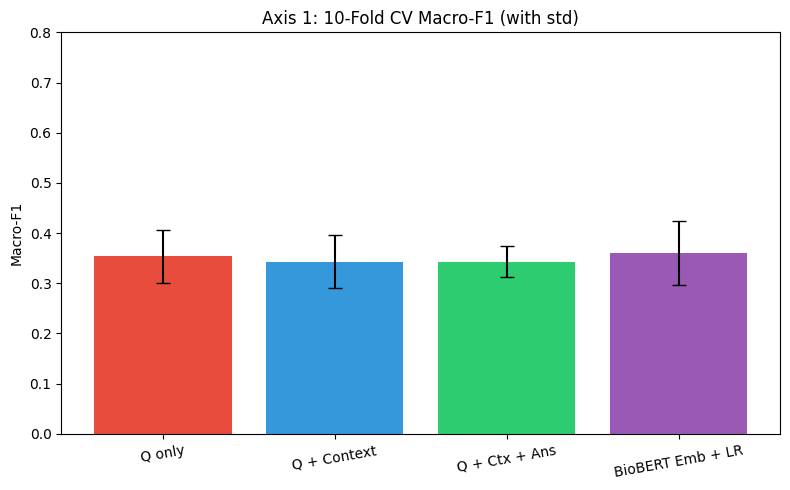

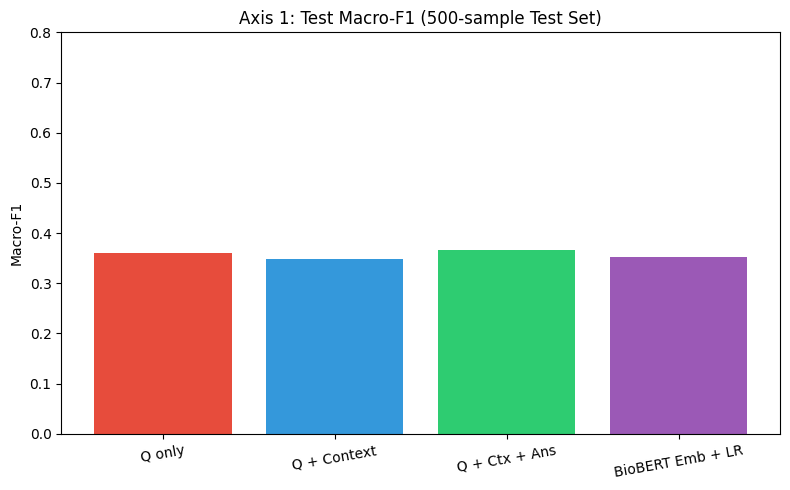


Axis 1 summary:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Variant,CV Macro-F1,CV Std,Test Macro-F1
0,Q only,0.3537,0.0524,0.3602
1,Q + Context,0.3432,0.0525,0.3482
2,Q + Ctx + Ans,0.3432,0.0310,0.3663
3,BioBERT Emb + LR,0.3608,0.0633,0.3529


In [ ]:
# SECTION 8 — AXIS 1: INPUT REPRESENTATION

def make_axis1_pipe():
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1, 2),
            max_features=30000
        )),
        ("clf", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_SEED
        ))
    ])

# A1a — Question only

res_a1a = evaluate_10fold_cv(
    make_axis1_pipe, cv_df, "q_only", X_test_qonly, y_test
)
all_preds["A1a_Q_only"] = res_a1a["preds"]

print("A1a — Question Only + TF-IDF + LR")
print(f"  10-Fold CV Macro-F1 : {res_a1a['cv_f1_mean']:.4f} ± {res_a1a['cv_f1_std']:.4f}")
print(f"  Test Acc            : {res_a1a['test_acc']:.4f}")
print(f"  Test Macro-F1       : {res_a1a['test_f1']:.4f}")
print(classification_report(
    y_test, res_a1a["preds"],
    target_names=["no", "maybe", "yes"],
    zero_division=0
))

# A1b — Question + Context (= Baseline)

res_a1b = baseline_res
all_preds["A1b_Q_Ctx"] = res_a1b["preds"]

print("\nA1b — Question + Context + TF-IDF + LR (= Baseline)")
print(f"  10-Fold CV Macro-F1 : {res_a1b['cv_f1_mean']:.4f} ± {res_a1b['cv_f1_std']:.4f}")
print(f"  Test Acc            : {res_a1b['test_acc']:.4f}")
print(f"  Test Macro-F1       : {res_a1b['test_f1']:.4f}")

# A1c — Question + Context + Long Answer

res_a1c = evaluate_10fold_cv(
    make_axis1_pipe, cv_df, "q_ctx_ans", X_test_qctxans, y_test
)
all_preds["A1c_Q_Ctx_Ans"] = res_a1c["preds"]

print("\nA1c — Question + Context + Long Answer + TF-IDF + LR")
print(f"  10-Fold CV Macro-F1 : {res_a1c['cv_f1_mean']:.4f} ± {res_a1c['cv_f1_std']:.4f}")
print(f"  Test Acc            : {res_a1c['test_acc']:.4f}")
print(f"  Test Macro-F1       : {res_a1c['test_f1']:.4f}")
print(classification_report(
    y_test, res_a1c["preds"],
    target_names=["no", "maybe", "yes"],
    zero_division=0
))

# Store A1a–A1c results

all_results["A1a: Q only"] = {
    "CV Macro-F1": f"{res_a1a['cv_f1_mean']:.4f} ± {res_a1a['cv_f1_std']:.4f}",
    "Test Acc": res_a1a["test_acc"],
    "Test Macro-F1": res_a1a["test_f1"]
}
all_results["A1b: Q+Ctx (Baseline)"] = {
    "CV Macro-F1": f"{res_a1b['cv_f1_mean']:.4f} ± {res_a1b['cv_f1_std']:.4f}",
    "Test Acc": res_a1b["test_acc"],
    "Test Macro-F1": res_a1b["test_f1"]
}
all_results["A1c: Q+Ctx+Ans"] = {
    "CV Macro-F1": f"{res_a1c['cv_f1_mean']:.4f} ± {res_a1c['cv_f1_std']:.4f}",
    "Test Acc": res_a1c["test_acc"],
    "Test Macro-F1": res_a1c["test_f1"]
}

# A1d — BioBERT sentence embeddings + LR

axis1_rows = [
    {
        "Variant": "Q only",
        "CV Macro-F1": res_a1a["cv_f1_mean"],
        "CV Std": res_a1a["cv_f1_std"],
        "Test Macro-F1": res_a1a["test_f1"]
    },
    {
        "Variant": "Q + Context",
        "CV Macro-F1": res_a1b["cv_f1_mean"],
        "CV Std": res_a1b["cv_f1_std"],
        "Test Macro-F1": res_a1b["test_f1"]
    },
    {
        "Variant": "Q + Ctx + Ans",
        "CV Macro-F1": res_a1c["cv_f1_mean"],
        "CV Std": res_a1c["cv_f1_std"],
        "Test Macro-F1": res_a1c["test_f1"]
    }
]

if SBERT_OK:
    print("\nLoading BioBERT embedding model...")
    embedder = SentenceTransformer(
        "pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb"
    )

    print("Encoding CV texts...")
    X_cv_emb = embedder.encode(
        X_cv_qctx,
        show_progress_bar=True,
        batch_size=32
    )

    print("Encoding test texts...")
    X_test_emb = embedder.encode(
        X_test_qctx,
        show_progress_bar=True,
        batch_size=32
    )

    fold_f1s_emb = []
    fold_accs_emb = []

    cv_idx_map = {idx: pos for pos, idx in enumerate(cv_df.index)}

    for fold_idx in range(10):
        val_mask = cv_df["fold"] == fold_idx
        train_mask = ~val_mask

        train_indices = cv_df.index[train_mask].tolist()
        val_indices = cv_df.index[val_mask].tolist()

        tr_pos = [cv_idx_map[i] for i in train_indices]
        va_pos = [cv_idx_map[i] for i in val_indices]

        X_tr_e = X_cv_emb[tr_pos]
        y_tr_e = cv_df.loc[train_indices, "label_id"].values
        X_va_e = X_cv_emb[va_pos]
        y_va_e = cv_df.loc[val_indices, "label_id"].values

        clf_e = LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=RANDOM_SEED
        )
        clf_e.fit(X_tr_e, y_tr_e)
        preds_e = clf_e.predict(X_va_e)

        fold_accs_emb.append(accuracy_score(y_va_e, preds_e))
        fold_f1s_emb.append(f1_score(y_va_e, preds_e, average="macro"))

    emb_clf_final = LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_SEED
    )
    emb_clf_final.fit(X_cv_emb, y_cv)
    pred_emb = emb_clf_final.predict(X_test_emb)

    test_f1_emb = f1_score(y_test, pred_emb, average="macro")
    test_acc_emb = accuracy_score(y_test, pred_emb)

    print("\nA1d — BioBERT Embeddings + LR")
    print(f"  10-Fold CV Macro-F1 : {np.mean(fold_f1s_emb):.4f} ± {np.std(fold_f1s_emb):.4f}")
    print(f"  Test Acc            : {test_acc_emb:.4f}")
    print(f"  Test Macro-F1       : {test_f1_emb:.4f}")
    print(classification_report(
        y_test, pred_emb,
        target_names=["no", "maybe", "yes"],
        zero_division=0
    ))

    all_results["A1d: BioBERT Emb+LR"] = {
        "CV Macro-F1": f"{np.mean(fold_f1s_emb):.4f} ± {np.std(fold_f1s_emb):.4f}",
        "Test Acc": test_acc_emb,
        "Test Macro-F1": test_f1_emb
    }
    all_preds["A1d_BioBERT_Emb"] = pred_emb

    axis1_rows.append({
        "Variant": "BioBERT Emb + LR",
        "CV Macro-F1": np.mean(fold_f1s_emb),
        "CV Std": np.std(fold_f1s_emb),
        "Test Macro-F1": test_f1_emb
    })
else:
    print("\nSentenceTransformers not available — skipping A1d")


# Axis 1 summary table and plots

axis1_summary = pd.DataFrame(axis1_rows)

bar_colors = ["#e74c3c", "#3498db", "#2ecc71", "#9b59b6"][:len(axis1_summary)]

plt.figure(figsize=(8, 5))
plt.bar(
    axis1_summary["Variant"],
    axis1_summary["CV Macro-F1"],
    yerr=axis1_summary["CV Std"],
    capsize=5,
    color=bar_colors
)
plt.title("Axis 1: 10-Fold CV Macro-F1 (with std)")
plt.ylabel("Macro-F1")
plt.ylim(0, 0.8)
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig(
    os.path.join(save_dir, "visualization_7_axis1_cv_macro_f1.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(
    axis1_summary["Variant"],
    axis1_summary["Test Macro-F1"],
    color=bar_colors
)
plt.title("Axis 1: Test Macro-F1 (500-sample Test Set)")
plt.ylabel("Macro-F1")
plt.ylim(0, 0.8)
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig(
    os.path.join(save_dir, "visualization_8_axis1_test_macro_f1.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("\nAxis 1 summary:")
display(axis1_summary.round(4))

The Axis 1 classical results show that changing the input text alone does not rescue the TF-IDF models. Question-only TF-IDF reaches **0.3602** test macro-F1, Q+Ctx reaches **0.3482**, and Q+Ctx+Ans reaches **0.3663**. These scores are very close, which suggests that TF-IDF is not using the extra context and long answer in a deep way.

BioBERT sentence embeddings with Logistic Regression reach **0.3529** macro-F1. The overall score is still near the TF-IDF band, but the maybe-F1 improves compared with the baseline. This gives an early sign that dense biomedical representations can recover some minority-class signal even when the final classifier remains simple.


## Section 9 Block 1 — Tuned classical classifiers


In [ ]:
# SECTION 9 — AXIS 2: CLASSIFIER & TRAINING DESIGN
# BLOCK 1 — PART A (A2a, A2b, A2c)

def evaluate_axis2_10fold(cv_df, test_texts, y_test, text_col="q_ctx"):
    axis2_results = {}
    axis2_preds_dict = {}

    # Shared final features for all word+char models
    X_cv_wc, [X_test_wc], word_vec_final, char_vec_final = build_word_char_features(
        cv_df[text_col].tolist(), [test_texts]
    )

    # A2a: Tuned LR (word+char TF-IDF)
    print("A2a — Tuned Logistic Regression (word+char TF-IDF)")
    fold_f1s_lr = []

    for fold_idx in range(10):
        val_mask = cv_df["fold"] == fold_idx
        train_mask = ~val_mask

        X_tr_texts = cv_df.loc[train_mask, text_col].tolist()
        y_tr = cv_df.loc[train_mask, "label_id"].values
        X_va_texts = cv_df.loc[val_mask, text_col].tolist()
        y_va = cv_df.loc[val_mask, "label_id"].values

        X_tr_wc, [X_va_wc], _, _ = build_word_char_features(X_tr_texts, [X_va_texts])

        inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
        lr_grid = GridSearchCV(
            LogisticRegression(
                max_iter=4000,
                class_weight="balanced",
                solver="liblinear",
                random_state=RANDOM_SEED
            ),
            param_grid={"C": [0.05, 0.1, 0.5, 1.0, 2.0, 5.0]},
            cv=inner_cv,
            scoring="f1_macro",
            refit=True,
            n_jobs=-1
        )
        lr_grid.fit(X_tr_wc, y_tr)
        val_preds = lr_grid.predict(X_va_wc)
        fold_f1s_lr.append(f1_score(y_va, val_preds, average="macro"))

    lr_final = GridSearchCV(
        LogisticRegression(
            max_iter=4000,
            class_weight="balanced",
            solver="liblinear",
            random_state=RANDOM_SEED
        ),
        param_grid={"C": [0.05, 0.1, 0.5, 1.0, 2.0, 5.0]},
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
        scoring="f1_macro",
        refit=True,
        n_jobs=-1
    )
    lr_final.fit(X_cv_wc, y_cv)
    pred_lr = lr_final.predict(X_test_wc)

    print(f"  Best C              : {lr_final.best_params_['C']}")
    print(f"  10-Fold CV Macro-F1 : {np.mean(fold_f1s_lr):.4f} ± {np.std(fold_f1s_lr):.4f}")
    print(f"  Test Acc            : {accuracy_score(y_test, pred_lr):.4f}")
    print(f"  Test Macro-F1       : {f1_score(y_test, pred_lr, average='macro'):.4f}")
    print(classification_report(y_test, pred_lr, target_names=["no", "maybe", "yes"], zero_division=0))

    axis2_results["A2a: LR word+char"] = {
        "CV Macro-F1": f"{np.mean(fold_f1s_lr):.4f} ± {np.std(fold_f1s_lr):.4f}",
        "Test Acc": accuracy_score(y_test, pred_lr),
        "Test Macro-F1": f1_score(y_test, pred_lr, average="macro")
    }
    axis2_preds_dict["A2a_LR_wordchar"] = pred_lr

    # A2b: Calibrated Linear SVM + maybe-threshold tuning 
    print("\nA2b — Calibrated Linear SVM + maybe-threshold tuning")
    fold_f1s_svm = []

    for fold_idx in range(10):
        val_mask = cv_df["fold"] == fold_idx
        train_mask = ~val_mask

        outer_train_df = cv_df.loc[train_mask].reset_index(drop=True)
        outer_val_df = cv_df.loc[val_mask].reset_index(drop=True)

        X_outer_train = outer_train_df[text_col].tolist()
        y_outer_train = outer_train_df["label_id"].values
        X_outer_val = outer_val_df[text_col].tolist()
        y_outer_val = outer_val_df["label_id"].values

        inner_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
        inner_train_idx, inner_dev_idx = next(inner_splitter.split(X_outer_train, y_outer_train))

        X_inner_train = [X_outer_train[i] for i in inner_train_idx]
        y_inner_train = y_outer_train[inner_train_idx]
        X_inner_dev = [X_outer_train[i] for i in inner_dev_idx]
        y_inner_dev = y_outer_train[inner_dev_idx]

        X_inner_wc, [X_dev_wc, X_outer_val_wc], _, _ = build_word_char_features(
            X_inner_train, [X_inner_dev, X_outer_val]
        )

        svm_grid = GridSearchCV(
            LinearSVC(class_weight="balanced", random_state=RANDOM_SEED, max_iter=10000),
            param_grid={"C": [0.01, 0.05, 0.1, 0.5, 1.0, 2.0]},
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
            scoring="f1_macro",
            refit=True,
            n_jobs=-1
        )
        svm_grid.fit(X_inner_wc, y_inner_train)

        cal_svm_fold = CalibratedClassifierCV(
            svm_grid.best_estimator_,
            method="sigmoid",
            cv=5
        )
        cal_svm_fold.fit(X_inner_wc, y_inner_train)

        dev_probs = cal_svm_fold.predict_proba(X_dev_wc)
        best_thr_fold, best_dev_f1_fold = None, -1.0

        for thr in np.arange(0.25, 0.61, 0.025):
            dev_pred_thr = maybe_threshold_predict(dev_probs, maybe_threshold=thr, maybe_class_id=1)
            dev_f1 = f1_score(y_inner_dev, dev_pred_thr, average="macro")
            if dev_f1 > best_dev_f1_fold:
                best_dev_f1_fold = dev_f1
                best_thr_fold = float(thr)

        outer_val_probs = cal_svm_fold.predict_proba(X_outer_val_wc)
        outer_val_preds = maybe_threshold_predict(
            outer_val_probs,
            maybe_threshold=best_thr_fold,
            maybe_class_id=1
        )
        fold_f1s_svm.append(f1_score(y_outer_val, outer_val_preds, average="macro"))

    dev_fold_mask = cv_df["fold"] == 0
    train_no_dev_mask = ~dev_fold_mask

    X_tr_texts_svm = cv_df.loc[train_no_dev_mask, text_col].tolist()
    y_tr_svm = cv_df.loc[train_no_dev_mask, "label_id"].values
    X_dev_texts_svm = cv_df.loc[dev_fold_mask, text_col].tolist()
    y_dev_svm = cv_df.loc[dev_fold_mask, "label_id"].values

    X_tr_wc_s, [X_dev_wc_s, X_test_wc_s], _, _ = build_word_char_features(
        X_tr_texts_svm, [X_dev_texts_svm, test_texts]
    )

    svm_final = GridSearchCV(
        LinearSVC(class_weight="balanced", random_state=RANDOM_SEED, max_iter=10000),
        param_grid={"C": [0.01, 0.05, 0.1, 0.5, 1.0, 2.0]},
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
        scoring="f1_macro",
        refit=True,
        n_jobs=-1
    )
    svm_final.fit(X_tr_wc_s, y_tr_svm)

    cal_svm = CalibratedClassifierCV(
        svm_final.best_estimator_,
        method="sigmoid",
        cv=5
    )
    cal_svm.fit(X_tr_wc_s, y_tr_svm)

    dev_probs = cal_svm.predict_proba(X_dev_wc_s)
    best_thr, best_dev_f1 = None, -1.0
    for thr in np.arange(0.25, 0.61, 0.025):
        dev_pred_thr = maybe_threshold_predict(dev_probs, maybe_threshold=thr, maybe_class_id=1)
        dev_f1 = f1_score(y_dev_svm, dev_pred_thr, average="macro")
        if dev_f1 > best_dev_f1:
            best_dev_f1 = dev_f1
            best_thr = float(thr)

    test_probs_svm = cal_svm.predict_proba(X_test_wc_s)
    pred_svm_thr = maybe_threshold_predict(
        test_probs_svm,
        maybe_threshold=best_thr,
        maybe_class_id=1
    )

    print(f"  Best C              : {svm_final.best_params_['C']}")
    print(f"  Best dev threshold  : {best_thr:.3f}")
    print(f"  10-Fold CV Macro-F1 : {np.mean(fold_f1s_svm):.4f} ± {np.std(fold_f1s_svm):.4f}")
    print(f"  Test Acc            : {accuracy_score(y_test, pred_svm_thr):.4f}")
    print(f"  Test Macro-F1       : {f1_score(y_test, pred_svm_thr, average='macro'):.4f}")
    print(classification_report(y_test, pred_svm_thr, target_names=["no", "maybe", "yes"], zero_division=0))

    axis2_results["A2b: Cal-SVM word+char"] = {
        "CV Macro-F1": f"{np.mean(fold_f1s_svm):.4f} ± {np.std(fold_f1s_svm):.4f}",
        "Test Acc": accuracy_score(y_test, pred_svm_thr),
        "Test Macro-F1": f1_score(y_test, pred_svm_thr, average="macro")
    }
    axis2_preds_dict["A2b_CalSVM_wordchar"] = pred_svm_thr

    # A2c: Multinomial Naive Bayes 
    print("\nA2c — Multinomial Naive Bayes (word+char TF-IDF)")
    fold_f1s_nb = []

    for fold_idx in range(10):
        val_mask = cv_df["fold"] == fold_idx
        train_mask = ~val_mask

        X_tr_texts = cv_df.loc[train_mask, text_col].tolist()
        y_tr = cv_df.loc[train_mask, "label_id"].values
        X_va_texts = cv_df.loc[val_mask, text_col].tolist()
        y_va = cv_df.loc[val_mask, "label_id"].values

        X_tr_wc, [X_va_wc], _, _ = build_word_char_features(X_tr_texts, [X_va_texts])

        nb_grid = GridSearchCV(
            MultinomialNB(),
            param_grid={"alpha": [0.05, 0.1, 0.25, 0.5, 1.0, 2.0]},
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
            scoring="f1_macro",
            refit=True,
            n_jobs=-1
        )
        nb_grid.fit(X_tr_wc, y_tr)
        val_preds = nb_grid.predict(X_va_wc)
        fold_f1s_nb.append(f1_score(y_va, val_preds, average="macro"))

    nb_final = GridSearchCV(
        MultinomialNB(),
        param_grid={"alpha": [0.05, 0.1, 0.25, 0.5, 1.0, 2.0]},
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
        scoring="f1_macro",
        refit=True,
        n_jobs=-1
    )
    nb_final.fit(X_cv_wc, y_cv)
    pred_nb = nb_final.predict(X_test_wc)

    print(f"  Best alpha          : {nb_final.best_params_['alpha']}")
    print(f"  10-Fold CV Macro-F1 : {np.mean(fold_f1s_nb):.4f} ± {np.std(fold_f1s_nb):.4f}")
    print(f"  Test Acc            : {accuracy_score(y_test, pred_nb):.4f}")
    print(f"  Test Macro-F1       : {f1_score(y_test, pred_nb, average='macro'):.4f}")
    print(classification_report(y_test, pred_nb, target_names=["no", "maybe", "yes"], zero_division=0))

    axis2_results["A2c: MNB word+char"] = {
        "CV Macro-F1": f"{np.mean(fold_f1s_nb):.4f} ± {np.std(fold_f1s_nb):.4f}",
        "Test Acc": accuracy_score(y_test, pred_nb),
        "Test Macro-F1": f1_score(y_test, pred_nb, average="macro")
    }
    axis2_preds_dict["A2c_MNB_wordchar"] = pred_nb

    return (
        axis2_results,
        axis2_preds_dict,
        lr_final,
        svm_final,
        nb_final,
        word_vec_final,
        char_vec_final,
        X_cv_wc,
        X_test_wc
    )


axis2_results, axis2_preds_dict, lr_final, svm_final, nb_final, word_vec_final, char_vec_final, X_cv_wc, X_test_wc = \
    evaluate_axis2_10fold(cv_df, X_test_qctx, y_test, text_col="q_ctx")

for k, v in axis2_results.items():
    all_results[k] = v
for k, v in axis2_preds_dict.items():
    all_preds[k] = v

A2a — Tuned Logistic Regression (word+char TF-IDF)
  Best C              : 5.0
  10-Fold CV Macro-F1 : 0.3248 ± 0.0424
  Test Acc            : 0.5320
  Test Macro-F1       : 0.3377
              precision    recall  f1-score   support

          no       0.41      0.25      0.31       169
       maybe       0.33      0.02      0.03        55
         yes       0.57      0.80      0.66       276

    accuracy                           0.53       500
   macro avg       0.44      0.36      0.34       500
weighted avg       0.49      0.53      0.48       500


A2b — Calibrated Linear SVM + maybe-threshold tuning


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Best C              : 2.0
  Best dev threshold  : 0.250
  10-Fold CV Macro-F1 : 0.2773 ± 0.0398
  Test Acc            : 0.5440
  Test Macro-F1       : 0.2642
              precision    recall  f1-score   support

          no       0.38      0.05      0.09       169
       maybe       0.00      0.00      0.00        55
         yes       0.55      0.95      0.70       276

    accuracy                           0.54       500
   macro avg       0.31      0.34      0.26       500
weighted avg       0.43      0.54      0.42       500


A2c — Multinomial Naive Bayes (word+char TF-IDF)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Best alpha          : 0.05
  10-Fold CV Macro-F1 : 0.3108 ± 0.0273
  Test Acc            : 0.5160
  Test Macro-F1       : 0.3224
              precision    recall  f1-score   support

          no       0.37      0.22      0.28       169
       maybe       0.50      0.02      0.04        55
         yes       0.55      0.79      0.65       276

    accuracy                           0.52       500
   macro avg       0.47      0.35      0.32       500
weighted avg       0.49      0.52      0.46       500



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


This block tests whether a better classical classifier can break the sparse-feature plateau. Tuned Logistic Regression reaches **0.3377** test macro-F1, Multinomial Naive Bayes reaches **0.3224**, and the calibrated SVM falls to **0.2642** despite threshold tuning.

The result supports the report’s classifier-design argument: simply changing the classifier on top of TF-IDF does not solve the task. The calibrated SVM also shows that calibration is not a magic fix if the underlying representation is not strong enough. The model may be calibrated around biased probabilities, but it still cannot reason well about uncertain biomedical evidence.


## Section 9 Block 2 — SMOTE and soft voting


In [ ]:

# SECTION 9 — BLOCK 2 — A2d and A2e

import sys
import subprocess
import numpy as np

from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import VotingClassifier

try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    print("imbalanced-learn not found. Installing it now...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "imbalanced-learn"])
    from imblearn.over_sampling import SMOTE


required_vars = [
    "cv_df", "X_cv_wc", "X_test_wc", "y_cv", "y_test",
    "RANDOM_SEED", "build_word_char_features",
    "axis2_results", "axis2_preds_dict", "all_results", "all_preds",
    "svm_final", "lr_final", "nb_final"
]

missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise NameError(
        "These required variables are missing. Run the earlier cells first: "
        + ", ".join(missing_vars)
    )


# A2d: SMOTE + Logistic Regression
print("\nA2d — SMOTE + Logistic Regression (leakage-free, inside 10-fold CV)")

fold_f1s_smote = []

for fold_idx in range(10):
    val_mask = cv_df["fold"] == fold_idx
    train_mask = ~val_mask

    X_tr_texts = cv_df.loc[train_mask, "q_ctx"].tolist()
    y_tr = cv_df.loc[train_mask, "label_id"].values

    X_va_texts = cv_df.loc[val_mask, "q_ctx"].tolist()
    y_va = cv_df.loc[val_mask, "label_id"].values

    X_tr_wc, [X_va_wc], _, _ = build_word_char_features(
        X_tr_texts,
        [X_va_texts]
    )

    class_counts = np.bincount(y_tr)
    min_class_count = class_counts[class_counts > 0].min()
    smote_k = min(5, min_class_count - 1)

    if smote_k < 1:
        print(f"  Fold {fold_idx}: SMOTE skipped because a class has too few samples.")
        X_tr_sm, y_tr_sm = X_tr_wc, y_tr
    else:
        smote = SMOTE(
            random_state=RANDOM_SEED,
            k_neighbors=smote_k
        )
        X_tr_sm, y_tr_sm = smote.fit_resample(X_tr_wc, y_tr)

    clf_sm = LogisticRegression(
        max_iter=4000,
        solver="liblinear",
        class_weight="balanced",
        random_state=RANDOM_SEED,
        C=1.0
    )

    clf_sm.fit(X_tr_sm, y_tr_sm)
    val_preds = clf_sm.predict(X_va_wc)

    fold_macro_f1 = f1_score(
        y_va,
        val_preds,
        average="macro",
        zero_division=0
    )

    fold_f1s_smote.append(fold_macro_f1)

class_counts_cv = np.bincount(y_cv)
min_class_count_cv = class_counts_cv[class_counts_cv > 0].min()
smote_k_final = min(5, min_class_count_cv - 1)

if smote_k_final < 1:
    print("Final SMOTE skipped because a class has too few samples.")
    X_cv_sm, y_cv_sm = X_cv_wc, y_cv
else:
    smote_final = SMOTE(
        random_state=RANDOM_SEED,
        k_neighbors=smote_k_final
    )
    X_cv_sm, y_cv_sm = smote_final.fit_resample(X_cv_wc, y_cv)

lr_smote_final = LogisticRegression(
    max_iter=4000,
    solver="liblinear",
    class_weight="balanced",
    random_state=RANDOM_SEED,
    C=1.0
)

lr_smote_final.fit(X_cv_sm, y_cv_sm)
pred_smote = lr_smote_final.predict(X_test_wc)

smote_cv_mean = np.mean(fold_f1s_smote)
smote_cv_std = np.std(fold_f1s_smote)
smote_acc = accuracy_score(y_test, pred_smote)

smote_f1 = f1_score(
    y_test,
    pred_smote,
    average="macro",
    zero_division=0
)

print(f"  10-Fold CV Macro-F1 : {smote_cv_mean:.4f} ± {smote_cv_std:.4f}")
print(f"  Test Acc            : {smote_acc:.4f}")
print(f"  Test Macro-F1       : {smote_f1:.4f}")

print(
    classification_report(
        y_test,
        pred_smote,
        target_names=["no", "maybe", "yes"],
        zero_division=0
    )
)

axis2_results["A2d: SMOTE+LR w+c"] = {
    "CV Macro-F1": f"{smote_cv_mean:.4f} ± {smote_cv_std:.4f}",
    "Test Acc": smote_acc,
    "Test Macro-F1": smote_f1
}

axis2_preds_dict["A2d_SMOTE_LR"] = pred_smote
all_results["A2d: SMOTE+LR w+c"] = axis2_results["A2d: SMOTE+LR w+c"]
all_preds["A2d_SMOTE_LR"] = pred_smote


# A2e: Soft Voting Ensemble (LR + Cal-SVM + NB)
print("\nA2e — Soft Voting Ensemble (LR + Cal-SVM + NB)")

svm_for_ens = CalibratedClassifierCV(
    LinearSVC(
        C=svm_final.best_params_["C"],
        class_weight="balanced",
        random_state=RANDOM_SEED,
        max_iter=10000
    ),
    method="sigmoid",
    cv=3
)

lr_for_ens = LogisticRegression(
    C=lr_final.best_params_["C"],
    max_iter=4000,
    class_weight="balanced",
    solver="liblinear",
    random_state=RANDOM_SEED
)

nb_for_ens = MultinomialNB(
    alpha=nb_final.best_params_["alpha"]
)

ensemble = VotingClassifier(
    estimators=[
        ("lr", lr_for_ens),
        ("svm", svm_for_ens),
        ("nb", nb_for_ens)
    ],
    voting="soft",
    n_jobs=-1
)

ensemble.fit(X_cv_wc, y_cv)
pred_ensemble = ensemble.predict(X_test_wc)

ens_acc = accuracy_score(y_test, pred_ensemble)

ens_f1 = f1_score(
    y_test,
    pred_ensemble,
    average="macro",
    zero_division=0
)

print(f"  Test Acc            : {ens_acc:.4f}")
print(f"  Test Macro-F1       : {ens_f1:.4f}")

print(
    classification_report(
        y_test,
        pred_ensemble,
        target_names=["no", "maybe", "yes"],
        zero_division=0
    )
)

axis2_results["A2e: Soft Voting Ensemble"] = {
    "CV Macro-F1": np.nan,
    "Test Acc": ens_acc,
    "Test Macro-F1": ens_f1
}

axis2_preds_dict["A2e_Ensemble"] = pred_ensemble
all_results["A2e: Soft Voting Ensemble"] = axis2_results["A2e: Soft Voting Ensemble"]
all_preds["A2e_Ensemble"] = pred_ensemble




A2d — SMOTE + Logistic Regression (leakage-free, inside 10-fold CV)
  10-Fold CV Macro-F1 : 0.3650 ± 0.0470
  Test Acc            : 0.5180
  Test Macro-F1       : 0.3464
              precision    recall  f1-score   support

          no       0.41      0.33      0.37       169
       maybe       0.10      0.02      0.03        55
         yes       0.57      0.73      0.64       276

    accuracy                           0.52       500
   macro avg       0.36      0.36      0.35       500
weighted avg       0.47      0.52      0.48       500


A2e — Soft Voting Ensemble (LR + Cal-SVM + NB)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Test Acc            : 0.5320
  Test Macro-F1       : 0.3243
              precision    recall  f1-score   support

          no       0.39      0.20      0.27       169
       maybe       1.00      0.02      0.04        55
         yes       0.56      0.84      0.67       276

    accuracy                           0.53       500
   macro avg       0.65      0.35      0.32       500
weighted avg       0.55      0.53      0.46       500



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


SMOTE + Logistic Regression gives the best CV score among the classical Axis 2 models, with **0.3650 ± 0.0470** CV macro-F1, but its held-out test macro-F1 is only **0.3464**. This means oversampling does not transfer into a clear test improvement.

The soft-voting ensemble also remains low at **0.3243** test macro-F1. Combining several sparse classifiers does not create new evidence understanding; it mainly averages similar weaknesses. These results are useful because they show that the problem is not just class imbalance. The representation itself is still too shallow for the uncertainty captured by the maybe label.


## Section 9 Block 3 — Classical Axis 2 summary


,CV Macro-F1,Test Acc,Test Macro-F1
A2a: LR word+char,0.3248 ± 0.0424,0.532,0.337674
A2b: Cal-SVM word+char,0.2773 ± 0.0398,0.544,0.264244
A2c: MNB word+char,0.3108 ± 0.0273,0.516,0.322419
A2d: SMOTE+LR w+c,0.3650 ± 0.0470,0.518,0.346357
A2e: Soft Voting Ensemble,NaN,0.532,0.324284



Best Axis 2 classical model (chosen by CV, not test): A2d: SMOTE+LR w+c


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


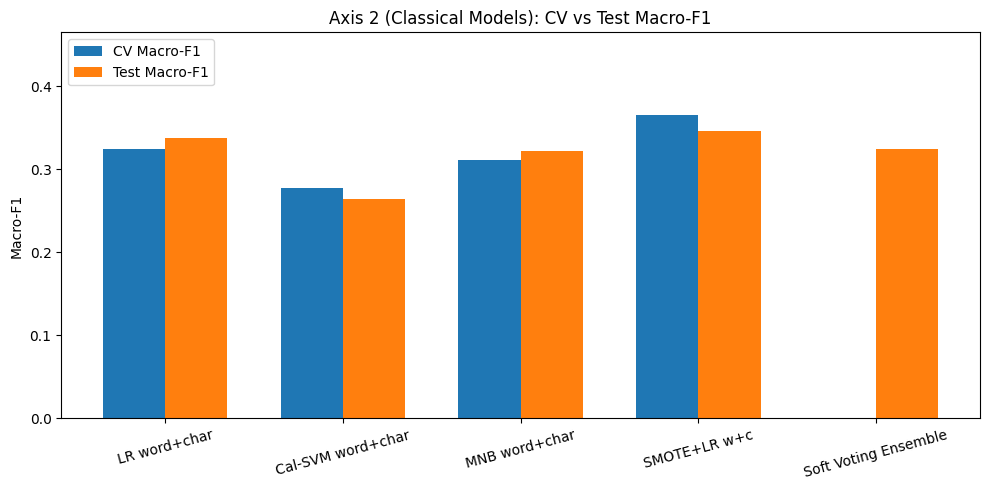

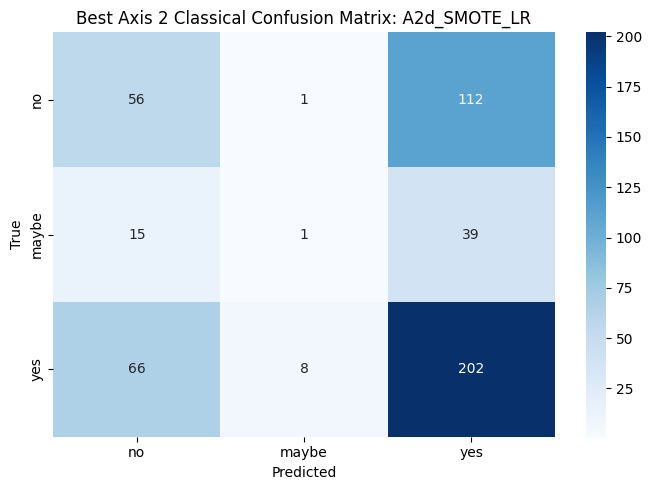

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# SECTION 9 — BLOCK 3 — SUMMARY FOR A2a–A2e

axis2_order = [
    "A2a: LR word+char",
    "A2b: Cal-SVM word+char",
    "A2c: MNB word+char",
    "A2d: SMOTE+LR w+c",
    "A2e: Soft Voting Ensemble"
]

axis2_df = pd.DataFrame.from_dict(
    {k: axis2_results[k] for k in axis2_order},
    orient="index"
)
display(axis2_df)

def get_axis2_cv_mean(name):
    cv_val = axis2_results[name]["CV Macro-F1"]
    if isinstance(cv_val, str):
        return float(cv_val.split(" ± ")[0])
    if pd.isna(cv_val):
        return -np.inf
    return float(cv_val)

best_axis2_name = max(axis2_order, key=get_axis2_cv_mean)
print(f"\nBest Axis 2 classical model (chosen by CV, not test): {best_axis2_name}")

axis2_names_list = axis2_order
axis2_cv_vals = []
axis2_test_vals = []

for k in axis2_names_list:
    cv_val = axis2_results[k]["CV Macro-F1"]
    if isinstance(cv_val, str):
        cv_mean = float(cv_val.split(" ± ")[0])
    elif pd.isna(cv_val):
        cv_mean = np.nan
    else:
        cv_mean = float(cv_val)

    axis2_cv_vals.append(cv_mean)
    axis2_test_vals.append(axis2_results[k]["Test Macro-F1"])

short_names = [n.split(": ")[1] if ": " in n else n for n in axis2_names_list]
x = np.arange(len(short_names))
w = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x, axis2_cv_vals, w, label="CV Macro-F1")
plt.bar(x + w, axis2_test_vals, w, label="Test Macro-F1")
plt.xticks(x + w / 2, short_names, rotation=15)
plt.title("Axis 2 (Classical Models): CV vs Test Macro-F1")
plt.ylabel("Macro-F1")
plt.ylim(0, np.nanmax(axis2_test_vals + axis2_cv_vals) + 0.1)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_9_axis2_cv_vs_test_macro_f1.png"), dpi=300, bbox_inches="tight")
plt.show()

axis2_name_to_pred_key = {
    "A2a: LR word+char": "A2a_LR_wordchar",
    "A2b: Cal-SVM word+char": "A2b_CalSVM_wordchar",
    "A2c: MNB word+char": "A2c_MNB_wordchar",
    "A2d: SMOTE+LR w+c": "A2d_SMOTE_LR",
    "A2e: Soft Voting Ensemble": "A2e_Ensemble"
}

best_a2_key = axis2_name_to_pred_key[best_axis2_name]
best_a2_preds = axis2_preds_dict[best_a2_key]

cm = confusion_matrix(y_test, best_a2_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["no", "maybe", "yes"],
    yticklabels=["no", "maybe", "yes"],
    cmap="Blues"
)
plt.title(f"Best Axis 2 Classical Confusion Matrix: {best_a2_key}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_10_best_axis2_confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

This summary table makes the classical-model story easier to compare. SMOTE + LR is selected as the best classical model by CV, but the test scores of the classical variants all remain in a narrow band. None of them approaches the later transformer scores.

The practical takeaway is that the classical experiments are still valuable as baselines, but they do not provide the main performance lift. They help us rule out the idea that a tuned sparse classifier alone can solve PubMedQA. This supports the move into fine-tuned biomedical transformer models in the next sections.


## Section 9B — Transformer setup


In [ ]:
# SECTION 9B — TRANSFORMER SETUP FOR AXIS 1 AND AXIS 2

FINETUNE_DONE = False          
A1E_DONE = False              
A1F_DONE = False              

pred_biobert_qctx = None       
pred_finetune = None           

a1e_val_logits = None
a1e_test_logits = None
a1f_val_logits = None
a1f_test_logits = None

best_hp_config = None
best_hp_val_f1 = -1.0
best_hp_preds = None
best_hp_logits = None

pubmedbert_f1 = None
pubmedbert_preds = None
pubmedbert_logits = None

lora_preds = None
lora_f1 = None

MODEL_NAME = "dmis-lab/biobert-base-cased-v1.2"
PUBMEDBERT_NAME = "microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract"

TRANSFORMERS_OK = TRANSFORMERS_AVAILABLE if "TRANSFORMERS_AVAILABLE" in globals() else False

if TRANSFORMERS_OK:
    try:
        import gc
        import inspect
        import torch
        from torch.utils.data import Dataset
        from transformers import Trainer, TrainingArguments, EarlyStoppingCallback
    except Exception as e:
        print(f"Could not import transformer training utilities: {e}")
        TRANSFORMERS_OK = False

if TRANSFORMERS_OK and torch.cuda.is_available():
    MAX_LEN = 384
    BATCH_SIZE = 8
    EPOCHS = 8
    device = torch.device("cuda")

    dev_fold_mask = cv_df["fold"] == 0
    train_fold_mask = ~dev_fold_mask

    FT_TEXTS = {
        "q_ctx": {
            "train": cv_df.loc[train_fold_mask, "q_ctx"].tolist(),
            "val": cv_df.loc[dev_fold_mask, "q_ctx"].tolist(),
            "test": list(X_test_qctx)
        },
        "q_ctx_ans": {
            "train": cv_df.loc[train_fold_mask, "q_ctx_ans"].tolist(),
            "val": cv_df.loc[dev_fold_mask, "q_ctx_ans"].tolist(),
            "test": list(X_test_qctxans)
        }
    }

    y_tr_ft = cv_df.loc[train_fold_mask, "label_id"].values.tolist()
    y_val_ft = cv_df.loc[dev_fold_mask, "label_id"].values.tolist()
    y_test_list = list(y_test)

    X_tr_ft = FT_TEXTS["q_ctx_ans"]["train"]
    X_val_ft = FT_TEXTS["q_ctx_ans"]["val"]
    X_test_list = FT_TEXTS["q_ctx_ans"]["test"]

    print(f"Transformer train split (folds 1-9): {len(y_tr_ft)}")
    print(f"Transformer validation split (fold 0): {len(y_val_ft)}")
    print(f"Transformer held-out test split: {len(y_test_list)}")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Skipping transformer setup. Use a GPU runtime with transformers installed.")

if TRANSFORMERS_OK and torch.cuda.is_available():

    class QADataset(Dataset):
        def __init__(self, texts, labels, tokenizer, max_len=256):
            self.texts = list(texts)
            self.labels = list(labels)
            self.tokenizer = tokenizer
            self.max_len = max_len

        def __len__(self):
            return len(self.texts)

        def __getitem__(self, idx):
            enc = self.tokenizer(
                str(self.texts[idx]),
                truncation=True,
                padding="max_length",
                max_length=self.max_len,
                return_tensors="pt"
            )
            item = {k: v.squeeze(0) for k, v in enc.items()}
            item["labels"] = torch.tensor(int(self.labels[idx]), dtype=torch.long)
            return item

    label_counts = Counter(y_tr_ft)
    total = len(y_tr_ft)
    n_classes = 3
    class_weights = torch.tensor(
        [total / (n_classes * label_counts[i]) for i in range(n_classes)],
        dtype=torch.float32,
        device=device
    )
    print(f"Class weights: {class_weights.detach().cpu().tolist()}")

    class WeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs.pop("labels").to(model.device)
            outputs = model(**inputs)
            logits = outputs.logits
            loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)
            loss = loss_fn(logits, labels)
            return (loss, outputs) if return_outputs else loss

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=1)
        return {
            "accuracy": accuracy_score(labels, preds),
            "macro_f1": f1_score(labels, preds, average="macro", zero_division=0)
        }

    def make_training_args(output_dir, learning_rate, train_size):
        """Compatible with both older and newer transformers versions."""
        steps_per_epoch = max(1, train_size // BATCH_SIZE)
        warmup_steps = int(0.1 * steps_per_epoch * EPOCHS)

        kwargs = dict(
            output_dir=output_dir,
            save_strategy="epoch",
            logging_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="macro_f1",
            greater_is_better=True,
            per_device_train_batch_size=BATCH_SIZE,
            per_device_eval_batch_size=BATCH_SIZE,
            num_train_epochs=EPOCHS,
            learning_rate=learning_rate,
            weight_decay=0.01,
            warmup_steps=warmup_steps,
            report_to="none",
            fp16=True,
            save_total_limit=2,
            seed=RANDOM_SEED
        )

        params = inspect.signature(TrainingArguments.__init__).parameters
        if "eval_strategy" in params:
            kwargs["eval_strategy"] = "epoch"
        else:
            kwargs["evaluation_strategy"] = "epoch"

        return TrainingArguments(**kwargs)

    def get_transformer_texts(text_col):
        if text_col not in FT_TEXTS:
            raise ValueError(f"text_col must be one of {list(FT_TEXTS.keys())}, got: {text_col}")

        return (
            FT_TEXTS[text_col]["train"],
            FT_TEXTS[text_col]["val"],
            FT_TEXTS[text_col]["test"],
            y_tr_ft,
            y_val_ft,
            y_test_list
        )

    def run_ft_experiment(
        model_name,
        learning_rate,
        max_len,
        output_dir,
        peft_config=None,
        evaluate_test=True,
        text_col="q_ctx_ans"
    ):
        """
        Fine-tune a 3-class transformer model.

        text_col:
          - "q_ctx"     => BioBERT FT on Question + Context
          - "q_ctx_ans" => BioBERT/PubMedBERT FT on Question + Context + Long Answer
        """
        train_texts, val_texts, test_texts, train_labels, val_labels, test_labels = get_transformer_texts(text_col)

        gc.collect()
        torch.cuda.empty_cache()
        torch.manual_seed(RANDOM_SEED)
        np.random.seed(RANDOM_SEED)

        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=3
        )

        if peft_config is not None:
            model = get_peft_model(model, peft_config)
            model.print_trainable_parameters()

        model = model.to(device)

        train_ds = QADataset(train_texts, train_labels, tokenizer, max_len)
        val_ds = QADataset(val_texts, val_labels, tokenizer, max_len)
        test_ds = QADataset(test_texts, test_labels, tokenizer, max_len)

        training_args = make_training_args(
            output_dir=output_dir,
            learning_rate=learning_rate,
            train_size=len(train_ds)
        )

        trainer = WeightedTrainer(
            model=model,
            args=training_args,
            train_dataset=train_ds,
            eval_dataset=val_ds,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
        )

        trainer.train()

        val_out = trainer.predict(val_ds)
        val_logits = val_out.predictions
        val_preds = np.argmax(val_logits, axis=1)
        val_f1 = f1_score(val_labels, val_preds, average="macro", zero_division=0)
        val_acc = accuracy_score(val_labels, val_preds)

        result = {
            "text_col": text_col,
            "val_f1": val_f1,
            "val_acc": val_acc,
            "val_preds": val_preds,
            "val_logits": val_logits
        }

        if evaluate_test:
            test_out = trainer.predict(test_ds)
            test_logits = test_out.predictions
            test_preds = np.argmax(test_logits, axis=1)
            test_f1 = f1_score(test_labels, test_preds, average="macro", zero_division=0)
            test_acc = accuracy_score(test_labels, test_preds)

            result.update({
                "test_f1": test_f1,
                "test_acc": test_acc,
                "test_preds": test_preds,
                "test_logits": test_logits
            })

        del trainer, model, tokenizer, train_ds, val_ds, test_ds
        gc.collect()
        torch.cuda.empty_cache()

        return result

    print("Transformer datasets, trainer, and shared fine-tuning helper are ready.")
else:
    print("Transformer helper not created because GPU/transformers are unavailable.")


Transformer train split (folds 1-9): 450
Transformer validation split (fold 0): 50
Transformer held-out test split: 500
Using GPU: Tesla T4
Class weights: [0.9868420958518982, 3.0, 0.6048387289047241]
Transformer datasets, trainer, and shared fine-tuning helper are ready.


This setup prepares the transformer train, validation, and test datasets. The validation fold is fold 0 of the CV set, while the held-out test set remains untouched for final reporting. The class weights are also printed, with the maybe class receiving the largest weight because it has the fewest examples.

This design matches the report’s compute-aware setup. Classical models use full 10-fold CV, but transformer models use a smaller validation fold because full repeated transformer training would be expensive. The limitation is noted, but the setup is still consistent: model choices are made on validation output, and the test set is used only after that.


## Section 9C — BioBERT fine-tuning on Q+Ctx and Q+Ctx+Ans


In [ ]:
# SECTION 9C — AXIS 1 TRANSFORMER FINE-TUNING

if TRANSFORMERS_OK and torch.cuda.is_available():
    
    # A1e — BioBERT FT on Question + Context

    try:
        print("\nA1e — BioBERT full fine-tuning on Q+Ctx")
        print("Selection protocol: best checkpoint selected on validation fold 0.")

        res_a1e = run_ft_experiment(
            model_name=MODEL_NAME,
            learning_rate=2e-5,
            max_len=MAX_LEN,
            output_dir="./a1e_biobert_qctx",
            peft_config=None,
            evaluate_test=True,
            text_col="q_ctx"
        )

        pred_biobert_qctx = res_a1e["test_preds"].copy()
        a1e_val_logits = res_a1e["val_logits"].copy()
        a1e_test_logits = res_a1e["test_logits"].copy()
        A1E_DONE = True

        print("\nA1e — BioBERT FT Q+Ctx Results:")
        print(f"  Validation Macro-F1 : {res_a1e['val_f1']:.4f}")
        print(f"  Test Accuracy       : {res_a1e['test_acc']:.4f}")
        print(f"  Test Macro-F1       : {res_a1e['test_f1']:.4f}")
        print(classification_report(
            y_test_list,
            pred_biobert_qctx,
            target_names=["no", "maybe", "yes"],
            zero_division=0
        ))

        all_results["A1e: BioBERT FT Q+Ctx"] = {
            "CV Macro-F1": np.nan,
            "Validation Macro-F1": res_a1e["val_f1"],
            "Selection Protocol": "single validation split",
            "Test Acc": res_a1e["test_acc"],
            "Test Macro-F1": res_a1e["test_f1"]
        }
        all_preds["A1e_BioBERT_QCtx_FT"] = pred_biobert_qctx

    except Exception as e:
        A1E_DONE = False
        print(f"A1e failed: {e}")

   
    # A1f — BioBERT FT on Question + Context + Long Answer
  
    try:
        print("\nA1f — BioBERT full fine-tuning on Q+Ctx+Ans")
        print("This is the direct comparison against A1e with only the input text changed.")

        res_a1f = run_ft_experiment(
            model_name=MODEL_NAME,
            learning_rate=2e-5,
            max_len=MAX_LEN,
            output_dir="./a1f_biobert_qctxans",
            peft_config=None,
            evaluate_test=True,
            text_col="q_ctx_ans"
        )

        pred_finetune = res_a1f["test_preds"].copy()
        a1f_val_logits = res_a1f["val_logits"].copy()
        a1f_test_logits = res_a1f["test_logits"].copy()

        A1F_DONE = True
        FINETUNE_DONE = True

        print("\nA1f — BioBERT FT Q+Ctx+Ans Results:")
        print(f"  Validation Macro-F1 : {res_a1f['val_f1']:.4f}")
        print(f"  Test Accuracy       : {res_a1f['test_acc']:.4f}")
        print(f"  Test Macro-F1       : {res_a1f['test_f1']:.4f}")
        print(classification_report(
            y_test_list,
            pred_finetune,
            target_names=["no", "maybe", "yes"],
            zero_division=0
        ))

        all_results["A1f: BioBERT FT Q+Ctx+Ans"] = {
            "CV Macro-F1": np.nan,
            "Validation Macro-F1": res_a1f["val_f1"],
            "Selection Protocol": "single validation split",
            "Test Acc": res_a1f["test_acc"],
            "Test Macro-F1": res_a1f["test_f1"]
        }
        all_preds["A1f_BioBERT_QCA_FT"] = pred_finetune

        all_results["A2f: BioBERT Full FT"] = all_results["A1f: BioBERT FT Q+Ctx+Ans"]
        all_preds["A2f_BioBERT_FT"] = pred_finetune

        a1e_qca_val_logits = a1f_val_logits
        a1e_qca_test_logits = a1f_test_logits

    except Exception as e:
        A1F_DONE = False
        FINETUNE_DONE = False
        print(f"A1f failed: {e}")

else:
    print("Skipping A1e/A1f BioBERT fine-tuning. Select a GPU runtime and rerun from Section 1.")



A1e — BioBERT full fine-tuning on Q+Ctx
Selection protocol: best checkpoint selected on validation fold 0.


config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/bert/tokenization_bert.py:104: DeprecationWarning: Deprecated in 0.9.0: WordPiece.__init__ will not create from files anymore, try `WordPiece.from_file` instead
  self._tokenizer = Tokenizer(WordPiece(self._vocab, unk_token=str(unk_token)))


pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

...

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



A1f — BioBERT FT Q+Ctx+Ans Results:
  Validation Macro-F1 : 0.5399
  Test Accuracy       : 0.6060
  Test Macro-F1       : 0.4659
              precision    recall  f1-score   support

          no       0.52      0.80      0.63       169
       maybe       0.17      0.07      0.10        55
         yes       0.75      0.59      0.66       276

    accuracy                           0.61       500
   macro avg       0.48      0.49      0.47       500
weighted avg       0.61      0.61      0.59       500



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


This is the first major transformer comparison. BioBERT fine-tuned on **Q+Ctx** gives only **0.2935** test macro-F1, which is weaker than expected. When we keep the model family fixed and add the long answer, BioBERT on **Q+Ctx+Ans** rises to **0.4659** test macro-F1.

This is an important controlled comparison because the main change is the input composition. The long answer appears to provide answer-level cues that the transformer can use better than TF-IDF. This supports the report’s point that Q+Ctx+Ans should be treated as an improved-input setting, not as pure abstract-only question answering.


## A2g — BioBERT hyperparameter search


In [ ]:
# A2g — BioBERT HP-Tuned (select on validation only, then test best config once)

hp_results = []

if TRANSFORMERS_OK and torch.cuda.is_available() and FINETUNE_DONE:
    LR_GRID = [1e-5, 2e-5, 3e-5, 5e-5]
    MAXLEN_GRID = [256, 384]

    best_hp_config = None
    best_hp_val_f1 = -1.0

    for lr_val in LR_GRID:
        for ml_val in MAXLEN_GRID:
            print(f"\nA2g — Trying lr={lr_val}, max_len={ml_val}")

            torch.manual_seed(RANDOM_SEED)
            np.random.seed(RANDOM_SEED)

            try:
                res_hp = run_ft_experiment(
                    model_name=MODEL_NAME,
                    learning_rate=lr_val,
                    max_len=ml_val,
                    output_dir=f"./biobert_hp_lr{lr_val}_ml{ml_val}",
                    peft_config=None,
                    evaluate_test=False
                )

                hp_results.append({
                    "lr": lr_val,
                    "max_len": ml_val,
                    "val_acc": res_hp["val_acc"],
                    "val_f1": res_hp["val_f1"]
                })

                print(f"  -> Validation Macro-F1 = {res_hp['val_f1']:.4f}")

                if res_hp["val_f1"] > best_hp_val_f1:
                    best_hp_val_f1 = res_hp["val_f1"]
                    best_hp_config = {"lr": lr_val, "max_len": ml_val}

            except Exception as e:
                print(f"  -> config failed: {e}")

    if best_hp_config is not None:
        hp_df = pd.DataFrame(hp_results).sort_values("val_f1", ascending=False)
        print("\n" + "=" * 60)
        print("A2g — Hyperparameter Search Results (ranked by Validation Macro-F1):")
        display(hp_df)

        print(f"\nBest config (selected by validation): {best_hp_config}")
        print(f"Best Validation Macro-F1: {best_hp_val_f1:.4f}")

        print("\nRe-running best config once and evaluating on test...")
        best_run = run_ft_experiment(
            model_name=MODEL_NAME,
            learning_rate=best_hp_config["lr"],
            max_len=best_hp_config["max_len"],
            output_dir="./biobert_hp_best_final",
            peft_config=None,
            evaluate_test=True
        )

        best_hp_preds = best_run["test_preds"].copy()
        best_hp_logits = best_run["test_logits"].copy()

        print(f"  Test Accuracy : {best_run['test_acc']:.4f}")
        print(f"  Test Macro-F1 : {best_run['test_f1']:.4f}")
        print(classification_report(
            y_test_list,
            best_hp_preds,
            target_names=["no", "maybe", "yes"],
            zero_division=0
        ))

        all_results["A2g: BioBERT HP-Tuned"] = {
            "CV Macro-F1": np.nan,
            "Validation Macro-F1": best_hp_val_f1,
            "Selection Protocol": "grid search on single validation split",
            "Test Acc": best_run["test_acc"],
            "Test Macro-F1": best_run["test_f1"]
        }
        all_preds["A2g_BioBERT_HP"] = best_hp_preds
    else:
        print("A2g failed: no configuration completed successfully.")
else:
    print("Skipping A2g (GPU/transformers unavailable or A1f BioBERT Q+Ctx+Ans not completed)")


A2g — Trying lr=1e-05, max_len=256


/usr/local/lib/python3.12/dist-packages/transformers/models/bert/tokenization_bert.py:104: DeprecationWarning: Deprecated in 0.9.0: WordPiece.__init__ will not create from files anymore, try `WordPiece.from_file` instead
  self._tokenizer = Tokenizer(WordPiece(self._vocab, unk_token=str(unk_token)))


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.138848,1.103703,0.480000,0.309028
2,1.045113,1.097564,0.300000,0.279221
3,0.936748,1.199307,0.440000,0.295019


...

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Test Accuracy : 0.6740
  Test Macro-F1 : 0.4743
              precision    recall  f1-score   support

          no       0.64      0.70      0.67       169
       maybe       0.00      0.00      0.00        55
         yes       0.72      0.79      0.75       276

    accuracy                           0.67       500
   macro avg       0.45      0.50      0.47       500
weighted avg       0.61      0.67      0.64       500



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


The BioBERT hyperparameter search tests learning rate and maximum sequence length combinations. The best validation configuration is **learning rate 3e-5** with **max length 384**, giving a validation macro-F1 of **0.5369** and a held-out test macro-F1 of **0.4743**.

This improves slightly over the default BioBERT Q+Ctx+Ans run, but the gain is still much smaller than the later PubMedBERT result. The search shows that tuning helps, especially with sequence length, but model pre-training and domain fit remain more important than a small hyperparameter grid alone.


## A1g — PubMedBERT fine-tuning


In [ ]:
# A1g — PubMedBERT Full Fine-Tuning (Q+Ctx+Ans)

if TRANSFORMERS_OK and torch.cuda.is_available() and FINETUNE_DONE:
    try:
        print(f"\nA1g — Fine-tuning PubMedBERT on Q+Ctx+Ans: {PUBMEDBERT_NAME}")
        print("Purpose: test whether a PubMed-specific biomedical model improves over BioBERT.")

        res_a1g = run_ft_experiment(
            model_name=PUBMEDBERT_NAME,
            learning_rate=2e-5,
            max_len=MAX_LEN,
            output_dir="./a1g_pubmedbert_qctxans",
            peft_config=None,
            evaluate_test=True,
            text_col="q_ctx_ans"
        )

        pubmedbert_preds = res_a1g["test_preds"].copy()
        pubmedbert_logits = res_a1g["test_logits"].copy()
        pubmedbert_f1 = res_a1g["test_f1"]

        print("\nA1g — PubMedBERT Q+Ctx+Ans Results:")
        print(f"  Validation Macro-F1 : {res_a1g['val_f1']:.4f}")
        print(f"  Test Accuracy       : {res_a1g['test_acc']:.4f}")
        print(f"  Test Macro-F1       : {res_a1g['test_f1']:.4f}")
        print(classification_report(
            y_test_list,
            pubmedbert_preds,
            target_names=["no", "maybe", "yes"],
            zero_division=0
        ))

        all_results["A1g: PubMedBERT FT Q+Ctx+Ans"] = {
            "CV Macro-F1": np.nan,
            "Validation Macro-F1": res_a1g["val_f1"],
            "Selection Protocol": "single validation split",
            "Test Acc": res_a1g["test_acc"],
            "Test Macro-F1": res_a1g["test_f1"]
        }
        all_preds["A1g_PubMedBERT_QCA_FT"] = pubmedbert_preds

        all_results["A2h: PubMedBERT Full FT"] = all_results["A1g: PubMedBERT FT Q+Ctx+Ans"]
        all_preds["A2h_PubMedBERT_FT"] = pubmedbert_preds

    except Exception as e:
        print(f"A1g PubMedBERT failed: {e}")
else:
    print("Skipping A1g PubMedBERT (GPU/transformers unavailable or A1f BioBERT base not completed)")



A1g — Fine-tuning PubMedBERT on Q+Ctx+Ans: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract
Purpose: test whether a PubMed-specific biomedical model improves over BioBERT.


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/bert/tokenization_bert.py:104: DeprecationWarning: Deprecated in 0.9.0: WordPiece.__init__ will not create from files anymore, try `WordPiece.from_file` instead
  self._tokenizer = Tokenizer(WordPiece(self._vocab, unk_token=str(unk_token)))


...

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



A1g — PubMedBERT Q+Ctx+Ans Results:
  Validation Macro-F1 : 0.7046
  Test Accuracy       : 0.7540
  Test Macro-F1       : 0.6035
              precision    recall  f1-score   support

          no       0.76      0.83      0.80       169
       maybe       0.23      0.16      0.19        55
         yes       0.82      0.82      0.82       276

    accuracy                           0.75       500
   macro avg       0.61      0.61      0.60       500
weighted avg       0.74      0.75      0.74       500



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


This block gives the strongest overall result in the notebook. PubMedBERT fine-tuned on **Q+Ctx+Ans** reaches **0.7540** test accuracy and **0.6035** test macro-F1. The validation macro-F1 is also high at **0.7046**, showing that the model is learning a much stronger biomedical representation than the earlier baselines.

The improvement over BioBERT suggests that the backbone matters, not only the input text. PubMedBERT is more closely matched to biomedical abstracts, and that domain-specific pre-training gives the largest overall lift in the notebook. This becomes the representative best model used for the later error analysis.


## A2i — LoRA PubMedBERT


In [ ]:
# A2i — PubMedBERT + LoRA

if TRANSFORMERS_OK and torch.cuda.is_available() and FINETUNE_DONE:
    try:
        from peft import LoraConfig, get_peft_model, TaskType

        print("\nA2i — Training PubMedBERT + LoRA...")

        LORA_MODEL_NAME = "microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract"

        lora_config = LoraConfig(
            task_type=TaskType.SEQ_CLS,
            r=8,
            lora_alpha=16,
            lora_dropout=0.1,
            target_modules=["query", "value"],
            modules_to_save=["classifier"]
        )

        torch.manual_seed(RANDOM_SEED)
        np.random.seed(RANDOM_SEED)

        lora_lr = 2e-5
        lora_max_len = 384

        print(f"Using fixed LoRA settings: lr={lora_lr}, max_len={lora_max_len}")

        res_lora = run_ft_experiment(
            model_name=LORA_MODEL_NAME,
            learning_rate=lora_lr,
            max_len=lora_max_len,
            output_dir="./lora_output",
            peft_config=lora_config,
            evaluate_test=True,
            text_col="q_ctx_ans"
        )

        lora_preds = res_lora["test_preds"].copy()
        lora_f1 = res_lora["test_f1"]
        lora_acc = res_lora["test_acc"]

        print(f"\nA2i — PubMedBERT + LoRA Results:")
        print(f"  Validation Macro-F1 : {res_lora['val_f1']:.4f}")
        print(f"  Test Accuracy       : {lora_acc:.4f}")
        print(f"  Test Macro-F1       : {lora_f1:.4f}")
        print(classification_report(
            y_test_list,
            lora_preds,
            target_names=["no", "maybe", "yes"],
            zero_division=0
        ))

        all_results["A2i: PubMedBERT LoRA"] = {
            "CV Macro-F1": np.nan,
            "Validation Macro-F1": res_lora["val_f1"],
            "Selection Protocol": "single validation split",
            "Test Acc": lora_acc,
            "Test Macro-F1": lora_f1
        }
        all_preds["A2i_LoRA_PubMedBERT"] = lora_preds

    except Exception as e:
        print(f"A2i failed: {e}")
else:
    print("Skipping A2i (GPU/transformers unavailable or A1f BioBERT Q+Ctx+Ans not completed)")


A2i — Training PubMedBERT + LoRA...
Using fixed LoRA settings: lr=2e-05, max_len=384


/usr/local/lib/python3.12/dist-packages/transformers/models/bert/tokenization_bert.py:104: DeprecationWarning: Deprecated in 0.9.0: WordPiece.__init__ will not create from files anymore, try `WordPiece.from_file` instead
  self._tokenizer = Tokenizer(WordPiece(self._vocab, unk_token=str(unk_token)))


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:

trainable params: 297,219 || all params: 109,781,766 || trainable%: 0.2707


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: Deprecati

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



A2i — PubMedBERT + LoRA Results:
  Validation Macro-F1 : 0.3763
  Test Accuracy       : 0.4060
  Test Macro-F1       : 0.3399
              precision    recall  f1-score   support

          no       0.36      0.63      0.46       169
       maybe       0.14      0.15      0.14        55
         yes       0.60      0.32      0.42       276

    accuracy                           0.41       500
   macro avg       0.37      0.37      0.34       500
weighted avg       0.47      0.41      0.40       500



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


The LoRA experiment tests whether parameter-efficient fine-tuning can approximate full PubMedBERT fine-tuning. It reaches **0.3399** test macro-F1, which is above the zero-shot result but far below full PubMedBERT fine-tuning.

This result is still useful because it shows the trade-off clearly. LoRA reduces trainable parameters and is cheaper, but on this small and imbalanced dataset it does not capture enough of the task. For our final story, LoRA is best treated as a compute-saving comparison rather than a competitive best model.


## A2j — Zero-shot BART-MNLI


In [ ]:
# AXIS 2 — PART C: ZERO-SHOT BASELINE

# A2j: Zero-Shot BART-MNLI 
if TRANSFORMERS_OK:
    import gc
    from transformers import pipeline as hf_pipeline

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print("\nA2j — Loading zero-shot classification pipeline (BART-large-MNLI)...")
    zs_clf = hf_pipeline(
        "zero-shot-classification",
        model="facebook/bart-large-mnli",
        device=0 if torch.cuda.is_available() else -1
    )

    candidate_labels = ["yes", "no", "maybe"]
    zs_preds = []

    print(f"Classifying {len(X_test_qctx)} test samples (zero-shot)...")
    for i, text in enumerate(X_test_qctx):
        result = zs_clf(
            text,
            candidate_labels,
            hypothesis_template="The answer to this medical question is {}.",
            multi_label=False,
            truncation=True,
            max_length=512
        )

        zs_preds.append(label2id[result["labels"][0]])

        if (i + 1) % 100 == 0:
            print(f"  Processed {i+1}/{len(X_test_qctx)}")

    zs_preds = np.array(zs_preds)
    zs_acc = accuracy_score(y_test, zs_preds)
    zs_f1 = f1_score(y_test, zs_preds, average="macro")

    print(f"\nA2j — Zero-Shot BART-MNLI Results:")
    print(f"  Test Acc      : {zs_acc:.4f}")
    print(f"  Test Macro-F1 : {zs_f1:.4f}")
    print(classification_report(
        y_test,
        zs_preds,
        target_names=["no", "maybe", "yes"],
        zero_division=0
    ))

    all_results["A2j: Zero-Shot BART-MNLI"] = {
        "CV Macro-F1": "N/A (zero-shot)",
        "Test Acc": zs_acc,
        "Test Macro-F1": zs_f1
    }
    all_preds["A2j_ZeroShot_BART"] = zs_preds
else:
    print("Transformers not available — skipping zero-shot classification")


A2j — Loading zero-shot classification pipeline (BART-large-MNLI)...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

sys:1: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7cbf5dc14130>
sys:1: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7cbf5dc15780>
sys:1: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7cbf5dc14670>
sys:1: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7cbf5dc15400>
sys:1: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7cbf5dc14c90>
sys:1: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7cbf5dc14c20>
sys:1: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7cbf5dc15630>
sys:1: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7cbf5dc152b0>
sys:1: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7cbf5dc155c0>
sys:1: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7cbf5dc16270>
sys:1: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7cbf5dc159b0>
sys:1: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x7cbf5dc16200>
sys:1: ResourceWarning: Uncl

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

Classifying 500 test samples (zero-shot)...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  Processed 100/500
  Processed 200/500
  Processed 300/500
  Processed 400/500
  Processed 500/500

A2j — Zero-Shot BART-MNLI Results:
  Test Acc      : 0.1140
  Test Macro-F1 : 0.0741
              precision    recall  f1-score   support

          no       1.00      0.01      0.02       169
       maybe       0.11      1.00      0.20        55
         yes       0.00      0.00      0.00       276

    accuracy                           0.11       500
   macro avg       0.37      0.34      0.07       500
weighted avg       0.35      0.11      0.03       500



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


The zero-shot BART-MNLI model performs very poorly, with **0.1140** accuracy and **0.0741** macro-F1. This is an important negative result. A general NLI model can map labels to hypotheses, but it does not understand the PubMedQA answer labels in the way this task requires.

The result shows that biomedical QA cannot be solved here by simply applying an off-the-shelf zero-shot classifier. The model needs task-specific training or at least stronger domain adaptation. This also supports the report’s decision to focus the main conclusions on fine-tuned biomedical transformers rather than zero-shot transfer.


## Section 10 — Axis 1 final summary



Axis 1 final summary — representation, feature engineering, and biomedical evidence understanding


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Variant,Validation Macro-F1,Test Accuracy,Test Macro-F1,F1_maybe,Predicted_maybe
0,A1a TF-IDF+LR — Q only,NaN,0.498,0.3602,0.1013,24
1,A1b TF-IDF+LR — Q+Ctx baseline,NaN,0.506,0.3482,0.0571,15
2,A1c TF-IDF+LR — Q+Ctx+Ans,NaN,0.518,0.3663,0.0833,17
3,Feature engineering: TF-IDF+LR word+char — Q+Ctx,NaN,0.532,0.3377,0.0345,3
4,A1d BioBERT embeddings+LR — Q+Ctx,NaN,0.432,0.3529,0.1719,73
5,A1e BioBERT FT — Q+Ctx,0.3459,0.524,0.2935,0.0000,0
6,A1f BioBERT FT — Q+Ctx+Ans,0.5399,0.606,0.4659,0.1013,24
7,A1g PubMedBERT FT — Q+Ctx+Ans,0.7046,0.754,0.6035,0.1915,39


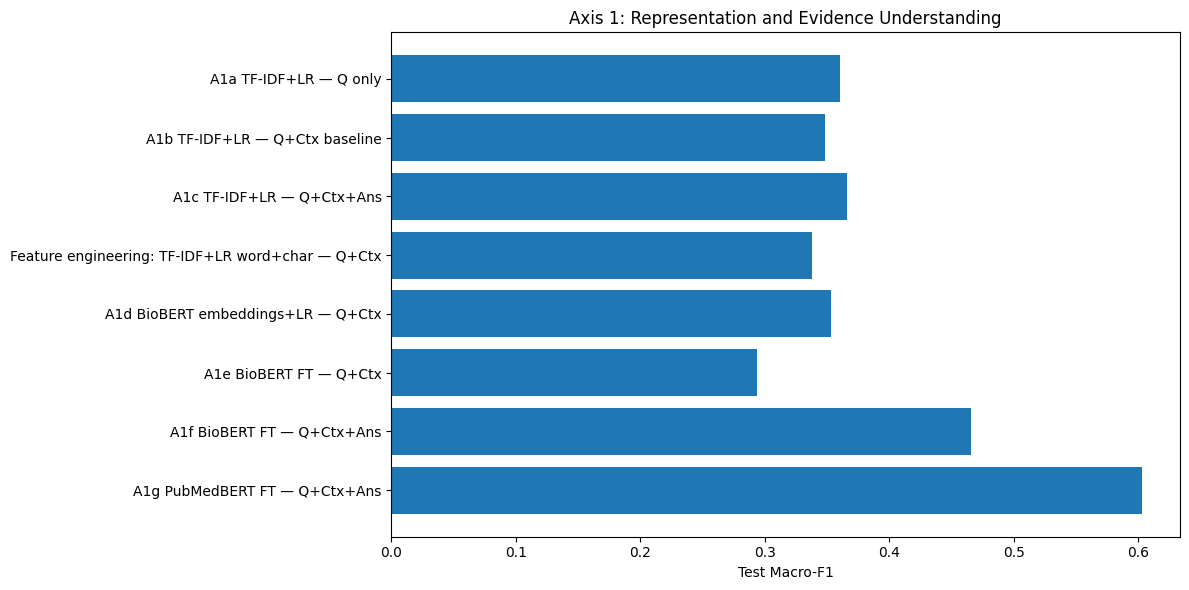

In [ ]:
# SECTION 10 — AXIS 1 FINAL SUMMARY

axis1_final_rows = []

def add_axis1_row(display_name, pred_key, val_f1=np.nan):
    if pred_key in all_preds:
        preds = np.array(all_preds[pred_key])
        axis1_final_rows.append({
            "Variant": display_name,
            "Validation Macro-F1": val_f1,
            "Test Accuracy": accuracy_score(y_test_list, preds),
            "Test Macro-F1": f1_score(y_test_list, preds, average="macro", zero_division=0),
            "F1_maybe": f1_score(y_test_list, preds, average=None, labels=[0, 1, 2], zero_division=0)[1],
            "Predicted_maybe": int(np.sum(preds == 1))
        })

# Sparse input-content variants
add_axis1_row("A1a TF-IDF+LR — Q only", "A1a_Q_only")
add_axis1_row("A1b TF-IDF+LR — Q+Ctx baseline", "A1b_Q_Ctx")
add_axis1_row("A1c TF-IDF+LR — Q+Ctx+Ans", "A1c_Q_Ctx_Ans")

# Feature engineering variant from the classical block.
add_axis1_row("Feature engineering: TF-IDF+LR word+char — Q+Ctx", "A2a_LR_wordchar")

# Biomedical semantic representations
add_axis1_row("A1d BioBERT embeddings+LR — Q+Ctx", "A1d_BioBERT_Emb")

# Transformer fine-tuning variants
a1e_val = all_results.get("A1e: BioBERT FT Q+Ctx", {}).get("Validation Macro-F1", np.nan)
a1f_val = all_results.get("A1f: BioBERT FT Q+Ctx+Ans", {}).get("Validation Macro-F1", np.nan)
a1g_val = all_results.get("A1g: PubMedBERT FT Q+Ctx+Ans", {}).get("Validation Macro-F1", np.nan)

add_axis1_row("A1e BioBERT FT — Q+Ctx", "A1e_BioBERT_QCtx_FT", a1e_val)
add_axis1_row("A1f BioBERT FT — Q+Ctx+Ans", "A1f_BioBERT_QCA_FT", a1f_val)
add_axis1_row("A1g PubMedBERT FT — Q+Ctx+Ans", "A1g_PubMedBERT_QCA_FT", a1g_val)

if axis1_final_rows:
    axis1_final_summary = pd.DataFrame(axis1_final_rows)

    print("\nAxis 1 final summary — representation, feature engineering, and biomedical evidence understanding")
    display(axis1_final_summary.round(4))

    plt.figure(figsize=(12, 6))
    plt.barh(axis1_final_summary["Variant"], axis1_final_summary["Test Macro-F1"])
    plt.xlabel("Test Macro-F1")
    plt.title("Axis 1: Representation and Evidence Understanding")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "axis1_final_representation_story.png"), dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No Axis 1 predictions available yet.")


The Axis 1 summary brings together the representation story. Sparse TF-IDF variants stay close to **0.35–0.37** macro-F1. BioBERT embeddings do not lift the overall score much, but they help the maybe class more than the baseline. Fine-tuned BioBERT improves once Q+Ctx+Ans is used, and PubMedBERT gives the strongest result.

The main interpretation is that representation and input composition interact. The long answer does not help TF-IDF much because sparse features treat words as isolated tokens. Transformers can use the same extra text more effectively because they model the context around answer-indicative phrases.


## Section 11 setup — Maybe-class interventions


In [ ]:
# SECTION 11 — AXIS 2B: MAYBE-CLASS / UNCERTAINTY INTERVENTIONS

print("Section 11 ready — Axis 2B uncertainty/maybe-class interventions.")
print(f"A1f BioBERT Q+Ctx+Ans logits available for thresholding: {a1f_val_logits is not None and a1f_test_logits is not None}")
print("Base model for M1 threshold tuning: A1f BioBERT FT on Q+Ctx+Ans")


Section 11 ready — Axis 2B uncertainty/maybe-class interventions.
A1f BioBERT Q+Ctx+Ans logits available for thresholding: True
Base model for M1 threshold tuning: A1f BioBERT FT on Q+Ctx+Ans


This short block confirms that the logits from the BioBERT Q+Ctx+Ans model are available for threshold tuning. That is necessary because the next experiments focus on the maybe class and uncertainty handling.

At this stage, the notebook shifts from overall model improvement to a more targeted question: can we recover more true maybe cases without damaging the overall macro-F1 too much? This is why the following sections test thresholds, focal loss, ordinal loss, and hierarchical classification.


## M1 — BioBERT threshold tuning


In [ ]:
# M1 — Threshold Tuning on A1f BioBERT Q+Ctx+Ans

if a1f_val_logits is not None and a1f_test_logits is not None:
    best_qca_thr = tune_maybe_threshold(a1f_val_logits, np.array(y_val_ft))
    test_probs_qca = sp_softmax(a1f_test_logits, axis=1)

    qca_threshold_preds = maybe_threshold_predict(
        test_probs_qca,
        maybe_threshold=best_qca_thr["threshold"],
        maybe_class_id=1
    )

    qca_thr_acc = accuracy_score(y_test_list, qca_threshold_preds)
    qca_thr_f1 = f1_score(y_test_list, qca_threshold_preds, average="macro", zero_division=0)
    qca_thr_per_class = f1_score(
        y_test_list,
        qca_threshold_preds,
        average=None,
        labels=[0, 1, 2],
        zero_division=0
    )

    print("M1 — BioBERT Q+Ctx+Ans + Threshold Tuning")
    print(f"  Best threshold : {best_qca_thr['threshold']:.3f}")
    print(f"  Val Macro-F1   : {best_qca_thr['macro_f1']:.4f}")
    print(f"  Val Maybe-F1   : {best_qca_thr['maybe_f1']:.4f}")
    print(f"  Test Accuracy  : {qca_thr_acc:.4f}")
    print(f"  Test Macro-F1  : {qca_thr_f1:.4f}")
    print(f"  Per-class F1   : no={qca_thr_per_class[0]:.3f}  maybe={qca_thr_per_class[1]:.3f}  yes={qca_thr_per_class[2]:.3f}")
    print(classification_report(
        y_test_list,
        qca_threshold_preds,
        target_names=["no", "maybe", "yes"],
        zero_division=0
    ))

    all_preds["M1_BioBERT_QCA_Threshold"] = qca_threshold_preds
    all_results["M1: BioBERT QCA + Threshold"] = {
        "CV Macro-F1": np.nan,
        "Validation Macro-F1": best_qca_thr["macro_f1"],
        "Selection Protocol": "threshold tuned on validation split",
        "Test Acc": qca_thr_acc,
        "Test Macro-F1": qca_thr_f1
    }
else:
    print("Skipping M1: A1f logits are unavailable. Run the A1f BioBERT Q+Ctx+Ans cell first.")


M1 — BioBERT Q+Ctx+Ans + Threshold Tuning
  Best threshold : 0.350
  Val Macro-F1   : 0.5584
  Val Maybe-F1   : 0.3333
  Test Accuracy  : 0.5740
  Test Macro-F1  : 0.4723
  Per-class F1   : no=0.592  maybe=0.161  yes=0.664
              precision    recall  f1-score   support

          no       0.53      0.67      0.59       169
       maybe       0.14      0.18      0.16        55
         yes       0.75      0.59      0.66       276

    accuracy                           0.57       500
   macro avg       0.48      0.48      0.47       500
weighted avg       0.61      0.57      0.58       500



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Threshold tuning on BioBERT Q+Ctx+Ans selects a maybe threshold of **0.350**. On validation, this improves the maybe signal, and on the test set it gives **0.4723** macro-F1 with **0.161** maybe-F1.

Compared with the base BioBERT Q+Ctx+Ans model, this is better for maybe recovery, but it does not become the best overall model. The result shows that post-hoc thresholding can move the model toward the minority class, but it depends heavily on a small validation fold. With only a few maybe cases in fold 0, the selected threshold should be interpreted carefully.


## M2 and M3 — Focal loss and threshold tuning


In [ ]:
# M2 — PubMedBERT + Focal Loss
# M3 — PubMedBERT + Focal Loss + Threshold Tuning

if TRANSFORMERS_OK and torch.cuda.is_available() and FINETUNE_DONE:
    print("\nM2 — Training PubMedBERT with Focal Loss for maybe-class recovery...")

    FOCAL_GAMMA = 2.0

    class FocalLossTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs.pop("labels").to(model.device)
            outputs = model(**inputs)
            logits = outputs.logits

            ce_loss = torch.nn.CrossEntropyLoss(weight=class_weights, reduction="none")
            base_loss = ce_loss(logits, labels)

            probs = torch.softmax(logits, dim=-1)
            pt = probs.gather(1, labels.unsqueeze(1)).squeeze(1)
            focal_weight = (1 - pt) ** FOCAL_GAMMA

            loss = (focal_weight * base_loss).mean()
            return (loss, outputs) if return_outputs else loss

    gc.collect()
    torch.cuda.empty_cache()
    torch.manual_seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    best_lr_fl = best_hp_config["lr"] if best_hp_config else 2e-5
    best_ml_fl = best_hp_config["max_len"] if best_hp_config else 384

    tok_fl = AutoTokenizer.from_pretrained(PUBMEDBERT_NAME)
    model_fl = AutoModelForSequenceClassification.from_pretrained(
        PUBMEDBERT_NAME,
        num_labels=3
    ).to(device)

    train_ds_fl = QADataset(X_tr_ft, y_tr_ft, tok_fl, best_ml_fl)
    val_ds_fl = QADataset(X_val_ft, y_val_ft, tok_fl, best_ml_fl)
    test_ds_fl = QADataset(X_test_list, y_test_list, tok_fl, best_ml_fl)

    args_fl = make_training_args(
        output_dir="./pubmedbert_focal",
        learning_rate=best_lr_fl,
        train_size=len(train_ds_fl)
    )

    trainer_fl = FocalLossTrainer(
        model=model_fl,
        args=args_fl,
        train_dataset=train_ds_fl,
        eval_dataset=val_ds_fl,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    trainer_fl.train()

    val_out_fl = trainer_fl.predict(val_ds_fl)
    out_fl = trainer_fl.predict(test_ds_fl)

    focal_preds = np.argmax(out_fl.predictions, axis=1)
    focal_f1 = f1_score(y_test_list, focal_preds, average="macro")
    focal_acc = accuracy_score(y_test_list, focal_preds)
    focal_per_class = f1_score(y_test_list, focal_preds, average=None, labels=[0, 1, 2], zero_division=0)

    print(f"\nM2 — PubMedBERT + Focal Loss Results:")
    print(f"  Test Accuracy : {focal_acc:.4f}")
    print(f"  Test Macro-F1 : {focal_f1:.4f}")
    print(f"  Per-class F1  : no={focal_per_class[0]:.3f}  maybe={focal_per_class[1]:.3f}  yes={focal_per_class[2]:.3f}")
    print(classification_report(
        y_test_list,
        focal_preds,
        target_names=["no", "maybe", "yes"],
        zero_division=0
    ))

    all_preds["M2_PubMedBERT_Focal"] = focal_preds
    all_results["M2: PubMedBERT Focal Loss"] = {
        "CV Macro-F1": np.nan,
        "Validation Macro-F1": np.nan,
        "Selection Protocol": "best checkpoint on validation split",
        "Test Acc": focal_acc,
        "Test Macro-F1": focal_f1
    }

    # M3: Focal + Threshold
    best_fl_thr = tune_maybe_threshold(val_out_fl.predictions, np.array(y_val_ft))
    test_probs_fl = sp_softmax(out_fl.predictions, axis=1)

    focal_thr_preds = maybe_threshold_predict(
        test_probs_fl,
        maybe_threshold=best_fl_thr["threshold"],
        maybe_class_id=1
    )

    focal_thr_f1 = f1_score(y_test_list, focal_thr_preds, average="macro")
    focal_thr_acc = accuracy_score(y_test_list, focal_thr_preds)
    focal_thr_per_class = f1_score(y_test_list, focal_thr_preds, average=None, labels=[0, 1, 2], zero_division=0)

    print(f"\nM3 — PubMedBERT + Focal Loss + Threshold Tuning")
    print(f"  Best threshold       : {best_fl_thr['threshold']:.3f}")
    print(f"  Validation Macro-F1  : {best_fl_thr['macro_f1']:.4f}")
    print(f"  Validation Maybe-F1  : {best_fl_thr['maybe_f1']:.4f}")
    print(f"  Test Accuracy        : {focal_thr_acc:.4f}")
    print(f"  Test Macro-F1        : {focal_thr_f1:.4f}")
    print(f"  Per-class F1         : no={focal_thr_per_class[0]:.3f}  maybe={focal_thr_per_class[1]:.3f}  yes={focal_thr_per_class[2]:.3f}")
    print(classification_report(
        y_test_list,
        focal_thr_preds,
        target_names=["no", "maybe", "yes"],
        zero_division=0
    ))

    all_preds["M3_PubMedBERT_Focal_Threshold"] = focal_thr_preds
    all_results["M3: PubMedBERT Focal + Threshold"] = {
        "CV Macro-F1": np.nan,
        "Validation Macro-F1": best_fl_thr["macro_f1"],
        "Selection Protocol": "threshold tuned on validation split",
        "Test Acc": focal_thr_acc,
        "Test Macro-F1": focal_thr_f1
    }

    del model_fl, trainer_fl, tok_fl, train_ds_fl, val_ds_fl, test_ds_fl
    gc.collect()
    torch.cuda.empty_cache()

else:
    print("Skipping M2/M3 (GPU or transformers unavailable)")



M2 — Training PubMedBERT with Focal Loss for maybe-class recovery...


/usr/local/lib/python3.12/dist-packages/transformers/models/bert/tokenization_bert.py:104: DeprecationWarning: Deprecated in 0.9.0: WordPiece.__init__ will not create from files anymore, try `WordPiece.from_file` instead
  self._tokenizer = Tokenizer(WordPiece(self._vocab, unk_token=str(unk_token)))


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.546183,0.547396,0.440000,0.283806
2,0.541391,0.471281,0.260000,0.256113
3,0.373027,0.385558,0.720000,0.599577
4,0.229803,0.365924,0.580000,0.539305
5,0.129314,0.446295,0.660000,0.534722


...

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



M2 — PubMedBERT + Focal Loss Results:
  Test Accuracy : 0.7280
  Test Macro-F1 : 0.5912
  Per-class F1  : no=0.694  maybe=0.237  yes=0.842
              precision    recall  f1-score   support

          no       0.84      0.59      0.69       169
       maybe       0.22      0.25      0.24        55
         yes       0.79      0.91      0.84       276

    accuracy                           0.73       500
   macro avg       0.62      0.58      0.59       500
weighted avg       0.74      0.73      0.73       500


M3 — PubMedBERT + Focal Loss + Threshold Tuning
  Best threshold       : 0.500
  Validation Macro-F1  : 0.5026
  Validation Maybe-F1  : 0.0000
  Test Accuracy        : 0.7700
  Test Macro-F1        : 0.5675
  Per-class F1         : no=0.768  maybe=0.094  yes=0.841
              precision    recall  f1-score   support

          no       0.83      0.72      0.77       169
       maybe       0.33      0.05      0.09        55
         yes       0.76      0.95      0.84       

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Focal loss gives the strongest maybe-class result in the notebook. M2 reaches **0.5912** test macro-F1 and **0.237** maybe-F1, which is higher than the maybe-F1 of the best overall model. This suggests that focal loss does what we hoped: it shifts more learning pressure onto harder examples.

M3 adds threshold tuning on top of focal loss and reaches the highest accuracy, **0.7700**, but its maybe-F1 drops to **0.094**. This is the clearest example of the trade-off in the notebook. A model can look better by accuracy while becoming worse at identifying uncertainty. For a biomedical QA task, that trade-off cannot be ignored.


## M4 — Ordinal loss


In [ ]:
# M4 — PubMedBERT + Ordinal-Aware Loss

if TRANSFORMERS_OK and torch.cuda.is_available() and FINETUNE_DONE:
    print("\nM4 — Training PubMedBERT with ordinal-aware loss...")

    all_preds.pop("M4_BioBERT_Ordinal", None)
    all_results.pop("M4: BioBERT Ordinal Loss", None)

    ORDINAL_ALPHA = 1.0

    class OrdinalWeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs.pop("labels").to(model.device)
            outputs = model(**inputs)
            logits = outputs.logits

            ce_loss = torch.nn.CrossEntropyLoss(weight=class_weights, reduction="none")
            base_loss = ce_loss(logits, labels)

            probs = torch.softmax(logits, dim=-1)
            ordinal_classes = torch.arange(3, device=model.device, dtype=torch.float32)
            expected_pos = (probs * ordinal_classes.unsqueeze(0)).sum(dim=-1)
            ordinal_dist = (expected_pos - labels.float()) ** 2

            loss = base_loss.mean() + ORDINAL_ALPHA * ordinal_dist.mean()
            return (loss, outputs) if return_outputs else loss

    gc.collect()
    torch.cuda.empty_cache()
    torch.manual_seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    best_lr_ord = best_hp_config["lr"] if best_hp_config else 2e-5
    best_ml_ord = best_hp_config["max_len"] if best_hp_config else 384

    tok_ord = AutoTokenizer.from_pretrained(PUBMEDBERT_NAME)
    model_ord = AutoModelForSequenceClassification.from_pretrained(
        PUBMEDBERT_NAME,
        num_labels=3
    ).to(device)

    train_ds_ord = QADataset(X_tr_ft, y_tr_ft, tok_ord, best_ml_ord)
    val_ds_ord = QADataset(X_val_ft, y_val_ft, tok_ord, best_ml_ord)
    test_ds_ord = QADataset(X_test_list, y_test_list, tok_ord, best_ml_ord)

    steps_ord = max(1, len(train_ds_ord) // BATCH_SIZE)

    try:
        args_ord = TrainingArguments(
            output_dir="./pubmedbert_ordinal",
            eval_strategy="epoch",
            save_strategy="epoch",
            logging_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="macro_f1",
            greater_is_better=True,
            per_device_train_batch_size=BATCH_SIZE,
            per_device_eval_batch_size=BATCH_SIZE,
            num_train_epochs=8,
            learning_rate=best_lr_ord,
            weight_decay=0.01,
            warmup_steps=int(0.1 * steps_ord * 8),
            report_to="none",
            fp16=True,
            save_total_limit=2,
            seed=RANDOM_SEED
        )
    except TypeError:
        args_ord = TrainingArguments(
            output_dir="./pubmedbert_ordinal",
            evaluation_strategy="epoch",
            save_strategy="epoch",
            logging_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="macro_f1",
            greater_is_better=True,
            per_device_train_batch_size=BATCH_SIZE,
            per_device_eval_batch_size=BATCH_SIZE,
            num_train_epochs=8,
            learning_rate=best_lr_ord,
            weight_decay=0.01,
            warmup_steps=int(0.1 * steps_ord * 8),
            report_to="none",
            fp16=True,
            save_total_limit=2,
            seed=RANDOM_SEED
        )

    trainer_ord = OrdinalWeightedTrainer(
        model=model_ord,
        args=args_ord,
        train_dataset=train_ds_ord,
        eval_dataset=val_ds_ord,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    trainer_ord.train()

    out_ord = trainer_ord.predict(test_ds_ord)
    ordinal_preds = np.argmax(out_ord.predictions, axis=1)
    ordinal_logits = out_ord.predictions.copy()

    ordinal_f1 = f1_score(y_test_list, ordinal_preds, average="macro", zero_division=0)
    ord_acc = accuracy_score(y_test_list, ordinal_preds)
    ord_per_class = f1_score(y_test_list, ordinal_preds, average=None, labels=[0, 1, 2], zero_division=0)

    if "A1g_PubMedBERT_QCA_FT" in all_preds:
        base_pub_preds = np.array(all_preds["A1g_PubMedBERT_QCA_FT"])
        yesno_base = int(np.sum(((np.array(y_test_list) == 0) & (base_pub_preds == 2)) |
                                ((np.array(y_test_list) == 2) & (base_pub_preds == 0))))
    else:
        yesno_base = np.nan

    yesno_ord = int(np.sum(((np.array(y_test_list) == 0) & (ordinal_preds == 2)) |
                           ((np.array(y_test_list) == 2) & (ordinal_preds == 0))))

    print(f"\nM4 — Ordinal-Aware PubMedBERT Results:")
    print(f"  Test Accuracy      : {ord_acc:.4f}")
    print(f"  Test Macro-F1      : {ordinal_f1:.4f}")
    print(f"  Per-class F1       : no={ord_per_class[0]:.3f}  maybe={ord_per_class[1]:.3f}  yes={ord_per_class[2]:.3f}")
    print(f"  Yes<->No confusion : {yesno_ord} (vs {yesno_base} in standard PubMedBERT)")
    print(classification_report(
        y_test_list,
        ordinal_preds,
        target_names=["no", "maybe", "yes"],
        zero_division=0
    ))

    all_results["M4: PubMedBERT Ordinal Loss"] = {
        "CV Macro-F1": np.nan,
        "Test Acc": ord_acc,
        "Test Macro-F1": ordinal_f1,
        "F1_no": ord_per_class[0],
        "F1_maybe": ord_per_class[1],
        "F1_yes": ord_per_class[2]
    }
    all_preds["M4_PubMedBERT_Ordinal"] = ordinal_preds
else:
    print("Skipping M4 (GPU or transformers unavailable)")



M4 — Training PubMedBERT with ordinal-aware loss...


/usr/local/lib/python3.12/dist-packages/transformers/models/bert/tokenization_bert.py:104: DeprecationWarning: Deprecated in 0.9.0: WordPiece.__init__ will not create from files anymore, try `WordPiece.from_file` instead
  self._tokenizer = Tokenizer(WordPiece(self._vocab, unk_token=str(unk_token)))


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,2.034979,1.852744,0.580000,0.310175
2,1.610876,1.526722,0.540000,0.487350
3,0.949557,1.260418,0.680000,0.500000
4,0.729567,1.452780,0.780000,0.628445
5,0.495969,1.421761,0.720000,0.612121
6,0.244779,1.772068,0.660000,0.569036


...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: Deprecati

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


M4 — Ordinal-Aware PubMedBERT Results:
  Test Accuracy      : 0.7340
  Test Macro-F1      : 0.5472
  Per-class F1       : no=0.752  maybe=0.079  yes=0.811
  Yes<->No confusion : 63 (vs 47 in standard PubMedBERT)
              precision    recall  f1-score   support

          no       0.71      0.80      0.75       169
       maybe       0.14      0.05      0.08        55
         yes       0.79      0.83      0.81       276

    accuracy                           0.73       500
   macro avg       0.55      0.56      0.55       500
weighted avg       0.69      0.73      0.71       500



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


The ordinal-aware PubMedBERT model reaches **0.5472** macro-F1 and **0.079** maybe-F1. It also increases yes/no reversals to **63**, compared with **47** in the standard PubMedBERT model. In this run, the ordinal penalty does not improve the clinically important confusion pattern.

This does not mean ordinal modelling is useless in general. It means that with this setup, alpha value, and small number of maybe examples, the loss appears to squeeze the middle class rather than protect it. A better version would need a wider sweep over alpha values or a combination with focal-style weighting.


## M5 — Hierarchical classifier


In [ ]:
# M5 — Hierarchical Classification (Definitive vs Uncertain)

if TRANSFORMERS_OK and torch.cuda.is_available() and FINETUNE_DONE:
    print("\nM5 — Hierarchical Classification: Definitive vs Uncertain")
    print("=" * 60)

    y_tr_binary = np.array([0 if y == 1 else 1 for y in y_tr_ft])
    y_val_binary = np.array([0 if y == 1 else 1 for y in y_val_ft])
    y_test_binary = np.array([0 if y == 1 else 1 for y in y_test_list])

    bc_train = Counter(y_tr_binary)
    bc_total = len(y_tr_binary)
    binary_weights = torch.tensor(
        [bc_total / (2 * bc_train[i]) for i in range(2)],
        dtype=torch.float32,
        device=device
    )

    class BinaryWeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs.pop("labels").to(model.device)
            outputs = model(**inputs)
            logits = outputs.logits
            loss_fn = torch.nn.CrossEntropyLoss(weight=binary_weights)
            loss = loss_fn(logits, labels)
            return (loss, outputs) if return_outputs else loss

    def compute_metrics_binary(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=1)
        return {
            "accuracy": accuracy_score(labels, preds),
            "macro_f1": f1_score(labels, preds, average="macro")
        }

    gc.collect()
    torch.cuda.empty_cache()
    torch.manual_seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    best_lr_h = best_hp_config["lr"] if best_hp_config else 2e-5
    best_ml_h = best_hp_config["max_len"] if best_hp_config else 384

    tok_h1 = AutoTokenizer.from_pretrained(MODEL_NAME)
    model_h1 = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2
    ).to(device)

    train_ds_h1 = QADataset(X_tr_ft, y_tr_binary.tolist(), tok_h1, best_ml_h)
    val_ds_h1 = QADataset(X_val_ft, y_val_binary.tolist(), tok_h1, best_ml_h)
    test_ds_h1 = QADataset(X_test_list, y_test_binary.tolist(), tok_h1, best_ml_h)

    args_h1 = make_training_args(
        output_dir="./biobert_hier_stage1",
        learning_rate=best_lr_h,
        train_size=len(train_ds_h1)
    )

    trainer_h1 = BinaryWeightedTrainer(
        model=model_h1,
        args=args_h1,
        train_dataset=train_ds_h1,
        eval_dataset=val_ds_h1,
        compute_metrics=compute_metrics_binary,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    print("\nM5 — Stage 1: Training uncertain-vs-definitive classifier...")
    trainer_h1.train()

    out_h1 = trainer_h1.predict(test_ds_h1)
    stage1_preds = np.argmax(out_h1.predictions, axis=1)
    maybe_mask = (stage1_preds == 0)
    definitive_mask = (stage1_preds == 1)

    print(f"\nM5 — Stage 1 Results:")
    print(f"  Predicted uncertain (maybe): {maybe_mask.sum()}")
    print(f"  Predicted definitive:        {definitive_mask.sum()}")
    print(f"  True maybe in test:          {(np.array(y_test_list) == 1).sum()}")
    print(f"  Stage 1 Binary Macro-F1:     {f1_score(y_test_binary, stage1_preds, average='macro'):.4f}")

    y_tr_arr = np.array(y_tr_ft)
    y_val_arr = np.array(y_val_ft)

    tr_def_mask = y_tr_arr != 1
    val_def_mask = y_val_arr != 1

    X_tr_no_yes = [x for x, keep in zip(X_tr_ft, tr_def_mask) if keep]
    y_tr_no_yes = np.array([0 if y == 0 else 1 for y in y_tr_arr[tr_def_mask]])

    X_val_no_yes = [x for x, keep in zip(X_val_ft, val_def_mask) if keep]
    y_val_no_yes = np.array([0 if y == 0 else 1 for y in y_val_arr[val_def_mask]])

    ny_train = Counter(y_tr_no_yes)
    ny_total = len(y_tr_no_yes)
    no_yes_weights = torch.tensor(
        [ny_total / (2 * ny_train[i]) for i in range(2)],
        dtype=torch.float32,
        device=device
    )

    class NoYesWeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs.pop("labels").to(model.device)
            outputs = model(**inputs)
            logits = outputs.logits
            loss_fn = torch.nn.CrossEntropyLoss(weight=no_yes_weights)
            loss = loss_fn(logits, labels)
            return (loss, outputs) if return_outputs else loss

    gc.collect()
    torch.cuda.empty_cache()
    torch.manual_seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    tok_h2 = AutoTokenizer.from_pretrained(MODEL_NAME)
    model_h2 = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2
    ).to(device)

    train_ds_h2 = QADataset(X_tr_no_yes, y_tr_no_yes.tolist(), tok_h2, best_ml_h)
    val_ds_h2 = QADataset(X_val_no_yes, y_val_no_yes.tolist(), tok_h2, best_ml_h)

    # predict on all test examples; stage 1 decides which ones use stage 2
    dummy_test_labels_h2 = [0] * len(X_test_list)
    test_ds_h2 = QADataset(X_test_list, dummy_test_labels_h2, tok_h2, best_ml_h)

    args_h2 = make_training_args(
        output_dir="./biobert_hier_stage2",
        learning_rate=best_lr_h,
        train_size=len(train_ds_h2)
    )

    trainer_h2 = NoYesWeightedTrainer(
        model=model_h2,
        args=args_h2,
        train_dataset=train_ds_h2,
        eval_dataset=val_ds_h2,
        compute_metrics=compute_metrics_binary,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    print("\nM5 — Stage 2: Training dedicated no-vs-yes classifier...")
    trainer_h2.train()

    out_h2 = trainer_h2.predict(test_ds_h2)
    stage2_binary_preds = np.argmax(out_h2.predictions, axis=1)
    no_yes_preds = np.where(stage2_binary_preds == 0, 0, 2)

    hierarchical_preds = np.full(len(y_test_list), 1, dtype=int)  
    mapped_no_yes_preds = np.where(no_yes_preds == 0, 0, 2)
    hierarchical_preds[definitive_mask] = mapped_no_yes_preds[definitive_mask]

    hierarchical_f1 = f1_score(y_test_list, hierarchical_preds, average="macro")
    hier_acc = accuracy_score(y_test_list, hierarchical_preds)
    hier_per_class = f1_score(
        y_test_list,
        hierarchical_preds,
        average=None,
        labels=[0, 1, 2],
        zero_division=0
    )

    print(f"\nM5 — Hierarchical Combined Results:")
    print(f"  Test Accuracy : {hier_acc:.4f}")
    print(f"  Test Macro-F1 : {hierarchical_f1:.4f}")
    print(f"  Per-class F1  : no={hier_per_class[0]:.3f}  maybe={hier_per_class[1]:.3f}  yes={hier_per_class[2]:.3f}")
    print(classification_report(
        y_test_list,
        hierarchical_preds,
        target_names=["no", "maybe", "yes"],
        zero_division=0
    ))

    all_preds["M5_Hierarchical"] = hierarchical_preds
    all_results["M5: Hierarchical"] = {
        "CV Macro-F1": "N/A",
        "Test Acc": hier_acc,
        "Test Macro-F1": hierarchical_f1
    }

    del model_h1, trainer_h1, tok_h1, train_ds_h1, val_ds_h1, test_ds_h1
    del model_h2, trainer_h2, tok_h2, train_ds_h2, val_ds_h2, test_ds_h2
    gc.collect()
    torch.cuda.empty_cache()

else:
    print("Skipping M5 (GPU or transformers unavailable)")



M5 — Hierarchical Classification: Definitive vs Uncertain


/usr/local/lib/python3.12/dist-packages/transformers/models/bert/tokenization_bert.py:104: DeprecationWarning: Deprecated in 0.9.0: WordPiece.__init__ will not create from files anymore, try `WordPiece.from_file` instead
  self._tokenizer = Tokenizer(WordPiece(self._vocab, unk_token=str(unk_token)))


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne


M5 — Stage 1: Training uncertain-vs-definitive classifier...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



M5 — Hierarchical Combined Results:
  Test Accuracy : 0.6900
  Test Macro-F1 : 0.4792
  Per-class F1  : no=0.672  maybe=0.000  yes=0.765
              precision    recall  f1-score   support

          no       0.64      0.71      0.67       169
       maybe       0.00      0.00      0.00        55
         yes       0.72      0.82      0.77       276

    accuracy                           0.69       500
   macro avg       0.45      0.51      0.48       500
weighted avg       0.61      0.69      0.65       500



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


The hierarchical model separates the problem into two stages: first maybe vs definitive, and then no vs yes. The final test macro-F1 is **0.4792**, and maybe-F1 is **0.000**. The first stage therefore does not learn a useful uncertainty detector.

This result is valuable because the idea is reasonable, but the data does not support it strongly enough. With only 55 maybe examples in the CV half and around 5–6 per fold, the binary maybe detector has too little signal. Once Stage 1 fails, Stage 2 can only classify the remaining cases as yes or no, so the model loses the maybe class.


## Section 11B — Axis 2B comparison



SECTION 11B — AXIS 2B COMPARISON: Training strategies and maybe-class recovery

Axis 2B summary:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Group,Model,Accuracy,Macro-F1,F1_no,F1_maybe,F1_yes,Predicted_maybe
0,Reference,A1g PubMedBERT FT Q+Ctx+Ans,0.754,0.6035,0.7966,0.1915,0.8225,39
1,Loss,M2 PubMedBERT + focal loss,0.728,0.5912,0.6944,0.2373,0.8418,63
2,Loss + threshold,M3 Focal loss + threshold,0.770,0.5675,0.7683,0.0938,0.8406,9
3,Loss,M4 PubMedBERT + ordinal loss,0.734,0.5472,0.7521,0.0789,0.8106,21
4,Hierarchical,M5 Hierarchical model,0.690,0.4792,0.6723,0.0000,0.7653,0
5,Hyperparameter search,A2g BioBERT HP-tuned,0.674,0.4743,0.6685,0.0000,0.7543,11
6,Threshold,M1 BioBERT + threshold tuning,0.574,0.4723,0.5916,0.1613,0.6640,69
7,Reference,A1f Base BioBERT FT Q+Ctx+Ans,0.606,0.4659,0.6323,0.1013,0.6640,24
8,Parameter-efficient FT,A2i PubMedBERT + LoRA,0.406,0.3399,0.4569,0.1429,0.4198,57
9,Zero-shot,A2j Zero-shot BART-MNLI,0.114,0.0741,0.0234,0.1989,0.0000,498



Best overall by Macro-F1:
  A1g PubMedBERT FT Q+Ctx+Ans | Macro-F1=0.6035

Best maybe-class recovery:
  M2 PubMedBERT + focal loss | Maybe-F1=0.2373


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


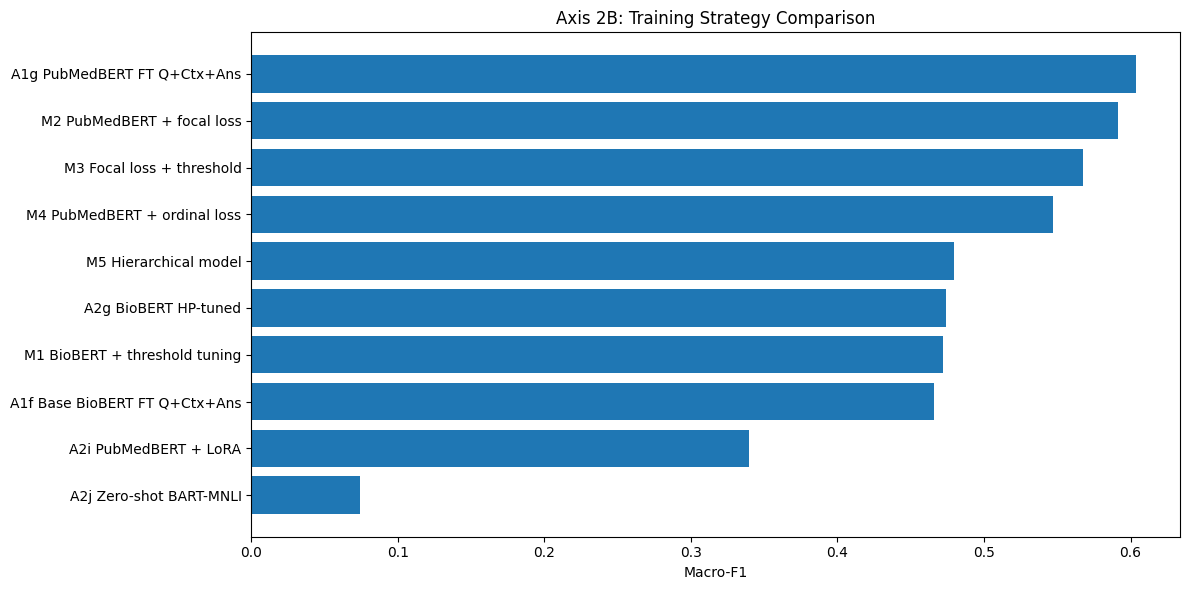

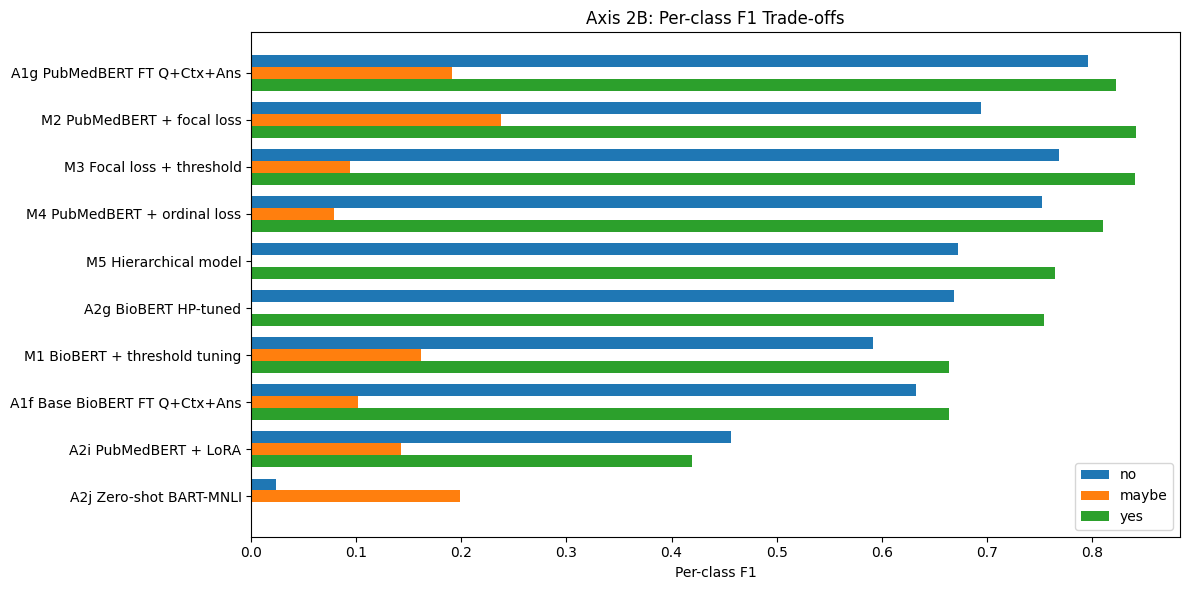

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# SECTION 11B — AXIS 2B TRAINING-STRATEGY / UNCERTAINTY COMPARISON

print("\n" + "=" * 70)
print("SECTION 11B — AXIS 2B COMPARISON: Training strategies and maybe-class recovery")
print("=" * 70)

intervention_rows = []

def add_axis2b_row(model_name, pred_key, group):
    if pred_key in all_preds:
        preds = np.array(all_preds[pred_key])
        if len(preds) != len(y_test_list):
            print(f"Skipping {model_name}: prediction length mismatch")
            return

        pc = f1_score(
            y_test_list,
            preds,
            average=None,
            labels=[0, 1, 2],
            zero_division=0
        )

        intervention_rows.append({
            "Group": group,
            "Model": model_name,
            "Accuracy": accuracy_score(y_test_list, preds),
            "Macro-F1": f1_score(y_test_list, preds, average="macro", zero_division=0),
            "F1_no": pc[0],
            "F1_maybe": pc[1],
            "F1_yes": pc[2],
            "Predicted_maybe": int(np.sum(preds == 1))
        })

add_axis2b_row("A1f Base BioBERT FT Q+Ctx+Ans", "A1f_BioBERT_QCA_FT", "Reference")
add_axis2b_row("A1g PubMedBERT FT Q+Ctx+Ans", "A1g_PubMedBERT_QCA_FT", "Reference")

add_axis2b_row("A2g BioBERT HP-tuned", "A2g_BioBERT_HP", "Hyperparameter search")
add_axis2b_row("M1 BioBERT + threshold tuning", "M1_BioBERT_QCA_Threshold", "Threshold")
add_axis2b_row("M2 PubMedBERT + focal loss", "M2_PubMedBERT_Focal", "Loss")
add_axis2b_row("M3 Focal loss + threshold", "M3_PubMedBERT_Focal_Threshold", "Loss + threshold")
add_axis2b_row("M4 PubMedBERT + ordinal loss", "M4_PubMedBERT_Ordinal", "Loss")
add_axis2b_row("A2i PubMedBERT + LoRA", "A2i_LoRA_PubMedBERT", "Parameter-efficient FT")
add_axis2b_row("A2j Zero-shot BART-MNLI", "A2j_ZeroShot_BART", "Zero-shot")
add_axis2b_row("M5 Hierarchical model", "M5_Hierarchical", "Hierarchical")

if intervention_rows:
    axis2b_df = pd.DataFrame(intervention_rows)
    axis2b_df = axis2b_df.sort_values(
        ["Macro-F1", "F1_maybe", "Accuracy"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    print("\nAxis 2B summary:")
    display(axis2b_df.round(4))

    best_overall = axis2b_df.loc[axis2b_df["Macro-F1"].idxmax()]
    best_maybe = axis2b_df.loc[axis2b_df["F1_maybe"].idxmax()]

    print("\nBest overall by Macro-F1:")
    print(f"  {best_overall['Model']} | Macro-F1={best_overall['Macro-F1']:.4f}")

    print("\nBest maybe-class recovery:")
    print(f"  {best_maybe['Model']} | Maybe-F1={best_maybe['F1_maybe']:.4f}")

    plt.figure(figsize=(12, 6))
    plt.barh(axis2b_df["Model"], axis2b_df["Macro-F1"])
    plt.xlabel("Macro-F1")
    plt.title("Axis 2B: Training Strategy Comparison")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "axis2b_training_strategy_macro_f1.png"), dpi=300, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(12, 6))
    y_pos = np.arange(len(axis2b_df))
    width = 0.25
    plt.barh(y_pos - width, axis2b_df["F1_no"], height=width, label="no")
    plt.barh(y_pos, axis2b_df["F1_maybe"], height=width, label="maybe")
    plt.barh(y_pos + width, axis2b_df["F1_yes"], height=width, label="yes")
    plt.yticks(y_pos, axis2b_df["Model"])
    plt.xlabel("Per-class F1")
    plt.title("Axis 2B: Per-class F1 Trade-offs")
    plt.legend()
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "axis2b_per_class_tradeoff.png"), dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No Axis 2B intervention results available yet.")


The Axis 2B comparison makes the final training-strategy trade-off visible. **A1g PubMedBERT** is best overall with **0.6035** macro-F1. **M2 focal loss** is slightly lower overall at **0.5912**, but it gives the best maybe-F1 at **0.2373**. **M3** has the highest accuracy, but its maybe recovery is much weaker.

This confirms that there is no single model that wins every metric. If the goal is best overall balance, A1g is the strongest choice. If the goal is to recover more uncertain cases, M2 is more attractive. The notebook therefore supports the report conclusion that medical QA evaluation must look beyond one headline score.


## Section 12 — TF-IDF features and learning curve


SECTION 12 — TF-IDF FEATURE IMPORTANCE (FROM A2a) AND LEARNING CURVE

Top TF-IDF features per class (from A2a tuned LR):


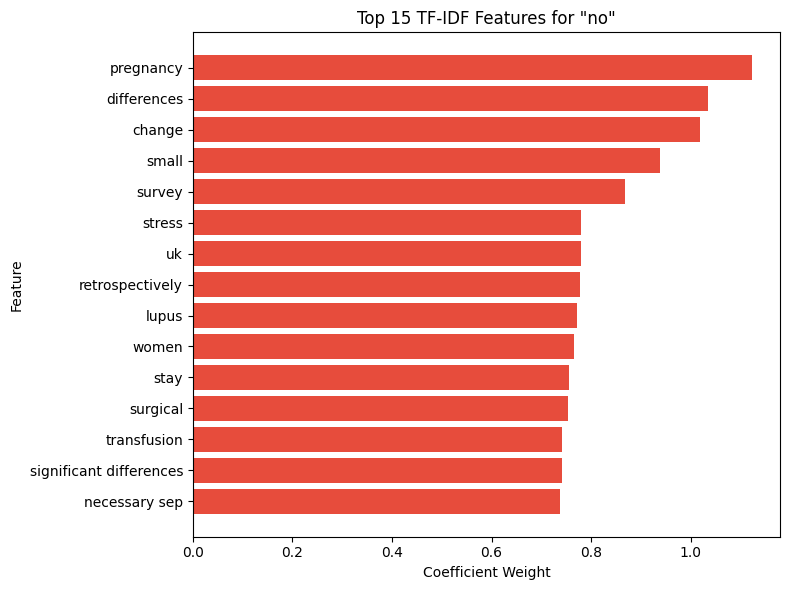

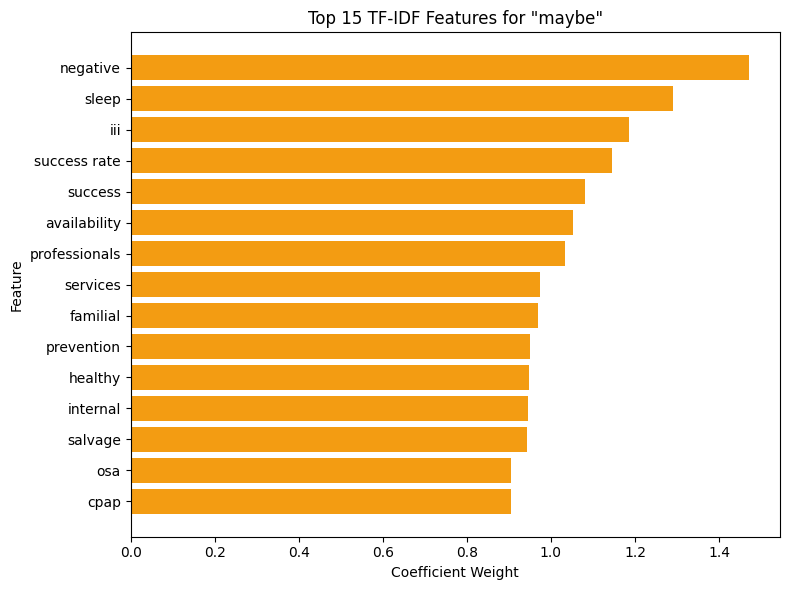

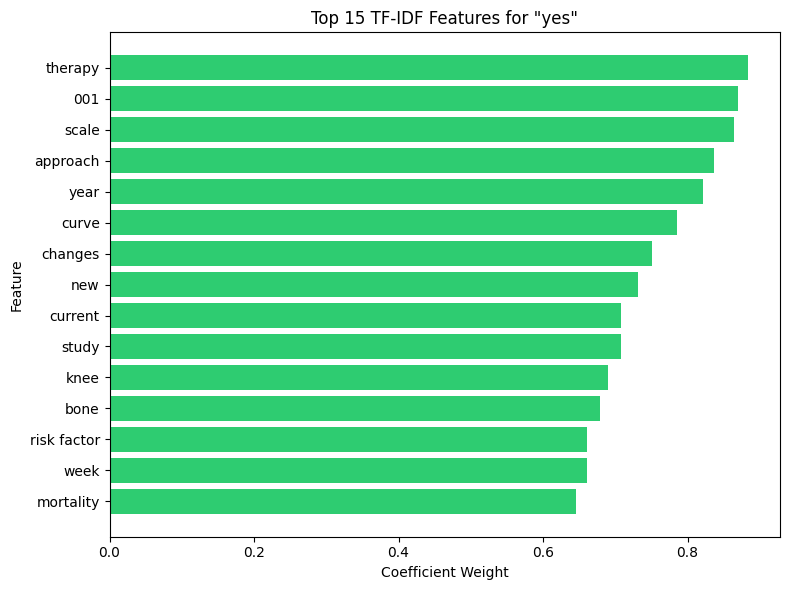


Feature-importance summary table created.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,class,feature,coefficient
0,no,necessary sep,0.737449
1,no,significant differences,0.742048
2,no,transfusion,0.742245
3,no,surgical,0.753699
4,no,stay,0.755205
5,no,women,0.765417
6,no,lupus,0.771910
7,no,retrospectively,0.777537
8,no,uk,0.779576
9,no,stress,0.779599



Computing learning curve for A2a tuned LR...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


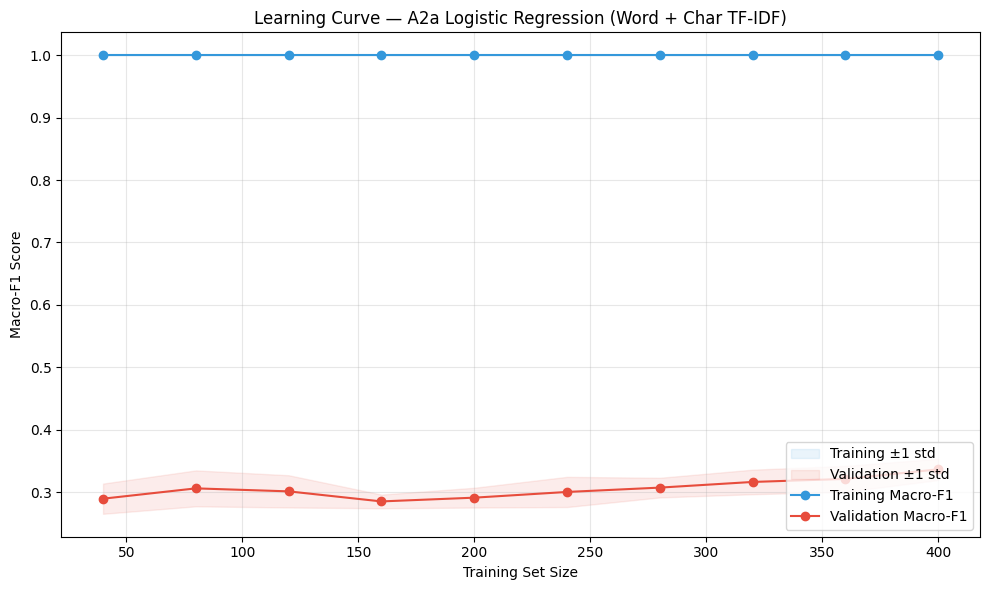


Final training Macro-F1   : 1.0000
Final validation Macro-F1 : 0.3365
Generalisation gap        : 0.6635

Learning-curve summary:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,train_size,train_mean,train_std,val_mean,val_std
0,40,1.0,0.0,0.2895,0.0242
1,80,1.0,0.0,0.3060,0.0288
2,120,1.0,0.0,0.3012,0.0258
3,160,1.0,0.0,0.2851,0.0110
4,200,1.0,0.0,0.2911,0.0158
5,240,1.0,0.0,0.3003,0.0242
6,280,1.0,0.0,0.3073,0.0157
7,320,1.0,0.0,0.3163,0.0197
8,360,1.0,0.0,0.3212,0.0208
9,400,1.0,0.0,0.3365,0.0170


In [ ]:
# SECTION 12 — TF-IDF FEATURE IMPORTANCE (FROM A2a) AND LEARNING CURVE


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, learning_curve
from sklearn.linear_model import LogisticRegression

print("SECTION 12 — TF-IDF FEATURE IMPORTANCE (FROM A2a) AND LEARNING CURVE")
print("=" * 75)

os.makedirs(save_dir, exist_ok=True)

best_lr_model = lr_final.best_estimator_

word_feature_names = word_vec_final.get_feature_names_out().tolist()
char_feature_names_raw = char_vec_final.get_feature_names_out().tolist()

char_feature_names = [
    f if str(f).startswith("char_") else f"char_{f}"
    for f in char_feature_names_raw
]

feature_names = np.array(word_feature_names + char_feature_names)

if len(feature_names) != best_lr_model.coef_.shape[1]:
    raise ValueError(
        f"Feature name count ({len(feature_names)}) does not match "
        f"model coefficient count ({best_lr_model.coef_.shape[1]})."
    )

print("\nTop TF-IDF features per class (from A2a tuned LR):")
print("=" * 60)

class_colors = {
    "no": "#e74c3c",
    "maybe": "#f39c12",
    "yes": "#2ecc71"
}

top_feature_rows = []

for cls_id, cls_name in sorted(id2label.items()):
    coefs = best_lr_model.coef_[cls_id]
    top_k = min(15, len(coefs))

    top_idx = np.argsort(coefs)[-top_k:]
    top_feats = feature_names[top_idx]
    top_vals = coefs[top_idx]

    order = np.argsort(top_vals)
    top_feats = top_feats[order]
    top_vals = top_vals[order]

    for feat, val in zip(top_feats, top_vals):
        top_feature_rows.append({
            "class": cls_name,
            "feature": feat,
            "coefficient": val
        })

    plt.figure(figsize=(8, 6))
    plt.barh(top_feats, top_vals, color=class_colors.get(cls_name, "#3498db"))
    plt.title(f'Top {top_k} TF-IDF Features for "{cls_name}"')
    plt.xlabel("Coefficient Weight")
    plt.ylabel("Feature")
    plt.tight_layout()

    out_path = os.path.join(save_dir, f"visualization_top_{top_k}_features_{cls_name}.png")
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

top_feature_df = pd.DataFrame(top_feature_rows)
print("\nFeature-importance summary table created.")
display(top_feature_df.head(20))

# Learning curve for A2a tuned Logistic Regression

print("\nComputing learning curve for A2a tuned LR...")
print("=" * 60)

cv5_lc = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_SEED
)

lr_for_lc = LogisticRegression(
    C=lr_final.best_params_["C"],
    max_iter=4000,
    class_weight="balanced",
    solver="liblinear",
    random_state=RANDOM_SEED
)

train_sizes, train_scores, val_scores = learning_curve(
    estimator=lr_for_lc,
    X=X_cv_wc,
    y=y_cv,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=cv5_lc,
    scoring="f1_macro",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.10,
    color="#3498db",
    label="Training ±1 std"
)
plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.10,
    color="#e74c3c",
    label="Validation ±1 std"
)
plt.plot(train_sizes, train_mean, "o-", color="#3498db", label="Training Macro-F1")
plt.plot(train_sizes, val_mean, "o-", color="#e74c3c", label="Validation Macro-F1")

plt.xlabel("Training Set Size")
plt.ylabel("Macro-F1 Score")
plt.title("Learning Curve — A2a Logistic Regression (Word + Char TF-IDF)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()

lc_path = os.path.join(save_dir, "Learning_Curve_Logistic_Regression.png")
plt.savefig(lc_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nFinal training Macro-F1   : {train_mean[-1]:.4f}")
print(f"Final validation Macro-F1 : {val_mean[-1]:.4f}")
print(f"Generalisation gap        : {train_mean[-1] - val_mean[-1]:.4f}")

lc_df = pd.DataFrame({
    "train_size": train_sizes,
    "train_mean": train_mean,
    "train_std": train_std,
    "val_mean": val_mean,
    "val_std": val_std
})

print("\nLearning-curve summary:")
display(lc_df.round(4))

The feature-importance plots show which words the tuned TF-IDF Logistic Regression model associates with each class. These features are interpretable, but they are still surface-level lexical cues. The learning curve is more important: training macro-F1 reaches **1.0000**, while validation macro-F1 remains around **0.3365**, leaving a large generalisation gap of **0.6635**.

This tells us that the sparse model can memorise the small training folds but cannot generalise well. The issue is not simply that the model has not seen enough examples in the same format. It is learning brittle lexical associations rather than deeper evidence sufficiency patterns.


## Section 13 — Unified results table and ablation summary


SECTION 13 — UNIFIED RESULTS TABLE

Unified results table:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Model,Accuracy,Macro-F1,F1_no,F1_maybe,F1_yes,Predicted_maybe
0,A1g_PubMedBERT_QCA_FT,0.754,0.6035,0.7966,0.1915,0.8225,39
1,M2_PubMedBERT_Focal,0.728,0.5912,0.6944,0.2373,0.8418,63
2,M3_PubMedBERT_Focal_Threshold,0.770,0.5675,0.7683,0.0938,0.8406,9
3,M4_PubMedBERT_Ordinal,0.734,0.5472,0.7521,0.0789,0.8106,21
4,M5_Hierarchical,0.690,0.4792,0.6723,0.0000,0.7653,0
5,A2g_BioBERT_HP,0.674,0.4743,0.6685,0.0000,0.7543,11
6,M1_BioBERT_QCA_Threshold,0.574,0.4723,0.5916,0.1613,0.6640,69
7,A1f_BioBERT_QCA_FT,0.606,0.4659,0.6323,0.1013,0.6640,24
8,A1c_Q_Ctx_Ans,0.518,0.3663,0.3779,0.0833,0.6377,17
9,A1a_Q_only,0.498,0.3602,0.3556,0.1013,0.6238,24



Best observed test-set score (descriptive only, not used for model selection):
  A1g_PubMedBERT_QCA_FT | Macro-F1=0.6035
Representative downstream analysis model: A1g_PubMedBERT_QCA_FT

Comparison of Overall Performance vs Maybe-Class Recovery


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Model,Accuracy,Macro-F1,Maybe F1
0,A1g_PubMedBERT_QCA_FT,0.754,0.6035,0.1915
1,M2_PubMedBERT_Focal,0.728,0.5912,0.2373
2,M3_PubMedBERT_Focal_Threshold,0.770,0.5675,0.0938
3,M4_PubMedBERT_Ordinal,0.734,0.5472,0.0789
4,M5_Hierarchical,0.690,0.4792,0.0000
5,A2g_BioBERT_HP,0.674,0.4743,0.0000
6,M1_BioBERT_QCA_Threshold,0.574,0.4723,0.1613
7,A1f_BioBERT_QCA_FT,0.606,0.4659,0.1013
8,A1c_Q_Ctx_Ans,0.518,0.3663,0.0833
9,A1a_Q_only,0.498,0.3602,0.1013


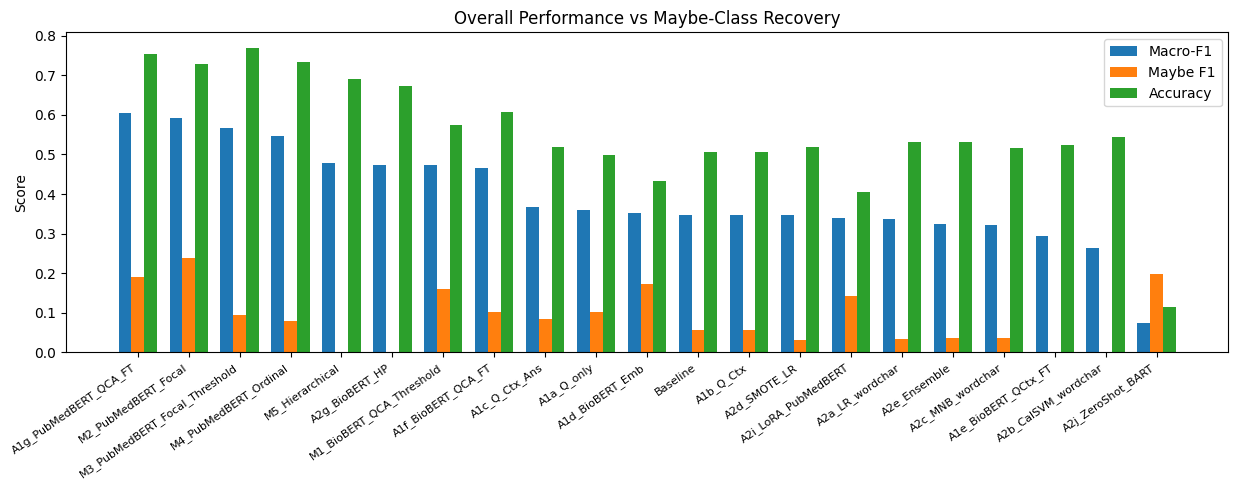


Ablation summary (structured by the final experiment story):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Display,Accuracy,Macro-F1,F1_maybe,F1_no,F1_yes,Predicted_maybe
0,Baseline TF-IDF+LR (Q+Ctx),0.506,0.3482,0.0571,0.3583,0.6292,15
1,A1a TF-IDF+LR (Q only),0.498,0.3602,0.1013,0.3556,0.6238,24
2,A1b TF-IDF+LR (Q+Ctx),0.506,0.3482,0.0571,0.3583,0.6292,15
3,A1c TF-IDF+LR (Q+Ctx+Ans),0.518,0.3663,0.0833,0.3779,0.6377,17
4,A1d BioBERT Embeddings+LR,0.432,0.3529,0.1719,0.3374,0.5495,73
5,A1e BioBERT FT (Q+Ctx),0.524,0.2935,0.0000,0.2092,0.6714,0
6,A1f BioBERT FT (Q+Ctx+Ans),0.606,0.4659,0.1013,0.6323,0.6640,24
7,A1g PubMedBERT FT (Q+Ctx+Ans),0.754,0.6035,0.1915,0.7966,0.8225,39
8,A2a Tuned LR word+char,0.532,0.3377,0.0345,0.3139,0.6647,3
9,A2b Cal-SVM + threshold,0.544,0.2642,0.0000,0.0933,0.6995,0



Delta vs Baseline:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Display,Δ Accuracy vs Baseline,Δ Macro-F1 vs Baseline,Δ Maybe F1 vs Baseline
0,Baseline TF-IDF+LR (Q+Ctx),0.000,0.0000,0.0000
1,A1a TF-IDF+LR (Q only),-0.008,0.0120,0.0441
2,A1b TF-IDF+LR (Q+Ctx),0.000,0.0000,0.0000
3,A1c TF-IDF+LR (Q+Ctx+Ans),0.012,0.0181,0.0262
4,A1d BioBERT Embeddings+LR,-0.074,0.0047,0.1147
5,A1e BioBERT FT (Q+Ctx),0.018,-0.0547,-0.0571
6,A1f BioBERT FT (Q+Ctx+Ans),0.100,0.1176,0.0441
7,A1g PubMedBERT FT (Q+Ctx+Ans),0.248,0.2553,0.1343
8,A2a Tuned LR word+char,0.026,-0.0105,-0.0227
9,A2b Cal-SVM + threshold,0.038,-0.0840,-0.0571



Saved:
  visualizations/section13_unified_results.csv
  visualizations/section13_ablation_summary.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# SECTION 13 — UNIFIED RESULTS TABLE AND ABLATION SUMMARY

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support
)

y_true = np.array(y_test_list if "y_test_list" in globals() else y_test)
save_dir = save_dir if "save_dir" in globals() else "visualizations"
os.makedirs(save_dir, exist_ok=True)

label_order = [0, 1, 2]
label_names = ["no", "maybe", "yes"]

def safe_display(df):
    try:
        display(df)
    except NameError:
        print(df.to_string(index=False))

alias_drop = {
    "A2f_BioBERT_FT": "A1f_BioBERT_QCA_FT",
    "A2h_PubMedBERT_FT": "A1g_PubMedBERT_QCA_FT",
    "M4_BioBERT_Ordinal": "M4_PubMedBERT_Ordinal"
}

def evaluate_prediction_dict(pred_dict, y_true):
    rows = []
    for name, preds in pred_dict.items():
        if name in alias_drop and alias_drop[name] in pred_dict:
            continue

        preds = np.array(preds)
        if len(preds) != len(y_true):
            print(f"Skipping {name}: prediction length {len(preds)} != y_true length {len(y_true)}")
            continue

        per_class = f1_score(
            y_true, preds,
            average=None,
            labels=label_order,
            zero_division=0
        )

        rows.append({
            "Model": name,
            "Accuracy": accuracy_score(y_true, preds),
            "Macro-F1": f1_score(y_true, preds, average="macro", zero_division=0),
            "F1_no": per_class[0],
            "F1_maybe": per_class[1],
            "F1_yes": per_class[2],
            "Predicted_maybe": int(np.sum(preds == 1))
        })

    return pd.DataFrame(rows)

print("=" * 75)
print("SECTION 13 — UNIFIED RESULTS TABLE")
print("=" * 75)

results_df = evaluate_prediction_dict(all_preds, y_true)

if results_df.empty:
    print("No prediction results available in all_preds.")
else:
    results_df = results_df.sort_values(
        ["Macro-F1", "F1_maybe", "Accuracy"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    print("\nUnified results table:")
    safe_display(results_df.round(4))

    descriptive_top_model_key = results_df.loc[0, "Model"]
    descriptive_top_macro_f1 = results_df.loc[0, "Macro-F1"]

    analysis_priority = [
        "A1g_PubMedBERT_QCA_FT",
        "A2g_BioBERT_HP",
        "A1f_BioBERT_QCA_FT",
        "M1_BioBERT_QCA_Threshold",
        "A2d_SMOTE_LR",
        "Baseline"
    ]

    analysis_model_key = next(
        (k for k in analysis_priority if k in results_df["Model"].values),
        descriptive_top_model_key
    )

    print("\nBest observed test-set score (descriptive only, not used for model selection):")
    print(f"  {descriptive_top_model_key} | Macro-F1={descriptive_top_macro_f1:.4f}")
    print(f"Representative downstream analysis model: {analysis_model_key}")

    comp_df = results_df[["Model", "Accuracy", "Macro-F1", "F1_maybe"]].copy()
    comp_df = comp_df.rename(columns={"F1_maybe": "Maybe F1"})

    print("\nComparison of Overall Performance vs Maybe-Class Recovery")
    print("=" * 65)
    safe_display(comp_df.round(4))

    fig, ax = plt.subplots(figsize=(max(10, len(comp_df) * 0.6), 5))
    x = np.arange(len(comp_df))
    width = 0.25

    ax.bar(x - width, comp_df["Macro-F1"].values, width, label="Macro-F1")
    ax.bar(x, comp_df["Maybe F1"].values, width, label="Maybe F1")
    ax.bar(x + width, comp_df["Accuracy"].values, width, label="Accuracy")

    ax.set_xticks(x)
    ax.set_xticklabels(comp_df["Model"], rotation=35, ha="right", fontsize=8)
    ax.set_ylabel("Score")
    ax.set_title("Overall Performance vs Maybe-Class Recovery")
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "performance_vs_maybe_tradeoff.png"), dpi=300, bbox_inches="tight")
    plt.show()

    model_display = {
        "Baseline": "Baseline TF-IDF+LR (Q+Ctx)",
        "A1a_Q_only": "A1a TF-IDF+LR (Q only)",
        "A1b_Q_Ctx": "A1b TF-IDF+LR (Q+Ctx)",
        "A1c_Q_Ctx_Ans": "A1c TF-IDF+LR (Q+Ctx+Ans)",
        "A1d_BioBERT_Emb": "A1d BioBERT Embeddings+LR",
        "A1e_BioBERT_QCtx_FT": "A1e BioBERT FT (Q+Ctx)",
        "A1f_BioBERT_QCA_FT": "A1f BioBERT FT (Q+Ctx+Ans)",
        "A1g_PubMedBERT_QCA_FT": "A1g PubMedBERT FT (Q+Ctx+Ans)",
        "A2a_LR_wordchar": "A2a Tuned LR word+char",
        "A2b_CalSVM_wordchar": "A2b Cal-SVM + threshold",
        "A2c_MNB_wordchar": "A2c Multinomial NB",
        "A2d_SMOTE_LR": "A2d SMOTE + LR",
        "A2e_Ensemble": "A2e Soft-voting ensemble",
        "A2g_BioBERT_HP": "A2g BioBERT HP-tuned",
        "A2i_LoRA_PubMedBERT": "A2i PubMedBERT LoRA",
        "A2j_ZeroShot_BART": "A2j Zero-shot BART-MNLI",
        "M1_BioBERT_QCA_Threshold": "M1 BioBERT + threshold",
        "M2_PubMedBERT_Focal": "M2 PubMedBERT focal loss",
        "M3_PubMedBERT_Focal_Threshold": "M3 focal + threshold",
        "M4_PubMedBERT_Ordinal": "M4 PubMedBERT ordinal loss",
        "M5_Hierarchical": "M5 Hierarchical"
    }

    ablation_order = [k for k in model_display if k in results_df["Model"].values]
    ablation_df = results_df.set_index("Model").loc[ablation_order].reset_index()
    ablation_df["Display"] = ablation_df["Model"].map(model_display)

    keep_cols = ["Display", "Accuracy", "Macro-F1", "F1_maybe", "F1_no", "F1_yes", "Predicted_maybe"]
    print("\nAblation summary (structured by the final experiment story):")
    safe_display(ablation_df[keep_cols].round(4))

    if "Baseline" in results_df["Model"].values:
        baseline_row = results_df.loc[results_df["Model"] == "Baseline"].iloc[0]
        delta_df = ablation_df[["Display", "Accuracy", "Macro-F1", "F1_maybe"]].copy()
        delta_df["Δ Accuracy vs Baseline"] = delta_df["Accuracy"] - baseline_row["Accuracy"]
        delta_df["Δ Macro-F1 vs Baseline"] = delta_df["Macro-F1"] - baseline_row["Macro-F1"]
        delta_df["Δ Maybe F1 vs Baseline"] = delta_df["F1_maybe"] - baseline_row["F1_maybe"]

        print("\nDelta vs Baseline:")
        safe_display(delta_df[[
            "Display",
            "Δ Accuracy vs Baseline",
            "Δ Macro-F1 vs Baseline",
            "Δ Maybe F1 vs Baseline"
        ]].round(4))

    results_df.to_csv(os.path.join(save_dir, "section13_unified_results.csv"), index=False)
    ablation_df[keep_cols].to_csv(os.path.join(save_dir, "section13_ablation_summary.csv"), index=False)
    print("\nSaved:")
    print(f"  {os.path.join(save_dir, 'section13_unified_results.csv')}")
    print(f"  {os.path.join(save_dir, 'section13_ablation_summary.csv')}")


The unified table is the clearest final ranking of the notebook. The top model is **A1g PubMedBERT Q+Ctx+Ans**, with **0.6035** macro-F1 and **0.754** accuracy. M2 focal loss is close behind with **0.5912** macro-F1 and the strongest maybe-F1. The lower half of the table is dominated by sparse models, LoRA, and zero-shot BART.

The ablation view explains where the gains come from. TF-IDF input variants stay close together, BioBERT Q+Ctx+Ans gives a meaningful lift, and PubMedBERT gives the largest final jump. This directly supports the report’s two-axis story: input representation matters, but it matters most when paired with a model that can actually use the added evidence.


## Section 14 — Error analysis


Representative analysis model: A1g_PubMedBERT_QCA_FT


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Model,Accuracy,Macro-F1,F1_no,F1_maybe,F1_yes,Predicted_maybe
0,A1g_PubMedBERT_QCA_FT,0.754,0.603521,0.796610,0.191489,0.822464,39
1,M2_PubMedBERT_Focal,0.728,0.591161,0.694444,0.237288,0.841751,63
2,M3_PubMedBERT_Focal_Threshold,0.770,0.567528,0.768254,0.093750,0.840580,9
3,M4_PubMedBERT_Ordinal,0.734,0.547219,0.752089,0.078947,0.810619,21
4,M5_Hierarchical,0.690,0.479192,0.672269,0.000000,0.765306,0


              precision    recall  f1-score   support

          no       0.76      0.83      0.80       169
       maybe       0.23      0.16      0.19        55
         yes       0.82      0.82      0.82       276

    accuracy                           0.75       500
   macro avg       0.61      0.61      0.60       500
weighted avg       0.74      0.75      0.74       500

Error analysis dataset: (500, 20)
Overall accuracy: 0.7540

True label counts:
true_label
yes      276
no       169
maybe     55
Name: count, dtype: int64

Predicted label counts:
pred_label
yes      276
no       185
maybe     39
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


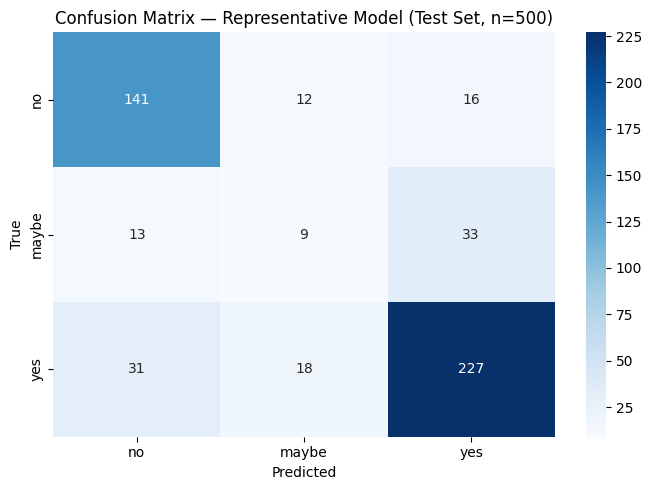

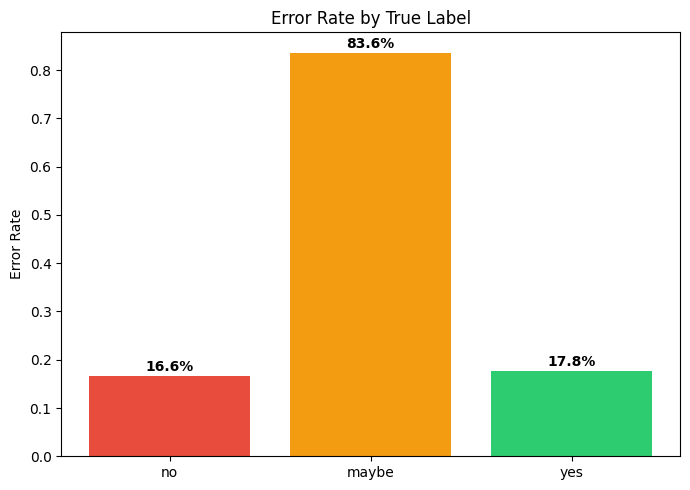

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


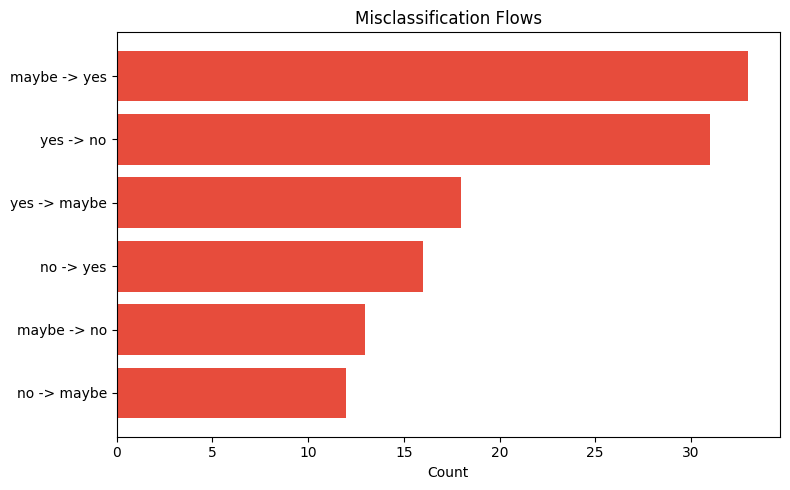


McNemar's Test for Statistical Significance
  Baseline vs A1g_PubMedBERT_QCA_FT:
    Discordant counts: b=164, c=40, p=0.0000 — Significant (p<0.05)

QUALITATIVE ERROR ANALYSIS — Representative Misclassified Examples

Pattern: Yes->No: Reversed clinical conclusion (31 examples)
  PMID: 23831910
  Question: Double balloon enteroscopy: is it efficacious and safe in a community setting?
  Context snippet: From March 2007 to January 2011, 88 DBE procedures were performed on 66 patients. Indications included evaluation anemia/gastrointestinal bleed, small bowel IBD and dilation of strictures. Video-capsule endoscopy (VCE) was used prior to DBE in 43 of the 66 patients prior to DBE evaluation. The mean 
  True: yes | Predicted: no
  Hedging: 0, Evidence strength: 0


Pattern: No->Yes: Reversed clinical conclusion (16 examples)
  PMID: 17208539
  Question: Are the long-term results of the transanal pull-through equal to those of the transabdominal pull-through?
  Context snippet: The transan

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


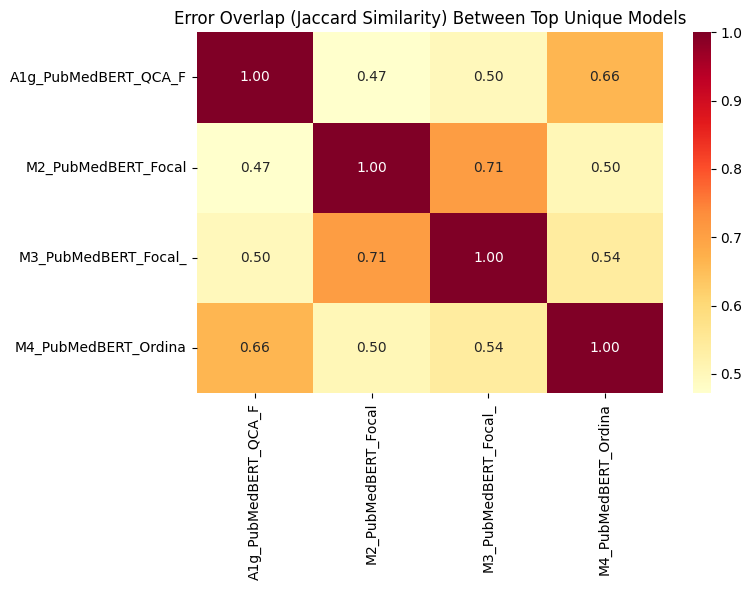


Samples ALL top-4 unique models get wrong: 66 / 500 (13.2%)
These are the hardest examples that no top model handles well.


Batches:   0%|          | 0/16 [00:00<?, ?it/s]


Cluster-Based Error Analysis


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,cluster,samples,macro_f1,maybe_f1,maybe_count
0,0,153,0.6241,0.1600,16
1,1,105,0.5891,0.2308,15
2,2,100,0.6298,0.2500,15
3,3,142,0.5442,0.1053,9


In [ ]:
# SECTION 14 — ERROR ANALYSIS, McNEMAR TEST, ERROR OVERLAP, CLUSTERS

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except Exception:
    sns = None

from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score

os.makedirs(save_dir, exist_ok=True)

y_true = np.array(y_test_list if "y_test_list" in globals() else y_test)
id_col = "pmid"

def safe_display(df):
    try:
        display(df)
    except NameError:
        print(df.to_string(index=False))

if "results_df" in globals() and len(results_df) > 0:
    selection_df = results_df.sort_values(
        ["Macro-F1", "F1_maybe", "Accuracy"],
        ascending=[False, False, False]
    ).reset_index(drop=True)
else:
    tmp_rows = []
    for name, preds in all_preds.items():
        preds = np.array(preds)
        if len(preds) != len(y_true):
            continue
        per_class = f1_score(
            y_true, preds,
            average=None,
            labels=[0, 1, 2],
            zero_division=0
        )
        tmp_rows.append({
            "Model": name,
            "Accuracy": accuracy_score(y_true, preds),
            "Macro-F1": f1_score(y_true, preds, average="macro", zero_division=0),
            "F1_no": per_class[0],
            "F1_maybe": per_class[1],
            "F1_yes": per_class[2]
        })
    selection_df = pd.DataFrame(tmp_rows).sort_values(
        ["Macro-F1", "F1_maybe", "Accuracy"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

if selection_df.empty:
    raise ValueError("No valid predictions found in all_preds for Section 14.")

best_pred_key = analysis_model_key if "analysis_model_key" in globals() else selection_df.loc[0, "Model"]
pred_best = np.array(all_preds[best_pred_key])

print(f"Representative analysis model: {best_pred_key}")
safe_display(selection_df.head(5))

print(classification_report(
    y_true,
    pred_best,
    labels=[0, 1, 2],
    target_names=["no", "maybe", "yes"],
    zero_division=0
))

error_data = {
    "text": list(X_test_qctx) if "X_test_qctx" in globals() else [""] * len(y_true),
    "true_id": list(y_true),
    "pred_id": list(pred_best)
}
if "pmid_test" in globals():
    error_data[id_col] = list(pmid_test)

error_df = pd.DataFrame(error_data)
error_df["true_label"] = error_df["true_id"].map(id2label)
error_df["pred_label"] = error_df["pred_id"].map(id2label)
error_df["correct"] = (error_df["true_id"] == error_df["pred_id"]).astype(int)

feature_cols = [
    "question", "context", "long_answer",
    "question_len", "context_len", "num_contexts",
    "has_negation", "has_causal", "has_comparison", "has_association",
    "has_risk", "context_evidence_strength", "context_hedging"
]

existing_feature_cols = [c for c in feature_cols if c in df_model.columns]

if id_col in error_df.columns and id_col in df_model.columns:
    merge_cols = [id_col] + existing_feature_cols
    error_df = error_df.merge(df_model[merge_cols], on=id_col, how="left")
elif "test_df" in globals():
    extra_cols = [c for c in existing_feature_cols if c in test_df.columns]
    if len(extra_cols) > 0:
        error_df = pd.concat(
            [error_df.reset_index(drop=True), test_df[extra_cols].reset_index(drop=True)],
            axis=1
        )

print(f"Error analysis dataset: {error_df.shape}")
print(f"Overall accuracy: {error_df['correct'].mean():.4f}")

print("\nTrue label counts:")
print(error_df["true_label"].value_counts())
print("\nPredicted label counts:")
print(error_df["pred_label"].value_counts())

cm = confusion_matrix(error_df["true_id"], error_df["pred_id"], labels=[0, 1, 2])

plt.figure(figsize=(7, 5))
if sns is not None:
    sns.heatmap(
        cm, annot=True, fmt="d",
        xticklabels=["no", "maybe", "yes"],
        yticklabels=["no", "maybe", "yes"],
        cmap="Blues"
    )
else:
    plt.imshow(cm, cmap="Blues")
    plt.xticks([0, 1, 2], ["no", "maybe", "yes"])
    plt.yticks([0, 1, 2], ["no", "maybe", "yes"])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")
plt.title("Confusion Matrix — Representative Model (Test Set, n=500)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_error_confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

class_error = (
    error_df.groupby("true_label")["correct"]
    .apply(lambda x: 1 - x.mean())
    .reindex(["no", "maybe", "yes"])
)

plt.figure(figsize=(7, 5))
plt.bar(class_error.index, class_error.values, color=["#e74c3c", "#f39c12", "#2ecc71"])
plt.title("Error Rate by True Label")
plt.ylabel("Error Rate")
for i, (lab, val) in enumerate(zip(class_error.index, class_error.values)):
    plt.text(i, val + 0.01, f"{val:.1%}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_error_rate_by_true_label.png"), dpi=300, bbox_inches="tight")
plt.show()

error_flow = (
    error_df[error_df["correct"] == 0]
    .groupby(["true_label", "pred_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=True)
)

if len(error_flow) > 0:
    flow_labels = [f"{r['true_label']} -> {r['pred_label']}" for _, r in error_flow.iterrows()]

    plt.figure(figsize=(8, 5))
    plt.barh(flow_labels, error_flow["count"], color="#e74c3c")
    plt.title("Misclassification Flows")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "visualization_misclassification_flows.png"), dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No misclassification flows to display.")

def mcnemar_test(y_true_arr, preds_a, preds_b, name_a="A", name_b="B"):
    preds_a = np.array(preds_a)
    preds_b = np.array(preds_b)

    correct_a = (preds_a == y_true_arr)
    correct_b = (preds_b == y_true_arr)

    b = np.sum(~correct_a & correct_b)
    c = np.sum(correct_a & ~correct_b)

    if b + c == 0:
        print(f"  {name_a} vs {name_b}: identical correctness pattern")
        return None

    statistic = (abs(b - c) - 1) ** 2 / (b + c)
    p_value = 1 - chi2.cdf(statistic, df=1)
    sig = "Significant (p<0.05)" if p_value < 0.05 else "NOT significant (p>=0.05)"

    print(f"  {name_a} vs {name_b}:")
    print(f"    Discordant counts: b={b}, c={c}, p={p_value:.4f} — {sig}")
    return p_value

print("\nMcNemar's Test for Statistical Significance")
print("=" * 60)
if "Baseline" in all_preds:
    baseline_preds = np.array(all_preds["Baseline"])
    mcnemar_test(y_true, baseline_preds, pred_best, "Baseline", best_pred_key)
else:
    print("Baseline predictions not available; skipping McNemar test.")

print("\n" + "=" * 80)
print("QUALITATIVE ERROR ANALYSIS — Representative Misclassified Examples")
print("=" * 80)

error_examples = error_df[error_df["correct"] == 0].copy()

confusion_patterns = [
    ("yes", "no", "Yes->No: Reversed clinical conclusion"),
    ("no", "yes", "No->Yes: Reversed clinical conclusion"),
    ("maybe", "yes", "Maybe->Yes: Missed hedging/uncertainty"),
    ("maybe", "no", "Maybe->No: Missed hedging/uncertainty"),
    ("yes", "maybe", "Yes->Maybe: Overcautious prediction"),
    ("no", "maybe", "No->Maybe: Overcautious prediction")
]

for true_lab, pred_lab, pattern_name in confusion_patterns:
    subset = error_examples[
        (error_examples["true_label"] == true_lab) &
        (error_examples["pred_label"] == pred_lab)
    ]

    if len(subset) == 0:
        continue

    print(f"\n{'=' * 70}")
    print(f"Pattern: {pattern_name} ({len(subset)} examples)")
    print(f"{'=' * 70}")

    sample = subset.iloc[0]
    q_text = str(sample.get("question", sample.get("text", "")))[:200]
    context_text = str(sample.get("context", ""))[:300]

    print(f"  PMID: {sample.get(id_col, 'N/A')}")
    print(f"  Question: {q_text}")
    print(f"  Context snippet: {context_text}")
    print(f"  True: {true_lab} | Predicted: {pred_lab}")

    if "context_hedging" in sample.index and "context_evidence_strength" in sample.index:
        print(
            f"  Hedging: {sample['context_hedging']}, "
            f"Evidence strength: {sample['context_evidence_strength']}"
        )
    print()

print("\nError Overlap Analysis")
print("=" * 60)

ranked_models = selection_df["Model"].tolist()
unique_model_names = []
seen_signatures = set()

for name in ranked_models:
    preds = np.array(all_preds[name])
    signature = tuple(preds.tolist())
    if signature not in seen_signatures:
        seen_signatures.add(signature)
        unique_model_names.append(name)
    if len(unique_model_names) == 4:
        break

key_models = {}
for name in unique_model_names:
    key_models[name] = (np.array(all_preds[name]) != y_true)

model_names = list(key_models.keys())
error_masks = list(key_models.values())

print("\nPairwise error overlap (Jaccard similarity on error sets):")
overlap_matrix = np.zeros((len(model_names), len(model_names)))

for i in range(len(model_names)):
    for j in range(len(model_names)):
        shared = np.sum(error_masks[i] & error_masks[j])
        total = np.sum(error_masks[i] | error_masks[j])
        overlap_matrix[i, j] = shared / total if total > 0 else 0.0

fig, ax = plt.subplots(figsize=(8, 6))
if sns is not None:
    sns.heatmap(
        overlap_matrix,
        annot=True,
        fmt=".2f",
        xticklabels=[n[:20] for n in model_names],
        yticklabels=[n[:20] for n in model_names],
        cmap="YlOrRd",
        ax=ax
    )
else:
    im = ax.imshow(overlap_matrix, cmap="YlOrRd")
    ax.set_xticks(np.arange(len(model_names)))
    ax.set_yticks(np.arange(len(model_names)))
    ax.set_xticklabels([n[:20] for n in model_names], rotation=45, ha="right")
    ax.set_yticklabels([n[:20] for n in model_names])
    for i in range(overlap_matrix.shape[0]):
        for j in range(overlap_matrix.shape[1]):
            ax.text(j, i, f"{overlap_matrix[i, j]:.2f}", ha="center", va="center")
    plt.colorbar(im, ax=ax)

ax.set_title("Error Overlap (Jaccard Similarity) Between Top Unique Models")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "error_overlap_jaccard_heatmap.png"), dpi=300, bbox_inches="tight")
plt.show()

if len(error_masks) > 0:
    all_wrong = np.ones(len(y_true), dtype=bool)
    for mask in error_masks:
        all_wrong &= mask
    print(f"\nSamples ALL top-{len(error_masks)} unique models get wrong: {all_wrong.sum()} / {len(y_true)} "
          f"({all_wrong.sum()/len(y_true)*100:.1f}%)")
    print("These are the hardest examples that no top model handles well.")

test_embeddings_local = None

if "test_embeddings" in globals() and test_embeddings is not None:
    test_embeddings_local = test_embeddings
elif "embedder" in globals() and embedder is not None:
    try:
        test_embeddings_local = embedder.encode(X_test_qctx, show_progress_bar=True, batch_size=32)
    except Exception:
        test_embeddings_local = None

if test_embeddings_local is not None:
    kmeans = KMeans(n_clusters=4, random_state=RANDOM_SEED, n_init=10)
    test_clusters = kmeans.fit_predict(test_embeddings_local)

    cluster_rows = []
    pred_best_arr = np.array(pred_best)

    for c in sorted(set(test_clusters)):
        idx = (test_clusters == c)

        macro = f1_score(
            y_true[idx],
            pred_best_arr[idx],
            average="macro",
            zero_division=0
        )

        maybe_f1_c = f1_score(
            y_true[idx],
            pred_best_arr[idx],
            labels=[1],
            average="macro",
            zero_division=0
        )

        cluster_rows.append({
            "cluster": int(c),
            "samples": int(idx.sum()),
            "macro_f1": round(macro, 4),
            "maybe_f1": round(maybe_f1_c, 4),
            "maybe_count": int(np.sum(y_true[idx] == 1))
        })

    cluster_df = pd.DataFrame(cluster_rows)

    print("\nCluster-Based Error Analysis")
    print("=" * 60)
    safe_display(cluster_df)
else:
    print("\nSkipping cluster analysis (embeddings not available)")

The error analysis uses A1g as the representative model because it is the strongest overall. McNemar’s test against the baseline gives **b = 164**, **c = 40**, and **p = 0.0000**, so the improvement is statistically significant on the paired test set.

The confusion patterns still show the main weakness. The best model predicts many yes and no cases correctly, but true maybe examples are often forced into yes or no. The shared-error analysis also finds **66 examples** that all top models get wrong, which suggests there is a hard subset not solved by simply changing the loss. The cluster analysis supports this: performance varies by semantic region, with macro-F1 ranging from **0.5442** to **0.6298** and maybe-F1 from **0.1053** to **0.2500** across clusters.


## Section 15 — Quality predictor, export, and reproducibility


SECTION 15 — QUALITY PREDICTOR, PREDICTIONS EXPORT, REPRODUCIBILITY

Quality predictor target model: Baseline
Rationale: CV correctness labels are generated with the same baseline pipeline, so train/test targets stay consistent.
Available quality features (10): ['question_len', 'context_len', 'num_contexts', 'has_negation', 'has_causal', 'has_comparison', 'has_association', 'has_risk', 'context_evidence_strength', 'context_hedging']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.


Quality predictor training samples: 500
  Correct   : 258
  Incorrect : 242
Quality predictor test samples: 500
  Correct   : 253
  Incorrect : 247

Quality predictor results:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


RF Quality Predictor
  Test Accuracy : 0.5160
  Test Macro-F1 : 0.5158
              precision    recall  f1-score   support

   incorrect       0.51      0.50      0.51       247
     correct       0.52      0.53      0.53       253

    accuracy                           0.52       500
   macro avg       0.52      0.52      0.52       500
weighted avg       0.52      0.52      0.52       500


MLP Quality Predictor
  Test Accuracy : 0.4860
  Test Macro-F1 : 0.4802
              precision    recall  f1-score   support

   incorrect       0.47      0.38      0.43       247
     correct       0.49      0.58      0.54       253

    accuracy                           0.49       500
   macro avg       0.48      0.48      0.48       500
weighted avg       0.48      0.49      0.48       500


LR Quality Predictor
  Test Accuracy : 0.5380
  Test Macro-F1 : 0.5377
              precision    recall  f1-score   support

   incorrect       0.53      0.57      0.55       247
     correct       0

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Model,Target model,Test Accuracy,Test Macro-F1
0,LR,Baseline,0.538,0.5377
1,RF,Baseline,0.516,0.5158
2,MLP,Baseline,0.486,0.4802



Quality predictor feature importance:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Feature,Importance
0,context_len,0.438551
1,question_len,0.289998
2,num_contexts,0.089225
3,context_evidence_strength,0.046570
4,context_hedging,0.037973
5,has_causal,0.029914
6,has_association,0.025342
7,has_risk,0.025265
8,has_comparison,0.015140
9,has_negation,0.002022


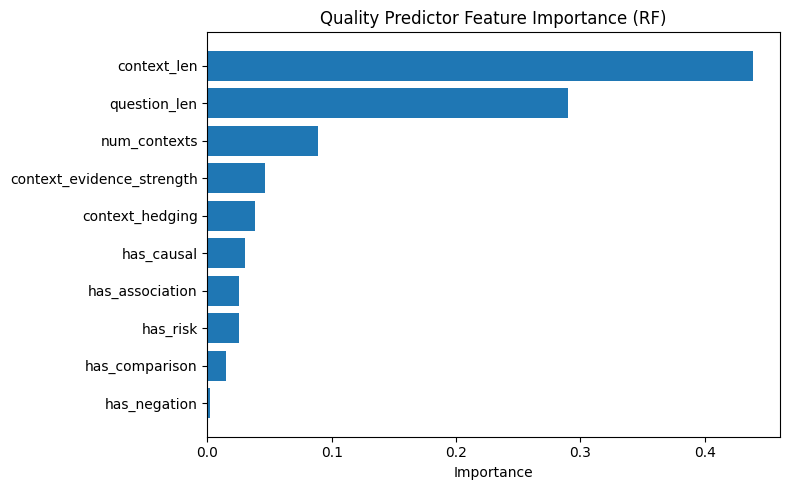


PREDICTIONS EXPORT
Export model: A1g_PubMedBERT_QCA_FT
Saved predictions.json to: visualizations/predictions.json
Number of predictions saved: 500
First 5 predictions:
{'21645374': 'yes', '9488747': 'yes', '17208539': 'yes', '23831910': 'no', '26037986': 'yes'}

REPRODUCIBILITY SUMMARY
Random seed: 42
Split seed: 42
Data split: custom stratified split used in this notebook
  500 held-out test + 500 CV (10-fold stratified)
CV strategy: 10-fold stratified
Transformer dev split: fold 0 of CV set (~50 samples)
Test set: used once for final reporting after validation-based choices; descriptive test ranking is not used for model selection

Software versions:
  Python: 3.12.13
  scikit-learn: 1.6.1
  scipy: 1.16.3
  numpy: 2.0.2
  pandas: 2.2.2
  transformers: 5.0.0
  torch: 2.10.0+cu128
  CUDA available: True
  GPU: Tesla T4

Key hyperparameters:
  TF-IDF: unigrams+bigrams, max 30k features, English stop words
  BioBERT model: dmis-lab/biobert-base-cased-v1.2
  PubMedBERT model: microsoft/B

In [ ]:
# SECTION 15 — QUALITY PREDICTOR, PREDICTIONS EXPORT, REPRODUCIBILITY

import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
import scipy
try:
    import transformers
except Exception:
    transformers = None

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report

os.makedirs(save_dir, exist_ok=True)

print("=" * 75)
print("SECTION 15 — QUALITY PREDICTOR, PREDICTIONS EXPORT, REPRODUCIBILITY")
print("=" * 75)

# PART A — QUALITY PREDICTOR

quality_priority = ["Baseline"]
quality_target_key = "Baseline"

if quality_target_key not in all_preds:
    raise KeyError(f"{quality_target_key} not found in all_preds")

print(f"\nQuality predictor target model: {quality_target_key}")
print("Rationale: CV correctness labels are generated with the same baseline pipeline, so train/test targets stay consistent.")

quality_features = [
    "question_len", "context_len", "num_contexts",
    "has_negation", "has_causal", "has_comparison", "has_association",
    "has_risk", "context_evidence_strength", "context_hedging"
]

available_quality_features = [
    c for c in quality_features
    if c in cv_df.columns and c in error_df.columns
]

missing_quality_features = [c for c in quality_features if c not in available_quality_features]

print(f"Available quality features ({len(available_quality_features)}): {available_quality_features}")
if missing_quality_features:
    print(f"Missing quality features ignored: {missing_quality_features}")

if len(available_quality_features) == 0:
    raise ValueError("No quality features are available in both cv_df and error_df.")

test_correct = (np.array(all_preds[quality_target_key]) == np.array(y_test)).astype(int)

X_qual_test = error_df[available_quality_features].fillna(0).values
y_qual_test = test_correct

cv_correct_labels = np.zeros(len(cv_df), dtype=int)
X_qual_train = cv_df[available_quality_features].fillna(0).values

for fold_idx in sorted(cv_df["fold"].unique()):
    val_mask = cv_df["fold"] == fold_idx
    train_mask = ~val_mask

    X_tr = cv_df.loc[train_mask, "q_ctx"].tolist()
    y_tr = cv_df.loc[train_mask, "label_id"].values

    X_va = cv_df.loc[val_mask, "q_ctx"].tolist()
    y_va = cv_df.loc[val_mask, "label_id"].values

    pipe = make_baseline_pipe()
    pipe.fit(X_tr, y_tr)
    val_preds = pipe.predict(X_va)

    cv_correct_labels[val_mask] = (val_preds == y_va).astype(int)

y_qual_train = cv_correct_labels.astype(int)

print(f"\nQuality predictor training samples: {len(y_qual_train)}")
print(f"  Correct   : {int(y_qual_train.sum())}")
print(f"  Incorrect : {int((1 - y_qual_train).sum())}")

print(f"Quality predictor test samples: {len(y_qual_test)}")
print(f"  Correct   : {int(y_qual_test.sum())}")
print(f"  Incorrect : {int((1 - y_qual_test).sum())}")

quality_models = {
    "RF": RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_SEED,
        n_jobs=-1
    ),
    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            max_iter=500,
            early_stopping=True,
            validation_fraction=0.15,
            random_state=RANDOM_SEED
        ))
    ]),
    "LR": Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_SEED
        ))
    ])
}

quality_rows = []

print("\nQuality predictor results:")
print("=" * 60)

for name, model in quality_models.items():
    model.fit(X_qual_train, y_qual_train)
    pred = model.predict(X_qual_test)

    acc = accuracy_score(y_qual_test, pred)
    macro_f1 = f1_score(y_qual_test, pred, average="macro", zero_division=0)

    print(f"\n{name} Quality Predictor")
    print(f"  Test Accuracy : {acc:.4f}")
    print(f"  Test Macro-F1 : {macro_f1:.4f}")
    print(classification_report(
        y_qual_test, pred,
        target_names=["incorrect", "correct"],
        zero_division=0
    ))

    quality_rows.append({
        "Model": name,
        "Target model": quality_target_key,
        "Test Accuracy": round(acc, 4),
        "Test Macro-F1": round(macro_f1, 4)
    })

quality_results_df = pd.DataFrame(quality_rows).sort_values(
    ["Test Macro-F1", "Test Accuracy"], ascending=False
).reset_index(drop=True)

print("\nQuality predictor summary:")
display(quality_results_df)

rf_qual = quality_models["RF"]
rf_qual.fit(X_qual_train, y_qual_train)

feat_imp = pd.DataFrame({
    "Feature": available_quality_features,
    "Importance": rf_qual.feature_importances_
}).sort_values("Importance", ascending=True)

print("\nQuality predictor feature importance:")
display(feat_imp.sort_values("Importance", ascending=False).reset_index(drop=True))

plt.figure(figsize=(8, 5))
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.title("Quality Predictor Feature Importance (RF)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(
    os.path.join(save_dir, "Quality_Predictor_Feature_Importance.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# PART B — PREDICTIONS EXPORT

print("\n" + "=" * 60)
print("PREDICTIONS EXPORT")
print("=" * 60)

export_model_key = analysis_model_key if "analysis_model_key" in globals() else None

if export_model_key is None:
    fallback_priority = [
        "A1g_PubMedBERT_QCA_FT",
        "A2g_BioBERT_HP",
        "A1f_BioBERT_QCA_FT",
        "M1_BioBERT_QCA_Threshold",
        "A2d_SMOTE_LR",
        "Baseline"
    ]
    export_model_key = next((k for k in fallback_priority if k in all_preds), None)

if export_model_key is None:
    raise ValueError("No valid export model found in all_preds.")

if export_model_key not in all_preds:
    raise KeyError(f"{export_model_key} not found in all_preds")

final_preds = np.array(all_preds[export_model_key])

if len(final_preds) != len(pmid_test):
    raise ValueError(
        f"Length mismatch: len(final_preds)={len(final_preds)} vs len(pmid_test)={len(pmid_test)}"
    )

predictions_json = {
    str(pmid): id2label[int(pred)]
    for pmid, pred in zip(pmid_test, final_preds)
}

predictions_path = os.path.join(save_dir, "predictions.json")
with open(predictions_path, "w", encoding="utf-8") as f:
    json.dump(predictions_json, f, indent=4)

print(f"Export model: {export_model_key}")
print(f"Saved predictions.json to: {predictions_path}")
print(f"Number of predictions saved: {len(predictions_json)}")
print("First 5 predictions:")
print(dict(list(predictions_json.items())[:5]))

# PART C — REPRODUCIBILITY SUMMARY

print("\n" + "=" * 60)
print("REPRODUCIBILITY SUMMARY")
print("=" * 60)

import sklearn
import scipy

print(f"Random seed: {RANDOM_SEED}")
print(f"Split seed: {RANDOM_SEED}")
print("Data split: custom stratified split used in this notebook")
print("  500 held-out test + 500 CV (10-fold stratified)")
print("CV strategy: 10-fold stratified")
print("Transformer dev split: fold 0 of CV set (~50 samples)")
print("Test set: used once for final reporting after validation-based choices; descriptive test ranking is not used for model selection")
print()

print("Software versions:")
print(f"  Python: {sys.version.split()[0]}")
print(f"  scikit-learn: {sklearn.__version__}")
print(f"  scipy: {scipy.__version__}")
print(f"  numpy: {np.__version__}")
print(f"  pandas: {pd.__version__}")

if TRANSFORMERS_OK and transformers is not None:
    print(f"  transformers: {transformers.__version__}")
    print(f"  torch: {torch.__version__}")
    print(f"  CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"  GPU: {torch.cuda.get_device_name(0)}")

print()
print("Key hyperparameters:")
print("  TF-IDF: unigrams+bigrams, max 30k features, English stop words")
print("  BioBERT model: dmis-lab/biobert-base-cased-v1.2")
print("  PubMedBERT model: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract")
print(f"  BioBERT max_len: {MAX_LEN if 'MAX_LEN' in globals() else 256}")
print(f"  BioBERT epochs: {EPOCHS if 'EPOCHS' in globals() else 8} (early stopping patience=2)")
print(f"  BioBERT batch size: {BATCH_SIZE if 'BATCH_SIZE' in globals() else 8}")

if 'best_hp_config' in globals() and best_hp_config:
    print(f"  Best HP config (validation-selected): {best_hp_config}")

print("  LoRA config: r=8, alpha=16, dropout=0.1, target_modules=[query, value]")
print("  Focal loss gamma: 2.0")
print("  PubMedBERT ordinal alpha: 1.0")


The quality-predictor results show that handcrafted surface features are not strong enough to predict when the baseline will be right or wrong. Logistic Regression gives the best quality-predictor macro-F1 at **0.5377**, Random Forest gives **0.5158**, and MLP gives **0.4802**. These scores are only slightly above chance-level behaviour for this setup.

The feature-importance table shows that context length and question length dominate the quality predictor, while features such as negation have very little effect. This supports the final interpretation: PubMedQA errors are not mainly explained by simple input length or keyword heuristics. The harder issue is whether the evidence is strong enough to justify yes, no, or maybe.

The notebook ends by exporting predictions for the best model and recording the reproducibility details: random seed **42**, a custom stratified **500 CV / 500 test** split, 10-fold CV for classical models, fold 0 as the transformer validation split, and final reporting on the held-out test set. Overall, the notebook matches the report’s main conclusion: **PubMedBERT Q+Ctx+Ans is the best overall model, focal loss is best for maybe recovery, and the maybe class remains the central bottleneck.**
